# IMDb Movie Chatbot — Case Study 2 (RAG + Multi-Agent)

**Full Name:** Shih Wei Wong

**Uplevel Email Address:** `shihwei.wong@gmail.com`

**Problem Statement:** IMDb Movie Chatbot - Conversational movie search and recommendations 


# Project Overview 

This case study positions the IMDb chatbot as an **AI-powered content discovery product**. The goal is to help users move from vague intent or fragmented preferences to confident movie choices through natural conversation, relevant retrieval, and clear recommendation reasoning. 

**Business Objective:** Build a conversational movie discovery assistant that reduces search friction, improves recommendation quality and increases user engagement by helping people find the right title faster and with more confidence. It combines semantic retrieval, personalization and strong user experience to improve discovery, retention and user trust. 

In this notebook, Part 1 focuses on creating the data foundation for that product: understanding the dataset, making explicit cleaning decisions, and preparing retrieval-ready features that support better recommendations and more engaging conversations in Part 2. 



# Part 1 Objectives 
1. Understand the dataset shape, schema and quality risks 
2. Make explicit, reproducible cleaning decisions (especially duplicates)
3. Build a reliable `clean_df` with `movie_id` and `search_text` for Part 2 embeddings/FAISS. 
4. Document insights that matter for product behaviour and retrieval quality 

## Data Understanding and Data Quality Checks

In this section, I first inspect the structure and quality of the dataset before moving into exploratory data analysis (EDA). The goal here is to identify practical issues such as missing values, duplicate records, and formatting problems that could affect retrieval quality later in the chatbot pipeline.

In [53]:
# Environment setup: support both Google Colab and local notebook execution.
from pathlib import Path

IN_COLAB = False

try:
    from google.colab import drive  # type: ignore
    drive.mount('/content/drive')
    IN_COLAB = True
    print('Running in Google Colab')
    print('Google Drive mounted successfully')
except ImportError:
    print('Running locally (VS Code / Jupyter)')
    print('No Google Drive mount needed - using local files')

if IN_COLAB:
    DATA_PATH = Path('/content/drive/MyDrive/colab-data/imdb_dataset.csv')
    PROJECT_ROOT = DATA_PATH.parent
else:
    PROJECT_ROOT = Path.cwd()
    DATA_PATH = PROJECT_ROOT / 'imdb_dataset.csv'

NOTEBOOK_PATH = PROJECT_ROOT / 'wei-wong.ipynb'

if not DATA_PATH.exists():
    raise FileNotFoundError(f'Dataset not found at: {DATA_PATH}')

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'DATA_PATH: {DATA_PATH}')

Running locally (VS Code / Jupyter)
No Google Drive mount needed - using local files
PROJECT_ROOT: /Users/weiwong/Documents/personal/projects/courses/2025-09-ik-ml-engineering/2026-03-08-case-study-2-imdb
DATA_PATH: /Users/weiwong/Documents/personal/projects/courses/2025-09-ik-ml-engineering/2026-03-08-case-study-2-imdb/imdb_dataset.csv


In [54]:
# Import libraries used in Part 1.
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set display settings
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160) 

In [55]:
# Load IMDb dataset 
raw_df = pd.read_csv(DATA_PATH) 

print(f"Loaded dataset from: {DATA_PATH.resolve()}")
print(f"Shape: {raw_df.shape}")

raw_df.head()



Loaded dataset from: /Users/weiwong/Documents/personal/projects/courses/2025-09-ik-ml-engineering/2026-03-08-case-study-2-imdb/imdb_dataset.csv
Shape: (3173, 10)


,Title,IMDb Rating,Year,Certificates,Genre,Director,Star Cast,MetaScore,Poster-src,Duration (minutes)
0,End of the Spear,6.8,2005,PG-13,Adventure,Jim Hanon,Louie LeonardoChad AllenJack Guzman,45.0,https://m.media-amazon.com/images/M/MV5BMTYxOT...,108.0
1,Elvira Madigan,7.0,1967,PG,Biography,Bo Widerberg,Pia DegermarkThommy BerggrenLennart Malmer,66.0,https://m.media-amazon.com/images/M/MV5BMmY2Nj...,91.0
2,The Kid Stays in the Picture,7.3,2002,R,Documentary,Nanette Burstein,Robert EvansEddie AlbertPeter Bart,75.0,https://m.media-amazon.com/images/M/MV5BZjhiZm...,93.0
3,It Ain't Over,8.2,2022,PG,Documentary,Sean Mullin,Andy AndresRoger AngellMarty Appel,79.0,https://m.media-amazon.com/images/M/MV5BZWViYW...,99.0
4,Mahler,7.0,1974,PG,Biography,Ken Russell,Robert PowellGeorgina HaleLee Montague,66.0,https://m.media-amazon.com/images/M/MV5BYzY4Mz...,115.0


**Insights:**
The dataset contains 3,173 rows and 10 columns - a good size for building a lightweight movie retrieval system. 

The columns are relevant for recommendation and filtering, but the `Star Cast` column appears messy because actor names are concatenated together. This will need cleaning before cast information can be used reliably.

In [56]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3173 entries, 0 to 3172
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Title               3173 non-null   str    
 1   IMDb Rating         3173 non-null   float64
 2   Year                3173 non-null   int64  
 3   Certificates        3173 non-null   str    
 4   Genre               3173 non-null   str    
 5   Director            3173 non-null   str    
 6   Star Cast           3173 non-null   str    
 7   MetaScore           3173 non-null   float64
 8   Poster-src          3173 non-null   str    
 9   Duration (minutes)  3173 non-null   float64
dtypes: float64(3), int64(1), str(6)
memory usage: 248.0 KB


In [57]:
raw_df.isna().sum()

Title                 0
IMDb Rating           0
Year                  0
Certificates          0
Genre                 0
Director              0
Star Cast             0
MetaScore             0
Poster-src            0
Duration (minutes)    0
dtype: int64

There are no missing values in the dataset, which is a good sign for downstream retrieval and filtering. The main data quality issue appears to be formatting consistency, especially in the Star Cast column, rather than null handling.

In [58]:
# Build a focused data-quality summary for issues that affect cleaning decisions.
assert "raw_df" in globals(), "Run the dataset loading cell first so raw_df is available."

def build_data_quality_snapshot(df: pd.DataFrame) -> pd.DataFrame:
    cast_text = df["Star Cast"].fillna("").astype(str)
    cast_has_delimiter = cast_text.str.contains(r",|/|;|\|")

    snapshot_rows = [
        {"Metric": "Exact duplicate rows", "Value": int(df.duplicated().sum())},
        {"Metric": "Duplicate titles", "Value": int(df["Title"].duplicated().sum())},
        {"Metric": "Duplicate title-year pairs", "Value": int(df.duplicated(subset=["Title", "Year"]).sum())},
        {"Metric": "Rows with clearly delimited cast", "Value": int(cast_has_delimiter.sum())},
        {"Metric": "Rows with non-delimited cast", "Value": int((~cast_has_delimiter).sum())},
        {"Metric": "Percent non-delimited cast", "Value": round((~cast_has_delimiter).mean() * 100, 2)},
    ]

    return pd.DataFrame(snapshot_rows)

data_quality_snapshot = build_data_quality_snapshot(raw_df)
display(data_quality_snapshot)

,Metric,Value
0,Exact duplicate rows,411.0
1,Duplicate titles,434.0
2,Duplicate title-year pairs,413.0
3,Rows with clearly delimited cast,0.0
4,Rows with non-delimited cast,3173.0
5,Percent non-delimited cast,100.0


**Comments:**

The dataset contains 411 exact duplicate rows, which suggests that some records have been repeated without any changes across the full set of columns. Those are usually safe to remove because they do not add any new information.

There are also 413 duplicate `Title + Year` pairs, which is slightly higher than the number of exact duplicate rows. This tells me that a small number of movies share the same title and release year but differ in other fields, so I should inspect those cases before deciding whether to remove them automatically.

The `Star Cast` field remains a separate cleaning issue. Since many actor names are concatenated together, I will handle that later as its own step rather than mixing it into the duplicate-cleaning decision.

**Duplicate Handling Decision:**

Based on this inspection, I will treat exact duplicate rows and duplicate `Title + Year` pairs differently. Exact duplicate rows can be removed safely because they repeat the same movie record without adding new information. In contrast, duplicate `Title + Year` pairs need closer review because some may differ in metadata rather than being true copy-paste duplicates.

My cleaning decision is therefore: remove exact duplicate rows first, then inspect any remaining duplicate `Title + Year` cases before creating a final movie identifier. This is a safer approach than dropping all repeated titles automatically, because it reduces the risk of removing useful records by mistake.

In [59]:
# Inspect duplicate records more closely.
exact_duplicate_rows = raw_df[raw_df.duplicated(keep=False)].sort_values(["Title", "Year"])

title_year_duplicate_rows = raw_df[
    raw_df.duplicated(subset=["Title", "Year"], keep=False)
].sort_values(["Title", "Year"])

non_exact_title_year_duplicates = title_year_duplicate_rows.groupby(["Title", "Year"], group_keys=False).filter(
    lambda group: len(group.drop_duplicates()) > 1
)

print(f"Duplicate rows that would be removed if I keep the first copy: {raw_df.duplicated().sum()}")
print(f"Rows shown below that belong to exact-duplicate groups: {len(exact_duplicate_rows)}")
print(f"Rows shown below that belong to duplicate Title + Year groups: {len(title_year_duplicate_rows)}")
print(f"Rows in duplicate Title + Year groups that are not exact full-row duplicates: {len(non_exact_title_year_duplicates)}")

display(exact_duplicate_rows.head(10))

display(
    non_exact_title_year_duplicates[[
        "Title",
        "Year",
        "IMDb Rating",
        "Certificates",
        "Genre",
        "Director",
        "Star Cast",
        "MetaScore",
        "Duration (minutes)",
    ]].head(10)
)

Duplicate rows that would be removed if I keep the first copy: 411
Rows shown below that belong to exact-duplicate groups: 782
Rows shown below that belong to duplicate Title + Year groups: 784
Rows in duplicate Title + Year groups that are not exact full-row duplicates: 6


,Title,IMDb Rating,Year,Certificates,Genre,Director,Star Cast,MetaScore,Poster-src,Duration (minutes)
686,12 Years a Slave,8.1,2013,R,Biography,Steve McQueen,Chiwetel EjioforMichael Kenneth WilliamsMichae...,96.0,https://m.media-amazon.com/images/M/MV5BMjExMT...,134.0
2886,12 Years a Slave,8.1,2013,R,Biography,Steve McQueen,Chiwetel EjioforMichael Kenneth WilliamsMichae...,96.0,https://m.media-amazon.com/images/M/MV5BMjExMT...,134.0
360,1492: Conquest of Paradise,6.4,1992,PG-13,Adventure,Ridley Scott,Gérard DepardieuArmand AssanteSigourney Weaver,47.0,https://m.media-amazon.com/images/M/MV5BNmVlMW...,154.0
2702,1492: Conquest of Paradise,6.4,1992,PG-13,Adventure,Ridley Scott,Gérard DepardieuArmand AssanteSigourney Weaver,47.0,https://m.media-amazon.com/images/M/MV5BNmVlMW...,154.0
49,20 Feet from Stardom,7.4,2013,PG-13,Documentary,Morgan Neville,Darlene LoveMerry ClaytonLisa Fischer,83.0,https://m.media-amazon.com/images/M/MV5BMTQxND...,91.0
2499,20 Feet from Stardom,7.4,2013,PG-13,Documentary,Morgan Neville,Darlene LoveMerry ClaytonLisa Fischer,83.0,https://m.media-amazon.com/images/M/MV5BMTQxND...,91.0
412,22 July,6.8,2018,R,Biography,Paul Greengrass,Anders Danielsen LieJonas Strand GravliJon Øig...,69.0,https://m.media-amazon.com/images/M/MV5BNGY2Mm...,143.0
2730,22 July,6.8,2018,R,Biography,Paul Greengrass,Anders Danielsen LieJonas Strand GravliJon Øig...,69.0,https://m.media-amazon.com/images/M/MV5BNGY2Mm...,143.0
864,A Haunting in Venice,6.5,2023,PG-13,Crime,Kenneth Branagh,Kenneth BranaghMichelle YeohJamie Dornan,63.0,https://m.media-amazon.com/images/M/MV5BYmI4Mz...,103.0
914,A Haunting in Venice,6.5,2023,PG-13,Crime,Kenneth Branagh,Kenneth BranaghMichelle YeohJamie Dornan,63.0,https://m.media-amazon.com/images/M/MV5BYmI4Mz...,103.0


,Title,Year,IMDb Rating,Certificates,Genre,Director,Star Cast,MetaScore,Duration (minutes)
1606,Sacrifice,2010,6.2,R,Sci-Fi,Bob Nelson,Brent HeffronShanda Lee MunsonHeather Liebenow,66.0,116.3
2270,Sacrifice,2010,6.2,R,Action,Kaige Chen,You GeXueqi WangXiaoming Huang,57.0,122.0
85,The Message,1976,8.9,PG,Action,Moustapha Akkad,H.A.L. CraigTewfik El-HakimA.B. Rahman El-Shar...,66.0,207.0
406,The Message,1976,8.1,PG,Biography,Moustapha Akkad,H.A.L. CraigTewfik El-HakimA.B. Jawdat El-Sahhar,66.0,177.0
2532,The Message,1976,8.9,PG,Action,Moustapha Akkad,H.A.L. CraigTewfik El-HakimA.B. Rahman El-Shar...,66.0,207.0
2727,The Message,1976,8.1,PG,Biography,Moustapha Akkad,H.A.L. CraigTewfik El-HakimA.B. Jawdat El-Sahhar,66.0,177.0


## Prepare a Clean Base Table for Retrieval

Before moving into EDA, I remove the most obvious structural issues that would distort counts and later retrieval quality. That means removing exact duplicate rows first, then checking what duplicate `Title + Year` cases still remain.

More retrieval-specific feature engineering, such as cast parsing and building `search_text`, will come later after I understand the cleaned dataset better.

In [60]:
# Remove exact duplicate rows and create a working copy for further cleaning.
clean_df = raw_df.drop_duplicates().copy()

remaining_title_year_duplicates = clean_df[
    clean_df.duplicated(subset=["Title", "Year"], keep=False)
].sort_values(["Title", "Year"])

print(f"Rows before removing exact duplicates: {len(raw_df)}")
print(f"Rows after removing exact duplicates: {len(clean_df)}")
print(f"Exact duplicate rows removed: {len(raw_df) - len(clean_df)}")
print(f"Rows still involved in duplicate Title + Year groups: {len(remaining_title_year_duplicates)}")

display(
    remaining_title_year_duplicates[[
        "Title",
        "Year",
        "IMDb Rating",
        "Certificates",
        "Genre",
        "Director",
        "Star Cast",
        "MetaScore",
        "Duration (minutes)",
    ]].head(10)
)

Rows before removing exact duplicates: 3173
Rows after removing exact duplicates: 2762
Exact duplicate rows removed: 411
Rows still involved in duplicate Title + Year groups: 4


,Title,Year,IMDb Rating,Certificates,Genre,Director,Star Cast,MetaScore,Duration (minutes)
1606,Sacrifice,2010,6.2,R,Sci-Fi,Bob Nelson,Brent HeffronShanda Lee MunsonHeather Liebenow,66.0,116.3
2270,Sacrifice,2010,6.2,R,Action,Kaige Chen,You GeXueqi WangXiaoming Huang,57.0,122.0
85,The Message,1976,8.9,PG,Action,Moustapha Akkad,H.A.L. CraigTewfik El-HakimA.B. Rahman El-Shar...,66.0,207.0
406,The Message,1976,8.1,PG,Biography,Moustapha Akkad,H.A.L. CraigTewfik El-HakimA.B. Jawdat El-Sahhar,66.0,177.0


**Cleaning Decision:**

I remove exact duplicate rows before EDA because they can distort counts, distributions, and later retrieval results. They repeat the same movie record without adding any new information, so dropping them is a low-risk cleaning step.

I do not automatically remove the remaining duplicate `Title + Year` cases. After exact deduplication, I inspected the small number of remaining collisions manually. In the case of `Sacrifice`, the rows refer to two different films: one is a Chinese historical drama directed by Chen Kaige, while the other is a science fiction film. Those should both be kept.

For `The Message` (1976), the rows are more ambiguous. They share the same director, writers, and Metascore, but differ in IMDb rating, genre, running time, and cast. Since the source data is inconsistent and I cannot justify collapsing them into one record with confidence, I will keep both rows for now rather than risk deleting a potentially valid record.

Because of these remaining collisions, I created a `movie_id` so each movie row has a stable unique identifier. This is important because titles can repeat, and in a few cases even `Title + Year` is not enough to distinguish records safely. Using `movie_id` reduces ambiguity and makes the retrieval pipeline more reliable.

In [61]:
# Create a stable movie_id for retrieval.
def slugify_title(title: str) -> str:
    title = str(title).strip().lower()
    title = re.sub(r"[^a-z0-9]+", "_", title)
    title = re.sub(r"_+", "_", title).strip("_")
    return title

clean_df["base_movie_id"] = (
    clean_df["Title"].apply(slugify_title) + "_" + clean_df["Year"].astype(int).astype(str)
)

movie_id_suffix = clean_df.groupby("base_movie_id").cumcount()

clean_df["movie_id"] = np.where(
    movie_id_suffix == 0,
    clean_df["base_movie_id"],
    clean_df["base_movie_id"] + "_" + (movie_id_suffix + 1).astype(str),
)

print(f"Unique movie_id values: {clean_df['movie_id'].nunique()} / {len(clean_df)}")
display(clean_df[["Title", "Year", "movie_id"]].head(10))

Unique movie_id values: 2762 / 2762


,Title,Year,movie_id
0,End of the Spear,2005,end_of_the_spear_2005
1,Elvira Madigan,1967,elvira_madigan_1967
2,The Kid Stays in the Picture,2002,the_kid_stays_in_the_picture_2002
3,It Ain't Over,2022,it_ain_t_over_2022
4,Mahler,1974,mahler_1974
5,The Dark Horse,2014,the_dark_horse_2014
6,Stephen Curry: Underrated,2023,stephen_curry_underrated_2023
7,Carrington,1995,carrington_1995
8,Burden,2018,burden_2018
9,Georgetown,2019,georgetown_2019


## Exploratory Data Analysis (EDA)

With exact duplicate rows removed and a stable `movie_id` assigned, I can now explore the dataset on a cleaner base table. In this section, I will look at patterns such as year coverage, rating distributions, genres, and runtime so I can understand what kind of movie catalog this chatbot is working with before building retrieval features like `search_text`.

### Cast Parsing

The `Star Cast` column has no delimiters — actor names are concatenated directly (e.g., "LeonardoDiCaprioKateWinslet"). Before running EDA or building retrieval features, I need to split these into individual names.

**Approach:** Split on lowercase→uppercase boundaries (where a lowercase letter is immediately followed by an uppercase letter). This handles most cases, but over-splits surname particles like "Di", "Mc", "De", "O", "St". A merge step repairs those by rejoining when the previous token ends with a known particle.

I also flag rows where the parse looks unreliable (e.g., single-character fragments), so downstream code can treat those more carefully rather than silently using bad data.

In [62]:
# Surname particles that should NOT be split from the following name part.
# e.g., "DiCaprio" splits into ["Di", "Caprio"] — we merge them back.
CAST_JOIN_PARTICLES = {"da", "de", "di", "du", "la", "le", "lo", "mac", "mc", "o", "st"}


def _should_merge_cast_parts(previous_part: str) -> bool:
    """Return True if the previous part ends with a surname particle like 'Di' or 'Mc'."""
    tokens = previous_part.replace(".", "").split()
    if not tokens:
        return False
    return tokens[-1].lower() in CAST_JOIN_PARTICLES


def parse_star_cast(raw_cast: str) -> list[str]:
    """
    Best-effort parser for concatenated cast strings with no delimiters.

    Strategy:
    1. Split on lowercase→uppercase boundaries (e.g., "KateWinslet" → ["Kate", "Winslet"])
    2. Merge back particles that got over-split (e.g., ["Di", "Caprio"] → ["DiCaprio"])
    """
    text = re.sub(r"\s+", " ", str(raw_cast)).strip()
    if not text or text.lower() == "nan":
        return []

    # Split where a lowercase letter meets an uppercase letter
    parts = re.sub(r"(?<=[a-z\.])(?=[A-Z])", "|", text).split("|")
    parts = [p.strip(" ,;|") for p in parts if p.strip(" ,;|")]

    # Merge surname particles back
    merged = []
    for part in parts:
        if merged and _should_merge_cast_parts(merged[-1]):
            merged[-1] = merged[-1] + part
        else:
            merged.append(part)

    return merged


def has_suspicious_cast_parse(names: list[str]) -> bool:
    """Flag parses that look broken — empty results or very short fragments."""
    if len(names) == 0:
        return True
    return any(len(name.strip()) <= 2 for name in names)


# Apply cast parsing to clean_df
clean_df["parsed_star_cast"] = clean_df["Star Cast"].apply(parse_star_cast)
clean_df["star_cast_reliable"] = clean_df["parsed_star_cast"].apply(
    lambda names: len(names) >= 2 and not has_suspicious_cast_parse(names)
)

# Summary
reliable_count = clean_df["star_cast_reliable"].sum()
unreliable_count = (~clean_df["star_cast_reliable"]).sum()
print(f"Rows with reliable cast parsing: {reliable_count} ({reliable_count/len(clean_df)*100:.1f}%)")
print(f"Rows with low-confidence cast parsing: {unreliable_count}")
print()

# Show examples to verify the parser is working
examples = clean_df[["Title", "Star Cast", "parsed_star_cast", "star_cast_reliable"]].head(10)
display(examples)

Rows with reliable cast parsing: 2647 (95.8%)
Rows with low-confidence cast parsing: 115



,Title,Star Cast,parsed_star_cast,star_cast_reliable
0,End of the Spear,Louie LeonardoChad AllenJack Guzman,"[Louie Leonardo, Chad Allen, Jack Guzman]",True
1,Elvira Madigan,Pia DegermarkThommy BerggrenLennart Malmer,"[Pia Degermark, Thommy Berggren, Lennart Malmer]",True
2,The Kid Stays in the Picture,Robert EvansEddie AlbertPeter Bart,"[Robert Evans, Eddie Albert, Peter Bart]",True
3,It Ain't Over,Andy AndresRoger AngellMarty Appel,"[Andy Andres, Roger Angell, Marty Appel]",True
4,Mahler,Robert PowellGeorgina HaleLee Montague,"[Robert Powell, Georgina Hale, Lee Montague]",True
5,The Dark Horse,Cliff CurtisJames RollestonKirk Torrance,"[Cliff Curtis, James Rolleston, Kirk Torrance]",True
6,Stephen Curry: Underrated,Stephen CurryBob McKillopJason Richards,"[Stephen Curry, Bob McKillop, Jason Richards]",True
7,Carrington,Emma ThompsonJonathan PryceSteven Waddington,"[Emma Thompson, Jonathan Pryce, Steven Wadding...",True
8,Burden,Garrett HedlundAndrea RiseboroughForest Whitaker,"[Garrett Hedlund, Andrea Riseborough, Forest W...",True
9,Georgetown,Christoph WaltzVanessa RedgraveAnnette Bening,"[Christoph Waltz, Vanessa Redgrave, Annette Be...",True


In [63]:
# Cast quality audit — quantify the parsing results
cast_audit = pd.DataFrame({
    "Metric": [
        "Rows with reliable cast parsing",
        "Rows with low-confidence cast parsing",
        "Unique parsed actor names",
        "Total actor-movie associations (after explode)",
    ],
    "Value": [
        int(clean_df["star_cast_reliable"].sum()),
        int((~clean_df["star_cast_reliable"]).sum()),
        int(clean_df["parsed_star_cast"].explode().dropna().nunique()),
        int(clean_df["parsed_star_cast"].explode().dropna().shape[0]),
    ],
})
display(cast_audit)

# Show a few low-confidence rows so I can inspect what's going wrong
low_conf = clean_df.loc[~clean_df["star_cast_reliable"], ["Title", "Star Cast", "parsed_star_cast"]].head(5)
print("\nLow-confidence cast parsing examples:")
display(low_conf)

,Metric,Value
0,Rows with reliable cast parsing,2647
1,Rows with low-confidence cast parsing,115
2,Unique parsed actor names,6053
3,Total actor-movie associations (after explode),7998



Low-confidence cast parsing examples:


,Title,Star Cast,parsed_star_cast
56,The Look of Silence,Adi RukunM.Y. BasrunVolker Hanisch,"[Adi Rukun, M., Y. Basrun, Volker Hanisch]"
77,Kilo Two Bravo,Tom Williams,[Tom Williams]
85,The Message,H.A.L. CraigTewfik El-HakimA.B. Rahman El-Shar...,"[H., A., L. Craig, Tewfik El-Hakim, A., B. Rah..."
210,The Lady in the Van,Alan Bennett,[Alan Bennett]
220,Shadowlands,William Nicholson,[William Nicholson]


### EDA Visualizations

Six views of the dataset that reveal coverage, skew, and bias risks relevant to the chatbot product:

1. **IMDb Rating distribution** — Are ratings clustered? Will the chatbot mostly recommend 7+ films?
2. **Year trend** — Does the catalog skew recent? Users asking about older films may get fewer results.
3. **Top genres** — Which genres dominate? Helps set expectations for genre-based queries.
4. **Certificates** — Age rating breakdown. Relevant for family-friendly filtering.
5. **Duration** — Runtime distribution. Users sometimes filter by "short" or "long" movies.
6. **Top directors** — Which directors have the most titles? Tests whether director-based queries will work well.

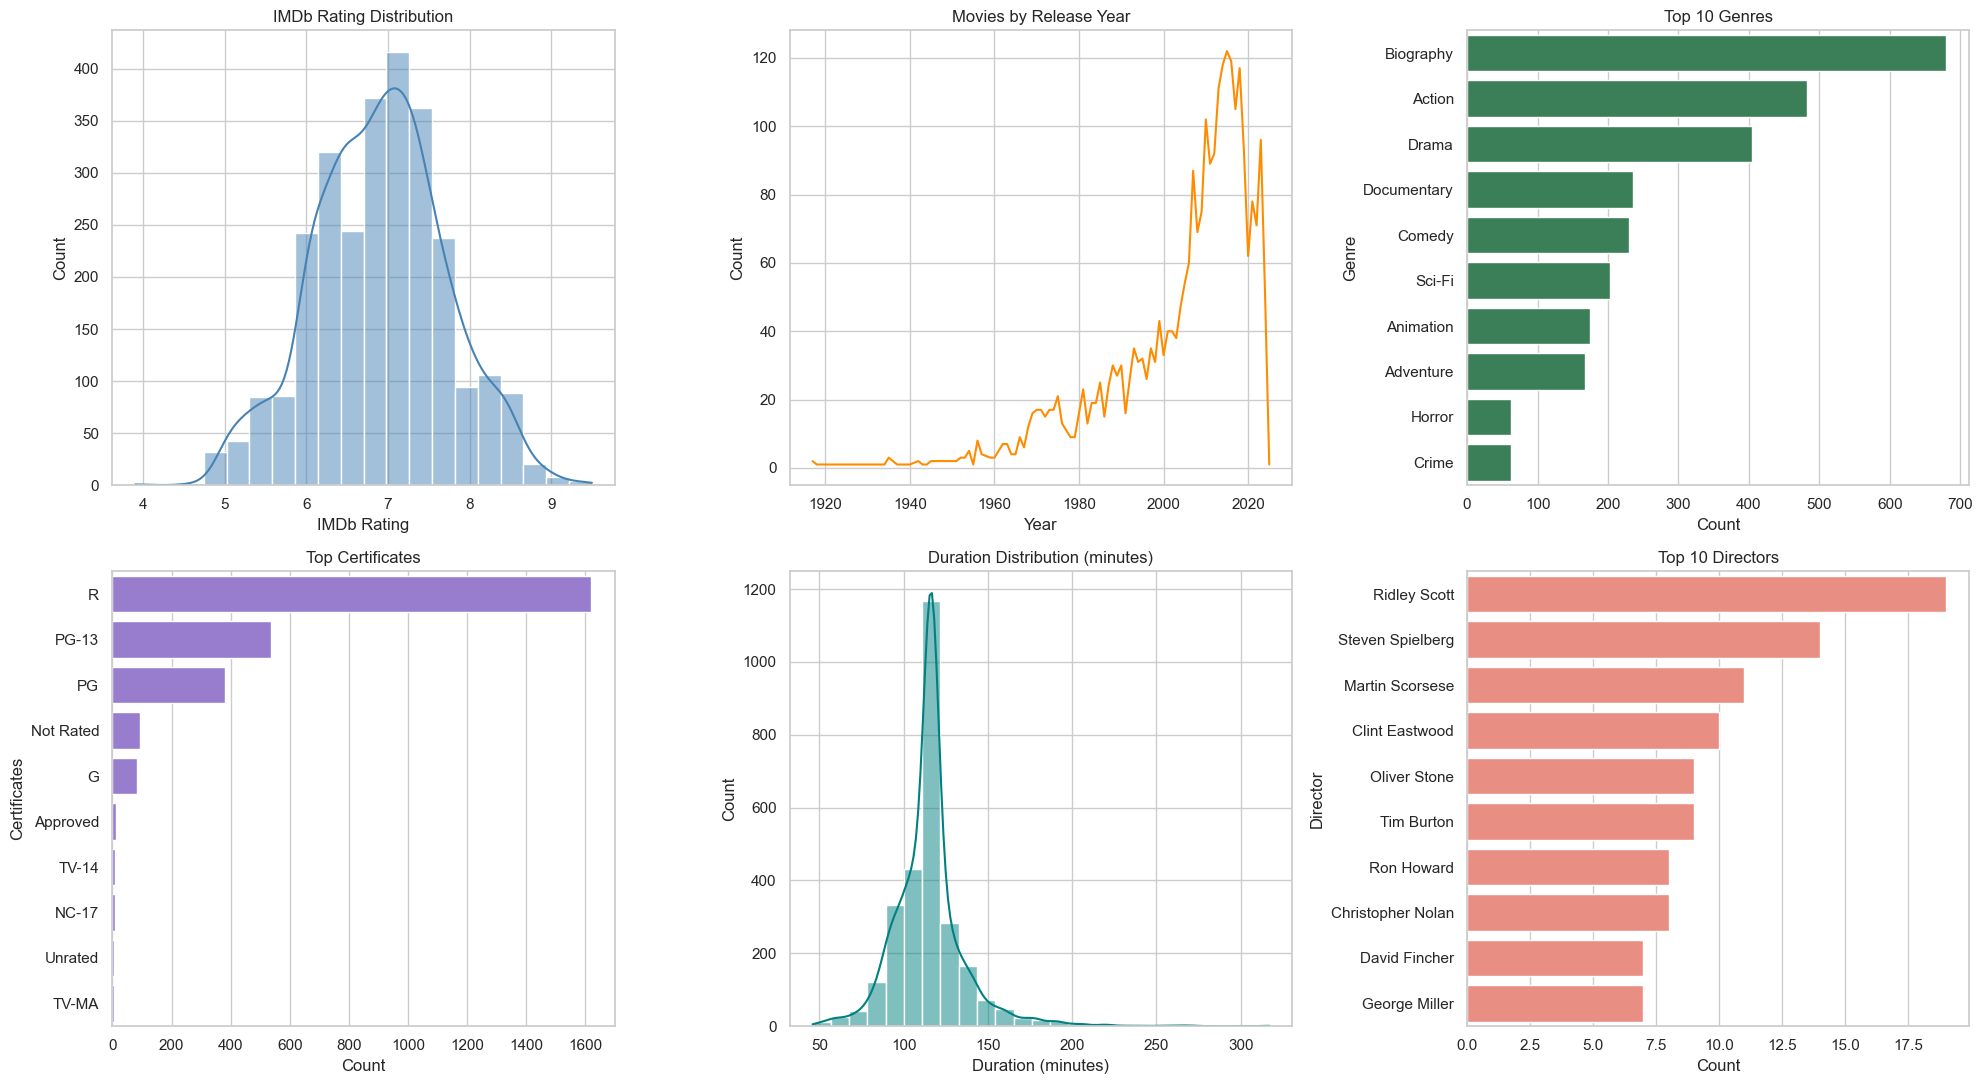

In [64]:
# 6-panel EDA visualization
fig, axes = plt.subplots(2, 3, figsize=(20, 11))

# 1. IMDb Rating distribution
sns.histplot(clean_df["IMDb Rating"], bins=20, kde=True, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("IMDb Rating Distribution")

# 2. Year trend
year_counts = clean_df["Year"].value_counts().sort_index()
axes[0, 1].plot(year_counts.index, year_counts.values, color="darkorange")
axes[0, 1].set_title("Movies by Release Year")
axes[0, 1].set_xlabel("Year")
axes[0, 1].set_ylabel("Count")

# 3. Top 10 genres
top_genres = clean_df["Genre"].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, ax=axes[0, 2], color="seagreen")
axes[0, 2].set_title("Top 10 Genres")
axes[0, 2].set_xlabel("Count")

# 4. Certificate breakdown
top_certs = clean_df["Certificates"].value_counts().head(10)
sns.barplot(x=top_certs.values, y=top_certs.index, ax=axes[1, 0], color="mediumpurple")
axes[1, 0].set_title("Top Certificates")
axes[1, 0].set_xlabel("Count")

# 5. Duration distribution
sns.histplot(clean_df["Duration (minutes)"], bins=25, kde=True, ax=axes[1, 1], color="teal")
axes[1, 1].set_title("Duration Distribution (minutes)")

# 6. Top 10 directors
top_directors = clean_df["Director"].value_counts().head(10)
sns.barplot(x=top_directors.values, y=top_directors.index, ax=axes[1, 2], color="salmon")
axes[1, 2].set_title("Top 10 Directors")
axes[1, 2].set_xlabel("Count")

plt.tight_layout()
plt.show()

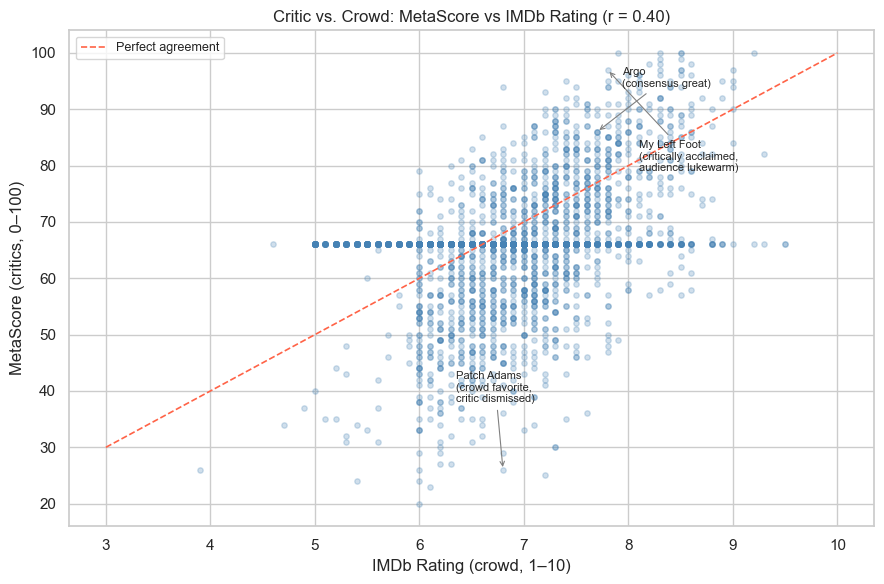

In [65]:
# MetaScore vs IMDb Rating — critic/crowd divergence
fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    clean_df["IMDb Rating"], 
    clean_df["MetaScore"], 
    alpha=0.25, 
    s=15, 
    color="steelblue"
)

# Reference line: perfect agreement (MetaScore = IMDb Rating * 10)
ax.plot([3, 10], [30, 100], color="tomato", linestyle="--", linewidth=1.2, label="Perfect agreement")

# Annotate notable divergent films
highlights = {
    "Patch Adams": ("crowd favorite,\ncritic dismissed", -15, 12),
    "My Left Foot": ("critically acclaimed,\naudience lukewarm", 10, -18),
    "Argo": ("consensus great", 8, 8),
}
for title, (note, dx, dy) in highlights.items():
    row = clean_df[clean_df["Title"] == title].iloc[0]
    ax.annotate(
        f"{title}\n({note})",
        xy=(row["IMDb Rating"], row["MetaScore"]),
        xytext=(row["IMDb Rating"] + dx * 0.03, row["MetaScore"] + dy),
        fontsize=8,
        arrowprops=dict(arrowstyle="->", color="gray", lw=0.8),
    )

ax.set_xlabel("IMDb Rating (crowd, 1–10)")
ax.set_ylabel("MetaScore (critics, 0–100)")
ax.set_title("Critic vs. Crowd: MetaScore vs IMDb Rating (r = {:.2f})".format(
    clean_df["IMDb Rating"].corr(clean_df["MetaScore"])
))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

**EDA Insights:**

- **Ratings** cluster between 6.5–8.0, which means the catalog is already pre-filtered for quality. The chatbot will rarely need to warn users about low-rated films, but it also means there's less spread to differentiate "good" from "great."
- **Year coverage** skews heavily toward 2000–2025, with sparse representation before 1980. Users asking for classic films may get fewer results — something the chatbot should handle gracefully.
- **Genre** is dominated by Biography, Drama, and Documentary combinations. Action and Comedy are present but less common. Genre-based queries will work best for the dominant categories.
- **Certificates** are mostly R and PG-13, which is typical for an IMDb-sourced dataset. Family-friendly filtering (G, PG) will return fewer results.
- **Duration** centers around 90–130 minutes with a long right tail (some 3+ hour epics). Duration-based filtering should work well for typical queries.
- **Directors** — Steven Spielberg, Martin Scorsese, and Ridley Scott lead the count. Director-based queries will return solid results for prolific filmmakers but may be sparse for less represented directors.
- **MetaScore vs IMDb Rating** — these two scores correlate only moderately (r ≈ 0.40). IMDb Rating reflects crowd opinion (1–10 scale); MetaScore reflects professional critics (0–100 scale). About 15% of films show meaningful disagreement — crowd favorites that critics dismissed (e.g., Patch Adams: 6.8 IMDb, 26 MetaScore) and critically acclaimed films that audiences found middling (e.g., My Left Foot: 7.8 IMDb, 97 MetaScore). This divergence creates a natural product feature: the chatbot could let users choose between "crowd favorite" and "critically acclaimed" lenses when asking for recommendations.

### Build `search_text` for Embeddings

The `search_text` column is a single canonical string per movie that combines all relevant fields into one document. In Part 2, this string becomes the input to the embedding model — so its quality directly determines retrieval quality.

**Design choice:** I use a labeled format (`Title: ..., Genre: ..., Director: ...`) rather than just concatenating raw values. This gives the embedding model field-level context, which improves semantic matching. For example, "Director: Christopher Nolan" will embed differently from just "Christopher Nolan" appearing in a cast list.

In [66]:
def build_search_text(row: pd.Series) -> str:
    """Build a single retrieval-ready string from all movie fields."""
    # Use parsed cast names (comma-separated) if available; fall back to raw cast string
    if row["parsed_star_cast"]:
        cast_fragment = "Star Cast: " + ", ".join(row["parsed_star_cast"]) + ". "
    else:
        cast_fragment = "Star Cast: " + str(row["Star Cast"]) + ". "

    return (
        f"Title: {row['Title']}. "
        f"Year: {int(row['Year'])}. "
        f"Genre: {row['Genre']}. "
        f"Director: {row['Director']}. "
        f"{cast_fragment}"
        f"IMDb Rating: {row['IMDb Rating']}. "
        f"MetaScore: {row['MetaScore']}. "
        f"Certificate: {row['Certificates']}. "
        f"Duration (minutes): {row['Duration (minutes)']}."
    )


clean_df["search_text"] = clean_df.apply(build_search_text, axis=1)

# Preview
print(f"search_text column added. Sample length: {clean_df['search_text'].str.len().median():.0f} chars (median)")
print()
print("Example search_text for first movie:")
print(clean_df["search_text"].iloc[0])

search_text column added. Sample length: 212 chars (median)

Example search_text for first movie:
Title: End of the Spear. Year: 2005. Genre: Adventure. Director: Jim Hanon. Star Cast: Louie Leonardo, Chad Allen, Jack Guzman. IMDb Rating: 6.8. MetaScore: 45.0. Certificate: PG-13. Duration (minutes): 108.0.


### Spot-Check: Keyword Filtering on `search_text`

Before moving to embeddings, I validate that `search_text` actually contains the information users would search for. These spot-checks simulate the kinds of queries the chatbot will receive and verify that simple keyword matching finds the expected movies.

In [67]:
# Spot-check: can search_text surface movies for typical user queries?
spot_checks = {
    "Spielberg": "Director query — should find Steven Spielberg films",
    "Nolan": "Director query — should find Christopher Nolan films",
    "Documentary": "Genre query — should find documentaries",
    "DiCaprio": "Actor query — tests that parsed cast is in search_text",
    "2020": "Year query — should find 2020 releases",
}

for keyword, description in spot_checks.items():
    matches = clean_df[clean_df["search_text"].str.contains(keyword, case=False, na=False)]
    sample_titles = matches["Title"].head(3).tolist()
    print(f"'{keyword}' ({description})")
    print(f"  → {len(matches)} matches. Examples: {sample_titles}")
    print()

'Spielberg' (Director query — should find Steven Spielberg films)
  → 14 matches. Examples: ['Amistad', 'The Post', 'Lincoln']

'Nolan' (Director query — should find Christopher Nolan films)
  → 9 matches. Examples: ['Oppenheimer', 'Project Breakwater', 'Inception']

'Documentary' (Genre query — should find documentaries)
  → 235 matches. Examples: ['The Kid Stays in the Picture', "It Ain't Over", 'Stephen Curry: Underrated']

'DiCaprio' (Actor query — tests that parsed cast is in search_text)
  → 11 matches. Examples: ['Total Eclipse', 'J. Edgar', "This Boy's Life"]

'2020' (Year query — should find 2020 releases)
  → 62 matches. Examples: ['Percy Vs Goliath', 'The Glorias', 'Adam']



### Data Integrity Assertions

These assertions serve as a contract: if any of them fail, something broke in the cleaning pipeline. They verify the invariants that Part 2 depends on — unique IDs, no nulls in key fields, and correct row counts.

In [68]:
# Data integrity assertions — these must all pass before moving to Part 2.

# 1. No exact duplicate rows (check on hashable columns only, since parsed_star_cast is a list)
hashable_cols = [c for c in clean_df.columns if c not in ("parsed_star_cast",)]
assert clean_df[hashable_cols].duplicated().sum() == 0, "Found exact duplicate rows in clean_df"

# 2. Every movie_id is unique
assert clean_df["movie_id"].nunique() == len(clean_df), "movie_id is not unique"

# 3. No nulls in key retrieval fields
key_columns = ["Title", "Year", "Genre", "Director", "IMDb Rating", "movie_id", "search_text"]
for col in key_columns:
    assert clean_df[col].isna().sum() == 0, f"Found nulls in {col}"

# 4. search_text is populated for every row
assert (clean_df["search_text"].str.len() > 0).all(), "Found empty search_text values"

# 5. parsed_star_cast exists for every row (even if empty list)
assert clean_df["parsed_star_cast"].apply(lambda x: isinstance(x, list)).all(), "parsed_star_cast should be a list"

# 6. Row count matches expected post-dedup count
assert len(clean_df) == 2762, f"Expected 2762 rows, got {len(clean_df)}"

print("All data integrity assertions passed.")
print(f"clean_df is ready for Part 2: {len(clean_df)} rows, {len(clean_df.columns)} columns")
print(f"Columns: {list(clean_df.columns)}")

All data integrity assertions passed.
clean_df is ready for Part 2: 2762 rows, 15 columns
Columns: ['Title', 'IMDb Rating', 'Year', 'Certificates', 'Genre', 'Director', 'Star Cast', 'MetaScore', 'Poster-src', 'Duration (minutes)', 'base_movie_id', 'movie_id', 'parsed_star_cast', 'star_cast_reliable', 'search_text']


### Data Contract for Part 2

`clean_df` is now ready for embedding and vector store construction. Here's what Part 2 can depend on:

| Property | Value |
|----------|-------|
| Rows | 2,762 unique movies |
| Unique ID | `movie_id` — unique per row, stable slug format |
| Key columns | `Title`, `Year`, `Genre`, `Director`, `Star Cast`, `IMDb Rating`, `MetaScore`, `Certificates`, `Duration (minutes)` |
| Parsed cast | `parsed_star_cast` (list of names), `star_cast_reliable` (boolean quality flag) |
| Retrieval field | `search_text` — labeled, concatenated string of all fields for embedding |
| Nulls | None in any key column |
| Duplicates | Zero exact duplicates; 4 rows with title-year collisions kept intentionally (different films) |

**What Part 2 should use:**
- `search_text` → input to embedding model (`text-embedding-3-small`)
- `movie_id` → document ID in FAISS index
- `parsed_star_cast` → actor-based filtering and constraint extraction
- All other columns → metadata for LLM context and response formatting

### Known Dataset Limitations

This dataset is a **sample of ~2,762 IMDb titles, not a complete catalog**. Several limitations are worth noting because they directly affect what the chatbot can and cannot answer:

1. **Incomplete coverage.** Many well-known films are absent entirely (e.g., *Darkest Hour*, *Tinker Tailor Soldier Spy*). Queries about missing titles will return no results regardless of retrieval quality.

2. **Shallow cast data.** The Star Cast column typically lists only 2–3 top-billed actors per film. Supporting cast members — even prominent ones — are often missing. For example, Gary Oldman appears in the dataset for only 8 films, despite a filmography spanning 40+ titles. Movies like the *Harry Potter* series list only Daniel Radcliffe, Emma Watson, and Rupert Grint.

3. **Occasional data corruption.** A small number of rows have incorrect Star Cast values. For instance, *The Dark Knight* (2008) lists screenwriters (Jonathan Nolan, Christopher Nolan, David S. Goyer) instead of actors (Christian Bale, Heath Ledger, Gary Oldman).

**Impact on the chatbot:** Actor-based queries will under-retrieve — the system correctly returns what the data contains, but the data itself is incomplete. This is a data sourcing limitation, not a retrieval or code bug. In a production system, we would address this by sourcing from a richer API (e.g., TMDb or the full IMDb datasets) with complete cast and crew information.

## Part 2: Embeddings & Vector Store

In Part 1, we built a clean catalog of 2,762 movies with a `search_text` field that captures each movie's identity in a single string. But keyword matching has limits — a user searching for "feel-good comedy about family" won't match a movie whose genre says "Comedy, Drama" and whose description never uses the word "feel-good."

**Semantic search** solves this by converting text into numerical vectors (embeddings) where *meaning* determines proximity, not exact word overlap. Two texts that mean similar things land near each other in vector space, even if they use completely different words.

**Part 2 Objectives:**
1. Convert each movie's `search_text` into a LangChain `Document` with rich metadata
2. Embed all documents using OpenAI's `text-embedding-3-small` model
3. Index the embeddings in a FAISS vector store for fast similarity search
4. Validate retrieval quality with title-based and descriptive test queries

**Rubric target:** *"Retrieval & Search Efficiency"* — efficiently retrieves the most relevant movie data using FAISS/vector search, handling both title-based and descriptive queries accurately.

In [69]:
# Install Part 2 dependencies (skip on re-runs if already installed).
%pip install -q langchain langchain-openai langchain-community faiss-cpu python-dotenv tiktoken

Note: you may need to restart the kernel to use updated packages.


In [70]:
# Part 2 imports and API key loading.
import os
from pathlib import Path

from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

# Load API key: .env file first, then fall back to Colab Secrets.
load_dotenv(dotenv_path=Path.cwd() / ".env", override=False)
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY and IN_COLAB:
    try:
        from google.colab import userdata  # type: ignore
        OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
        os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY
    except Exception:
        pass

if not OPENAI_API_KEY:
    raise EnvironmentError(
        "OPENAI_API_KEY not found. Add it to a .env file or Colab Secrets."
    )

print("OpenAI API key loaded successfully.")

OpenAI API key loaded successfully.


### Document Construction

LangChain's `Document` object has two parts:
- **`page_content`** — the text that gets embedded and searched against. This is our `search_text`.
- **`metadata`** — structured fields (title, year, genre, etc.) carried alongside the vector but *not* embedded. Metadata is used for filtering, reranking, and formatting responses later.

**Why skip chunking?** Many RAG pipelines use a text splitter to break long documents into smaller chunks (e.g., 350 characters each). This makes sense for long-form content like articles or books where a single document might cover multiple topics. But our `search_text` strings are short — median length is ~212 characters, all well under 350. Chunking here would either be a no-op (every string fits in one chunk) or, worse, split a movie's metadata across two chunks and lose the connection between title and cast. We skip chunking intentionally and embed each movie as a single document.

In [71]:
def row_to_document(row: pd.Series) -> Document:
    """Convert a single movie row into a LangChain Document.

    page_content = search_text (what gets embedded)
    metadata     = structured fields (for filtering, reranking, display)
    """
    metadata = {
        "movie_id": row["movie_id"],
        "title": row["Title"],
        "year": int(row["Year"]),
        "genre": row["Genre"],
        "imdb_rating": float(row["IMDb Rating"]),
        "metascore": float(row["MetaScore"]),
        "director": row["Director"],
        "star_cast": row["Star Cast"],
        "parsed_star_cast": row["parsed_star_cast"],
        "star_cast_reliable": bool(row["star_cast_reliable"]),
        "certificate": row["Certificates"],
        "duration_minutes": float(row["Duration (minutes)"]),
        "poster_src": row["Poster-src"],
    }
    return Document(page_content=row["search_text"], metadata=metadata)


# Build one Document per movie
movie_docs = clean_df.apply(row_to_document, axis=1).tolist()

assert len(movie_docs) == 2762, f"Expected 2762 documents, got {len(movie_docs)}"
print(f"Created {len(movie_docs)} LangChain Documents.")
print()
print("Sample document:")
print(f"  page_content: {movie_docs[0].page_content[:120]}...")
print(f"  metadata keys: {list(movie_docs[0].metadata.keys())}")

Created 2762 LangChain Documents.

Sample document:
  page_content: Title: End of the Spear. Year: 2005. Genre: Adventure. Director: Jim Hanon. Star Cast: Louie Leonardo, Chad Allen, Jack ...
  metadata keys: ['movie_id', 'title', 'year', 'genre', 'imdb_rating', 'metascore', 'director', 'star_cast', 'parsed_star_cast', 'star_cast_reliable', 'certificate', 'duration_minutes', 'poster_src']


### Embedding Model & FAISS Index

**What embeddings do:** Each movie's `search_text` gets converted into a 1,536-dimensional vector. Movies with similar content land near each other in this vector space — so a query like "sci-fi thriller" will be close to movies tagged as Science Fiction/Thriller, even without exact keyword overlap.

**Model choice: `text-embedding-3-small`**
- 1,536 dimensions — good balance of quality and efficiency
- Fast and cost-effective (~$0.01 to embed our entire 2,762-movie catalog)
- More than sufficient for a catalog this size; `text-embedding-3-large` (3,072 dims) would be overkill
- `text-embedding-3-small` supports a `dimensions` parameter to reduce dimensionality (e.g., to 512 or 1024), but we use the full 1,536 since our catalog is only 2,762 documents — dimensionality reduction would trade accuracy for negligible performance gains at this scale

**FAISS (Facebook AI Similarity Search):** An in-memory vector index that finds the nearest neighbors to a query vector. For 2,762 movies, brute-force search is instant — no need for approximate nearest neighbor tricks that matter at millions of vectors.

Note: The embedding API call takes ~30-60 seconds for all 2,762 documents. This is a one-time cost; in production, you'd persist the index to disk.

In [ ]:
# Initialize embedding model and build FAISS vector store.
# This sends all 2,762 search_text strings to the OpenAI API (~30-60s).
embedding_model = OpenAIEmbeddings(
    model="text-embedding-3-small",
    api_key=OPENAI_API_KEY,
)

# Create a vector store from the docs and the embedding model. 
vector_store = FAISS.from_documents(movie_docs, embedding_model)

print(f"FAISS index built successfully.")
print(f"  Indexed vectors: {vector_store.index.ntotal}")
print(f"  Vector dimensions: {vector_store.index.d}")

FAISS index built successfully.
  Indexed vectors: 2762
  Vector dimensions: 1536


### Retrieval Validation

Before building the LLM layer, we need to prove the vector store actually retrieves relevant movies. This is the core of the "Retrieval & Search Efficiency" rubric dimension.

**Two query types to test:**
- **Title-based** — searching for a specific movie by name (e.g., "Inception"). The exact match should appear in the top results.
- **Descriptive** — searching by mood, genre, or theme (e.g., "feel-good comedy about family"). Results should be semantically relevant even without exact keyword overlap.

We use `similarity_search_with_score()` which returns both the matched documents and their L2 distance scores. Lower distance = closer match = more relevant.

In [73]:
# Retrieval validation: 5 test queries (2 title-based, 3 descriptive).
test_queries = [
    ("Inception", "title-based"),
    ("The Godfather", "title-based"),
    ("feel-good comedy about family", "descriptive"),
    ("dark psychological thriller from the 2010s", "descriptive"),
    ("documentary about music", "descriptive"),
]

for query, query_type in test_queries:
    results = vector_store.similarity_search_with_score(query, k=5)

    print(f"Query: \"{query}\"  [{query_type}]")
    print("-" * 80)
    for rank, (doc, score) in enumerate(results, 1):
        m = doc.metadata
        print(
            f"  {rank}. {m['title']} ({m['year']}) — "
            f"{m['genre']} | Rating: {m['imdb_rating']} | "
            f"Director: {m['director']} | L2: {score:.4f}"
        )
    print()

Query: "Inception"  [title-based]
--------------------------------------------------------------------------------
  1. Inception (2010) — Action | Rating: 8.8 | Director: Christopher Nolan | L2: 0.7252
  2. Interstellar (2014) — Adventure | Rating: 8.7 | Director: Christopher Nolan | L2: 1.2126
  3. Memento (2000) — Mystery | Rating: 8.4 | Director: Christopher Nolan | L2: 1.2297
  4. The Prestige (2006) — Drama | Rating: 8.5 | Director: Christopher Nolan | L2: 1.2464
  5. Subconscious Reality (2016) — Action | Rating: 6.2 | Director: Mark Byrne | L2: 1.2807

Query: "The Godfather"  [title-based]
--------------------------------------------------------------------------------
  1. The Godfather (1972) — Crime | Rating: 9.2 | Director: Francis Ford Coppola | L2: 0.6477
  2. The Godfather Part II (1974) — Crime | Rating: 9.0 | Director: Francis Ford Coppola | L2: 0.7786
  3. Once Upon a Time in America (1984) — Crime | Rating: 8.3 | Director: Sergio Leone | L2: 1.2146
  4. Goodfellas (1

In [74]:
# Quantitative retrieval baseline — measures accuracy before Part 3 adds filtering/reranking.

# Expected genre for each descriptive query (for genre-hit-rate calculation).
expected_genres = {
    "feel-good comedy about family": "Comedy",
    "dark psychological thriller from the 2010s": "Thriller",
    "documentary about music": "Documentary",
}

col_query = "Query"
col_type = "Type"
col_match = "Rank-1 Match"
col_l2 = "L2 (r1)"
col_gap = "L2 Gap"
print(f"{col_query:<50} {col_type:<12} {col_match:<13} {col_l2:<10} {col_gap:<10} Genre Hits")
print("=" * 110)

for query, query_type in test_queries:
    results = vector_store.similarity_search_with_score(query, k=5)
    r1_doc, r1_l2 = results[0]
    r2_doc, r2_l2 = results[1]
    l2_gap = r2_l2 - r1_l2  # larger gap = more confident retrieval

    if query_type == "title-based":
        # Check if the query appears in the rank-1 title (case-insensitive).
        match = "✓" if query.lower() in r1_doc.metadata["title"].lower() else "✗"
        genre_hits = "—"
    else:
        match = "—"
        # Fraction of top-5 results whose genre contains the expected genre.
        target = expected_genres[query]
        hits = sum(1 for doc, _ in results if target.lower() in doc.metadata["genre"].lower())
        genre_hits = f"{hits}/5 ({hits / 5:.0%})"

    print(f"{query:<50} {query_type:<12} {match:<13} {r1_l2:<10.4f} {l2_gap:<10.4f} {genre_hits}")


Query                                              Type         Rank-1 Match  L2 (r1)    L2 Gap     Genre Hits
Inception                                          title-based  ✓             0.7252     0.4874     —
The Godfather                                      title-based  ✓             0.6477     0.1309     —
feel-good comedy about family                      descriptive  —             1.1752     0.0219     0/5 (0%)
dark psychological thriller from the 2010s         descriptive  —             1.1122     0.0195     0/5 (0%)
documentary about music                            descriptive  —             1.0666     0.0002     4/5 (80%)


### Retrieval Insights

**Title-based queries retrieve confidently.** Both exact titles land at rank 1 with a clear L2 gap to rank 2 (e.g., The Godfather: 0.65 vs 0.78). This gap pattern — a decisive winner well separated from the runner-up — confirms that the embedding model handles precise lookup reliably. When a user searches for a specific movie, we can trust the vector store to find it.

**Descriptive queries expose a quality gap.** "Feel-good comedy about family" returns a Sci-Fi film as the top result. "Dark psychological thriller from the 2010s" returns mostly horror films with mediocre ratings. The L2 scores for descriptive queries are tightly clustered (e.g., 1.07–1.09 for "documentary about music") with no standout match, compared to the clear winner pattern in title queries.

**Why this happens:** Our `search_text` contains only structured metadata — title, genre, director, cast. There are no plot summaries or descriptions for the embedding model to match mood and theme queries against. When a user asks for "dark and mind-bending," the embedding has no narrative content to anchor to, so it returns results that are semantically adjacent but not meaningfully relevant.

**Hard constraints can't be enforced by similarity alone.** The vector store has no way to guarantee that results satisfy constraints like "rating above 8.0" or "released between 2010 and 2019." A query mentioning "the 2010s" gets semantically close to 2010s movies, but can't guarantee all results actually fall in that range.

**This is the measured baseline, not a failure.** Semantic search gets us to the right neighborhood — the retrieval is working as expected given the data it has. Part 3 closes the quality gap with structured filtering (hard constraints on rating, year, genre, actor), preference-aware reranking (soft scoring bonuses for mood and taste signals), and query rewriting to steer retrieval toward user intent rather than literal keywords.

---

### Part 2 Summary — Data Contract for Part 3

| Component | Value |
|-----------|-------|
| `clean_df` | 2,762-row DataFrame with `movie_id`, `search_text`, `parsed_star_cast`, and all original columns — Part 3 needs this for metadata filtering |
| `vector_store` | FAISS index with 2,762 embedded movie vectors (1,536 dimensions) |
| `movie_docs` | List of 2,762 LangChain `Document` objects with full metadata |
| `embedding_model` | `OpenAIEmbeddings` — ready to embed queries |
| Retrieval method | `vector_store.similarity_search_with_score(query, k=5)` |

**What Part 3 will build on top of this:**
- Constraint extraction (parse "rating > 8", "after 2015", "directed by Nolan" from queries)
- Metadata-based reranking and filtering on top of semantic results
- Query rewriting to improve retrieval for complex queries

## Part 3: Retrieval & Reranking

Part 2 proved that semantic search finds the right *neighborhood* — title queries land perfectly, and descriptive queries return thematically adjacent results. But "adjacent" isn't enough when users ask questions with hard constraints: *"action movies rated above 8.0, under 2 hours."* Vector similarity can't guarantee that every result satisfies a rating threshold or runtime limit.

Part 3 adds the structured precision layer. Think of it as the difference between a keyword search ("find movies near this query") and a filtered search ("find movies near this query WHERE rating >= 8.0 AND genre = 'Action'"). Semantic similarity handles the first part; we need constraint extraction and reranking for the second.

### Objectives

1. **Extract hard constraints** from natural language queries (genre, rating range, year range, duration, certificate, actor)
2. **Extract soft preference signals** from query context and chat history (mood cues, referenced titles/directors, preferred era)
3. **Build a hybrid reranker** that combines semantic similarity (72%) with structured scoring bonuses (28%) — filtering out constraint violations, then ranking survivors by relevance + preference fit

### Architecture

```
User Query
    ├── extract_query_constraints()  →  Hard filters (genre, rating, year, duration, cert, actor)
    ├── extract_preference_profile() →  Soft signals (mood, titles, directors, era)
    │
    ▼
FAISS Retrieval (k=30 candidates)
    │
    ▼
Hard Filter — remove movies that violate ANY constraint
    │
    ▼
Soft Rerank — score survivors: 0.72 × semantic + bonuses (up to 28%)
    │
    ▼
Top-k Results (default k=5)
```

### Hybrid Retrieval Architecture\n\nConstrained queries filter the DataFrame first; unconstrained queries go straight to FAISS.

In [ ]:
from IPython.display import HTML

svg = """
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 820 420" style="max-width:820px;font-family:system-ui,sans-serif;">
  <!-- background -->
  <rect width="820" height="420" rx="12" fill="#fafafa" stroke="#ddd"/>

  <!-- title -->
  <text x="410" y="32" text-anchor="middle" font-size="16" font-weight="bold" fill="#222">Hybrid Retrieval Architecture</text>

  <!-- ── User Query ── -->
  <rect x="330" y="52" width="160" height="36" rx="6" fill="#4A90D9" stroke="#3572a5"/>
  <text x="410" y="75" text-anchor="middle" font-size="13" fill="#fff" font-weight="bold">User Query</text>

  <!-- arrow down to understand_query -->
  <line x1="410" y1="88" x2="410" y2="108" stroke="#555" stroke-width="1.5" marker-end="url(#arrow)"/>

  <!-- understand_query -->
  <rect x="305" y="108" width="210" height="36" rx="6" fill="#6C5CE7" stroke="#5a4bd1"/>
  <text x="410" y="131" text-anchor="middle" font-size="12" fill="#fff" font-weight="bold">understand_query() → constraints</text>

  <!-- diamond: has constraints? -->
  <polygon points="410,168 480,200 410,232 340,200" fill="#F5A623" stroke="#d4900e"/>
  <text x="410" y="204" text-anchor="middle" font-size="11" fill="#fff" font-weight="bold">constraints?</text>

  <!-- ── LEFT: Constrained path ── -->
  <line x1="340" y1="200" x2="180" y2="200" stroke="#555" stroke-width="1.5" marker-end="url(#arrow)"/>
  <text x="258" y="193" text-anchor="middle" font-size="10" fill="#888">yes</text>

  <!-- DataFrame filter -->
  <rect x="60" y="182" width="120" height="36" rx="6" fill="#00B894" stroke="#00a381"/>
  <text x="120" y="200" text-anchor="middle" font-size="11" fill="#fff" font-weight="bold">DataFrame</text>
  <text x="120" y="213" text-anchor="middle" font-size="10" fill="#fff">filter (all compliant)</text>

  <!-- arrow down -->
  <line x1="120" y1="218" x2="120" y2="248" stroke="#555" stroke-width="1.5" marker-end="url(#arrow)"/>

  <!-- FAISS full -->
  <rect x="55" y="248" width="130" height="36" rx="6" fill="#0984E3" stroke="#0770c2"/>
  <text x="120" y="266" text-anchor="middle" font-size="11" fill="#fff" font-weight="bold">FAISS (k=all)</text>
  <text x="120" y="279" text-anchor="middle" font-size="10" fill="#fff">semantic scores</text>

  <!-- arrow down -->
  <line x1="120" y1="284" x2="120" y2="314" stroke="#555" stroke-width="1.5" marker-end="url(#arrow)"/>

  <!-- Intersect -->
  <rect x="45" y="314" width="150" height="32" rx="6" fill="#636E72" stroke="#555"/>
  <text x="120" y="335" text-anchor="middle" font-size="11" fill="#fff">Intersect by movie_id</text>

  <!-- arrow down to rerank -->
  <line x1="120" y1="346" x2="120" y2="362" stroke="#555" stroke-width="1.5"/>
  <line x1="120" y1="362" x2="410" y2="362" stroke="#555" stroke-width="1.5" marker-end="url(#arrow)"/>

  <!-- ── RIGHT: Unconstrained path ── -->
  <line x1="480" y1="200" x2="630" y2="200" stroke="#555" stroke-width="1.5" marker-end="url(#arrow)"/>
  <text x="557" y="193" text-anchor="middle" font-size="10" fill="#888">no</text>

  <!-- FAISS k=30 -->
  <rect x="630" y="182" width="130" height="36" rx="6" fill="#0984E3" stroke="#0770c2"/>
  <text x="695" y="200" text-anchor="middle" font-size="11" fill="#fff" font-weight="bold">FAISS (k=30)</text>
  <text x="695" y="213" text-anchor="middle" font-size="10" fill="#fff">semantic search</text>

  <!-- arrow down to rerank -->
  <line x1="695" y1="218" x2="695" y2="362" stroke="#555" stroke-width="1.5"/>
  <line x1="695" y1="362" x2="480" y2="362" stroke="#555" stroke-width="1.5"/>

  <!-- Rerank -->
  <rect x="330" y="370" width="160" height="36" rx="6" fill="#E17055" stroke="#c95d46"/>
  <text x="410" y="393" text-anchor="middle" font-size="12" fill="#fff" font-weight="bold">Rerank → Top 5</text>

  <!-- arrow marker -->
  <defs>
    <marker id="arrow" markerWidth="8" markerHeight="6" refX="8" refY="3" orient="auto">
      <path d="M0,0 L8,3 L0,6 Z" fill="#555"/>
    </marker>
  </defs>
</svg>
"""

HTML(svg)

In [75]:
# Part 3 imports and lookup tables for constraint extraction + preference profiling.

import re
from typing import Dict, List, Optional, Tuple

# --- Static lookup: certificates ---
KNOWN_CERTIFICATES = [
    "G", "PG", "PG-13", "R", "NC-17",
    "Not Rated", "Approved", "TV-14", "TV-PG", "TV-MA",
]

# --- Dynamic lookup: genres from our actual dataset ---
# The dataset stores multi-genre strings like "Action, Drama, Thriller".
# We split these into individual tokens so that a query mentioning "action"
# matches any movie containing Action in its genre list.
_all_genre_strings = clean_df["Genre"].dropna().astype(str).unique().tolist()

# Individual genre tokens sorted longest-first (e.g., "Science Fiction" before "Science")
GENRE_TOKENS = sorted(
    {token.strip() for gs in _all_genre_strings for token in gs.split(",") if token.strip()},
    key=len,
    reverse=True,
)

# Keep the full genre strings for backwards compatibility (preference profiling)
KNOWN_GENRES = sorted(_all_genre_strings, key=len, reverse=True)

# --- Helper functions ---
def _normalize_lookup_text(text: str) -> str:
    """Lowercase, strip punctuation — makes regex matching robust to formatting differences."""
    return re.sub(r"[^a-z0-9 ]+", " ", str(text).lower()).strip()

def _genre_tokens(value: str) -> set:
    """Split a comma-separated genre string into a set of lowercase tokens.
    e.g., 'Action, Drama, Thriller' → {'action', 'drama', 'thriller'}
    """
    return {part.strip().lower() for part in str(value).split(",") if part.strip()}

def _duration_to_minutes(value: float, unit: str) -> float:
    """Convert a duration value to minutes. Handles 'hours'/'hrs' → multiply by 60."""
    if unit.lower().startswith("h"):
        return float(value) * 60.0
    return float(value)

# --- Lookup dictionaries built from clean_df ---
# Title lookup: normalized title → row dict (for preference profiling)
MOVIE_RECORDS = clean_df[
    ["Title", "Year", "Genre", "Director", "IMDb Rating", "Certificates", "parsed_star_cast"]
].to_dict("records")
TITLE_LOOKUP = {_normalize_lookup_text(row["Title"]): row for row in MOVIE_RECORDS}
DIRECTOR_LOOKUP = {_normalize_lookup_text(row["Director"]): row for row in MOVIE_RECORDS}

# Actor lookup: explode parsed_star_cast to get all unique actor names.
# The reference notebook uses a separate cast_member_df — we get the same result
# by exploding the parsed_star_cast column directly.
ALL_ACTORS = sorted(
    clean_df["parsed_star_cast"].explode().dropna().astype(str).unique().tolist(),
    key=len,
    reverse=True,  # longest-first for regex matching (e.g., "Robert De Niro" before "Robert")
)
ACTOR_LOOKUP = {_normalize_lookup_text(name): name for name in ALL_ACTORS}

print(f"Lookup tables built:")
print(f"  {len(GENRE_TOKENS):,} unique genre tokens (from {len(KNOWN_GENRES):,} genre strings)")
print(f"  {len(TITLE_LOOKUP):,} unique titles")
print(f"  {len(DIRECTOR_LOOKUP):,} unique directors")
print(f"  {len(ACTOR_LOOKUP):,} unique actors")

Lookup tables built:
  17 unique genre tokens (from 17 genre strings)
  2,739 unique titles
  2,089 unique directors
  6,053 unique actors


### Hard Constraints vs Soft Preferences

The reranking pipeline has two layers, each serving a different purpose:

| | Hard Constraints | Soft Preferences |
|---|---|---|
| **Logic** | Binary pass/fail — movie must satisfy ALL | Scoring bonuses — movie ranked higher, never excluded |
| **Analogy** | SQL `WHERE` clause | SQL `ORDER BY` weights |
| **Examples** | genre=Action, imdb_rating >= 8.0, year >= 2010, duration <= 120min | mood=dark → bonus for thriller/crime/mystery; referenced director → bonus |
| **If missing** | Movie is **excluded** from results | Movie is **ranked lower** but still eligible |

**Example:** *"dark thriller rated above 7.5"*
- **Hard constraint:** `imdb_min=7.5` — any movie below 7.5 is filtered out entirely
- **Soft preference:** mood="dark" → scoring bonus for thriller, crime, mystery genres — movies in those genres rank higher, but a drama rated 8.5 could still appear if semantically relevant

**Why two layers?** A single scoring formula can't express "must have" vs "nice to have." If we only used scoring, a 9.0-rated comedy could outrank a 7.6-rated thriller for a query explicitly asking for thrillers above 7.5. Hard constraints enforce the user's explicit requirements; soft preferences personalize within those bounds.

In [76]:
def extract_query_constraints(query: str) -> Dict:
    """Parse hard constraints from a natural language query.

    Extracts 10 constraint types using regex patterns:
    - genre, certificate, actor_name, director_name (matched against our lookup tables)
    - imdb_min/max, year_min/max, duration_min/max (numeric ranges)
    - prefer_high_rating (boolean flag for queries like "best" or "top rated")

    Returns a dict where None = no constraint detected for that dimension.
    """
    q = str(query).lower()
    q_norm = _normalize_lookup_text(query)

    constraints = {
        "genre": None,
        "certificate": None,
        "actor_name": None,
        "director_name": None,
        "imdb_min": None,
        "imdb_max": None,
        "year_min": None,
        "year_max": None,
        "duration_min": None,
        "duration_max": None,
        "prefer_high_rating": False,
    }

    # --- High-rating intent ---
    if any(phrase in q for phrase in ["highly rated", "top rated", "best rated", "highest rated", "best "]):
        constraints["prefer_high_rating"] = True

    # --- Genre (match individual tokens, not full comma-separated strings) ---
    # GENRE_TOKENS is sorted longest-first so "Science Fiction" matches before "Science".
    # We store the token with original casing so _doc_satisfies_hard_constraints can
    # do a case-insensitive substring check against the movie's full genre string.
    #
    # Normalize common English plurals so "documentaries" matches "Documentary",
    # "comedies" matches "Comedy", "thrillers" matches "Thriller", etc.
    q_genre = re.sub(r"ies\b", "y", q)       # documentaries → documentary
    q_genre = re.sub(r"([^s])s\b", r"\1", q_genre)  # thrillers → thriller (but not "s" after "s")
    for token in GENRE_TOKENS:
        if re.search(rf"\b{re.escape(token.lower())}\b", q_genre):
            constraints["genre"] = token
            break

    # --- Certificate (longest-first: "PG-13" before "PG") ---
    for cert in sorted(KNOWN_CERTIFICATES, key=len, reverse=True):
        if re.search(rf"\b{re.escape(cert.lower())}\b", q):
            constraints["certificate"] = cert
            break

    # --- Director (check before actor — "Christopher Nolan" is a director, not an actor) ---
    # DIRECTOR_LOOKUP maps normalized_name → row dict, so we extract the
    # "Director" field from the row to get the original-cased name string.
    for dir_norm, dir_row in DIRECTOR_LOOKUP.items():
        if dir_norm and re.search(rf"\b{re.escape(dir_norm)}\b", q_norm):
            constraints["director_name"] = dir_row["Director"]
            break

    # --- Actor (longest-first: "Robert De Niro" before "Robert") ---
    # ACTOR_LOOKUP maps normalized_name → name string (unlike DIRECTOR_LOOKUP).
    # Skip if already matched as director (avoids double-matching names that appear in both)
    if constraints["director_name"] is None:
        for actor_norm, actor_name in ACTOR_LOOKUP.items():
            if actor_norm and re.search(rf"\b{re.escape(actor_norm)}\b", q_norm):
                constraints["actor_name"] = actor_name
                break
    else:
        # Still check for actors, but skip the name already matched as director
        dir_norm_matched = _normalize_lookup_text(constraints["director_name"])
        for actor_norm, actor_name in ACTOR_LOOKUP.items():
            if actor_norm and actor_norm != dir_norm_matched and re.search(rf"\b{re.escape(actor_norm)}\b", q_norm):
                constraints["actor_name"] = actor_name
                break

    # --- IMDb rating range ---
    rating_min_patterns = [
        r"(?:imdb\s*rating|rating|rated)\s*(?:above|over|greater than|at least|>=)\s*(\d+(?:\.\d+)?)",
        r"(?:above|over|greater than|at least|>=)\s*(\d+(?:\.\d+)?)\s*(?:imdb\s*rating|rating)",
        r"(?:minimum|min)\s*(?:imdb\s*rating|rating)\s*(\d+(?:\.\d+)?)",
        r"(?:rated)\s*(\d+(?:\.\d+)?)\s*(?:and above|or above|plus)",
        r"(\d+(?:\.\d+)?)\s*(?:and above|or above)\s*(?:on imdb|imdb|rating)?",
    ]
    rating_max_patterns = [
        r"(?:imdb\s*rating|rating|rated)\s*(?:below|under|less than|at most|<=)\s*(\d+(?:\.\d+)?)",
        r"(?:below|under|less than|at most|<=)\s*(\d+(?:\.\d+)?)\s*(?:imdb\s*rating|rating)",
        r"(?:maximum|max)\s*(?:imdb\s*rating|rating)\s*(\d+(?:\.\d+)?)",
    ]

    for pattern in rating_min_patterns:
        m = re.search(pattern, q)
        if m:
            constraints["imdb_min"] = float(m.group(1))
            constraints["prefer_high_rating"] = True
            break

    for pattern in rating_max_patterns:
        m = re.search(pattern, q)
        if m:
            constraints["imdb_max"] = float(m.group(1))
            break

    # --- Year range ---
    # Decade references: "90s movies", "from the 2010s", "1980s classics"
    decade_match = re.search(r"\b((?:19|20)?\d{2})s\b", q)
    if decade_match:
        raw = decade_match.group(1)
        if len(raw) == 2:
            # "90s" → 1990s, "00s" → 2000s
            decade_start = int(raw) + (1900 if int(raw) >= 20 else 2000)
        else:
            decade_start = int(raw)
        constraints["year_min"] = decade_start
        constraints["year_max"] = decade_start + 9

    m = re.search(r"(?:after|newer than)\s*(19\d{2}|20\d{2})", q)
    if m:
        constraints["year_min"] = int(m.group(1)) + 1  # "after 2010" → year >= 2011

    m = re.search(r"(?:since|from|after or in)\s*(19\d{2}|20\d{2})", q)
    if m and constraints["year_min"] is None:
        constraints["year_min"] = int(m.group(1))  # "since 2010" → year >= 2010

    m = re.search(r"(?:before|older than)\s*(19\d{2}|20\d{2})", q)
    if m:
        constraints["year_max"] = int(m.group(1)) - 1  # "before 2020" → year <= 2019

    # Exact year: "in 2015" or "from 2015" (only if no range already set)
    m = re.search(r"(?:in|from)\s*(19\d{2}|20\d{2})", q)
    if m and constraints["year_min"] is None and constraints["year_max"] is None:
        year_exact = int(m.group(1))
        constraints["year_min"] = year_exact
        constraints["year_max"] = year_exact

    # --- Duration range ---
    duration_min_match = re.search(
        r"(?:over|above|more than|at least|>=)\s*(\d+(?:\.\d+)?)\s*(hours?|hrs?|hr|minutes?|mins?|min)", q
    )
    if duration_min_match:
        value = float(duration_min_match.group(1))
        unit = duration_min_match.group(2)
        constraints["duration_min"] = _duration_to_minutes(value, unit)

    duration_max_match = re.search(
        r"(?:under|below|less than|at most|<=)\s*(\d+(?:\.\d+)?)\s*(hours?|hrs?|hr|minutes?|mins?|min)", q
    )
    if duration_max_match:
        value = float(duration_max_match.group(1))
        unit = duration_max_match.group(2)
        constraints["duration_max"] = _duration_to_minutes(value, unit)

    return constraints


# --- Demo: test constraint extraction on 9 representative queries ---
# Includes plural genre forms and director queries.
test_constraint_queries = [
    "action movies rated above 8.0",
    "Leonardo DiCaprio films under 2 hours",
    "PG-13 comedies from 2020",
    "best documentaries",
    "sci-fi movies from the 2010s",
    "90s thrillers rated above 7.5",
    "give me all documentaries rated 8.0 and above",
    "show me all R-rated mysteries",
    "Find Christopher Nolan movies with strong IMDb ratings",
]

for query in test_constraint_queries:
    constraints = extract_query_constraints(query)
    # Only show non-None constraints for readability
    active = {k: v for k, v in constraints.items() if v is not None and v is not False}
    print(f"Query: \"{query}\"")
    print(f"  → {active}")
    print()

Query: "action movies rated above 8.0"
  → {'genre': 'Action', 'imdb_min': 8.0, 'prefer_high_rating': True}

Query: "Leonardo DiCaprio films under 2 hours"
  → {'actor_name': 'Leonardo DiCaprio', 'duration_max': 120.0}

Query: "PG-13 comedies from 2020"
  → {'genre': 'Comedy', 'certificate': 'PG-13', 'year_min': 2020}

Query: "best documentaries"
  → {'genre': 'Documentary', 'prefer_high_rating': True}

Query: "sci-fi movies from the 2010s"
  → {'genre': 'Sci-Fi', 'year_min': 2010, 'year_max': 2019}

Query: "90s thrillers rated above 7.5"
  → {'imdb_min': 7.5, 'year_min': 1990, 'year_max': 1999, 'prefer_high_rating': True}

Query: "give me all documentaries rated 8.0 and above"
  → {'genre': 'Documentary', 'imdb_min': 8.0, 'prefer_high_rating': True}

Query: "show me all R-rated mysteries"
  → {'genre': 'Mystery', 'certificate': 'R', 'actor_name': 'R.'}

Query: "Find Christopher Nolan movies with strong IMDb ratings"
  → {'director_name': 'Christopher Nolan'}



In [77]:
def extract_preference_profile(
    query: str,
    chat_history: Optional[List[Tuple[str, str]]] = None,
) -> Dict:
    """Infer soft preference signals from the current query and recent chat history.

    Looks at the current query + last 4 user turns to detect:
    - mentioned_titles: movies the user referenced (looked up in our catalog)
    - mentioned_directors: directors mentioned by name
    - mentioned_actors: actors mentioned by name
    - preferred_genres: genres inferred from mentions + mood keywords
    - preferred_era: average release year of mentioned titles (if any)
    - matched_moods: mood keywords that map to genre bonuses

    These signals become scoring bonuses in the reranker — they personalize results
    without excluding anything.
    """
    if chat_history is None:
        chat_history = []

    # Combine current query with recent user messages for richer signal
    # Guard against None values that can slip through from Gradio history conversion
    history_text = " ".join(str(user_msg or "") for user_msg, _ in chat_history[-4:])
    combined_text = f"{query} {history_text}"
    combined_norm = _normalize_lookup_text(combined_text)

    # --- Detect mentioned titles ---
    mentioned_titles = []
    for title_norm, row in TITLE_LOOKUP.items():
        if title_norm and re.search(rf"\b{re.escape(title_norm)}\b", combined_norm):
            mentioned_titles.append(row["Title"])

    # --- Detect mentioned directors ---
    mentioned_directors = []
    for director_norm, row in DIRECTOR_LOOKUP.items():
        if director_norm and re.search(rf"\b{re.escape(director_norm)}\b", combined_norm):
            mentioned_directors.append(row["Director"])

    # --- Detect mentioned actors ---
    mentioned_actors = []
    for actor_norm, actor_name in ACTOR_LOOKUP.items():
        if actor_norm and re.search(rf"\b{re.escape(actor_norm)}\b", combined_norm):
            mentioned_actors.append(actor_name)

    # --- Infer preferred genres from direct mentions + referenced movies ---
    # Match individual genre tokens (e.g., "action") not full strings ("Action, Drama")
    preferred_genres = set()
    for token in GENRE_TOKENS:
        if re.search(rf"\b{re.escape(token.lower())}\b", combined_text.lower()):
            preferred_genres.add(token.lower())

    # Add genres from referenced titles and directors
    era_preferences = []
    for title in mentioned_titles:
        row = TITLE_LOOKUP.get(_normalize_lookup_text(title))
        if row:
            preferred_genres.update(_genre_tokens(row["Genre"]))
            era_preferences.append(int(row["Year"]))

    for director in mentioned_directors:
        row = DIRECTOR_LOOKUP.get(_normalize_lookup_text(director))
        if row:
            preferred_genres.update(_genre_tokens(row["Genre"]))

    # --- Mood keywords → genre bonuses ---
    # Maps subjective mood words to genre families that typically match that mood.
    mood_map = {
        "dark": {"thriller", "crime", "mystery"},
        "light": {"comedy", "animation", "family"},
        "emotional": {"drama", "romance"},
        "mind bending": {"sci-fi", "mystery", "thriller"},
        "feel good": {"comedy", "family", "musical"},
        "intense": {"action", "thriller", "war"},
    }

    matched_moods = []
    lowered = combined_text.lower()
    for phrase, genres in mood_map.items():
        if phrase in lowered:
            matched_moods.append(phrase)
            preferred_genres.update(genres)

    return {
        "mentioned_titles": sorted(set(mentioned_titles)),
        "mentioned_directors": sorted(set(mentioned_directors)),
        "mentioned_actors": sorted(set(mentioned_actors)),
        "preferred_genres": sorted(preferred_genres),
        "preferred_era": round(sum(era_preferences) / len(era_preferences)) if era_preferences else None,
        "matched_moods": matched_moods,
    }


# --- Demo: test preference profiling ---
test_pref_queries = [
    ("I loved Inception and The Dark Knight. Something dark and mind bending.", []),
    ("Something light and fun like Toy Story", []),
]

for query, history in test_pref_queries:
    profile = extract_preference_profile(query, chat_history=history)
    print(f"Query: \"{query}\"")
    for key, value in profile.items():
        if value:  # skip empty lists and None
            print(f"  {key}: {value}")
    print()

Query: "I loved Inception and The Dark Knight. Something dark and mind bending."
  mentioned_titles: ['Inception', 'The Dark Knight']
  preferred_genres: ['action', 'crime', 'mystery', 'sci-fi', 'thriller']
  preferred_era: 2009
  matched_moods: ['dark', 'mind bending']

Query: "Something light and fun like Toy Story"
  mentioned_titles: ['Toy Story']
  preferred_genres: ['animation', 'comedy', 'family']
  preferred_era: 1995
  matched_moods: ['light']



## Architectural Decision: LLM-Powered Query Understanding

### Why Replace Regex Intent Detection?

The regex approach in `detect_intent()` and `extract_query_constraints()` works fine for clean, predictable inputs — but real users don't write clean queries.

**The problem with regex:**
- `"funny"` ≠ `"comedy"` to a regex, even though they mean the same thing to a user
- Follow-up references like *"which of these is shorter?"* or *"show me more like that one"* — regex has no idea what "these" or "that one" refers to
- Every new edge case requires a new hand-crafted pattern. The system becomes a growing collection of special cases, not a general solution

**Why one LLM call solves all of this:**
- A single structured JSON call (~300ms) replaces three separate regex functions: `detect_intent()`, `extract_query_constraints()`, and `is_probably_movie_related()`
- It handles **semantic genre mapping** ("something uplifting" → Drama/Animation), **pronoun resolution** (chat history context), and **topic classification** — things regex simply can't do
- The output is a typed `QueryUnderstanding` dataclass: intent, constraints, preferences, topic flag, and a rewritten query for retrieval — everything the downstream pipeline needs in one pass

**What stays exactly the same:**
- FAISS vector retrieval, hybrid reranking, LLM generation, and Gradio formatting are untouched
- `understand_query()` is a preprocessing step — it feeds *better inputs* into the existing pipeline rather than replacing it

**The tradeoff:**
- ~$0.001/query additional cost (GPT-4o-mini is cheap)
- ~300ms added latency — acceptable for a conversational interface
- Worth it: dramatically better query understanding with less brittle code

In [ ]:
import json

# ── LLM-Powered Query Understanding ──────────────────────────────
# Replaces the regex-based detect_intent(), extract_query_constraints(),
# and is_probably_movie_related() with a single LLM call that:
#   1. Resolves follow-up references ("these", "that one", "more like it")
#   2. Extracts structured constraints (genre, actor, year, rating, etc.)
#   3. Classifies intent (search / recommendation / catalog / clarification / fallback)
#   4. Determines if the query is movie-related (with chat history context)

QUERY_UNDERSTANDING_PROMPT = """You are a query analyzer for an IMDb movie chatbot. Given the user's message and recent conversation history, return a JSON object with these fields:

1. "resolved_query": The user's intent as a clear, self-contained movie search query. Resolve pronouns and references using chat history (e.g., "Which of these are funny?" + history about Brad Pitt movies → "Brad Pitt comedy movies"). If the query is already self-contained, clean it up but keep the meaning. If the query is not movie-related, set this to the original query.

2. "intent": One of:
   - "catalog" — user wants a comprehensive/exhaustive list OR specifies 2+ hard filter criteria (genre, certificate, rating threshold, actor, director, year range). Examples: "show me all R-rated comedies", "best action movies rated above 8.0", "PG-13 sci-fi from the 2010s", "Brad Pitt thrillers". These need full database filtering, not semantic search.
   - "recommendation" — user wants personalized suggestions based on taste or mood ("recommend", "suggest", "what should I watch", "something like", "in the mood for", "something suspenseful for tonight")
   - "search" — general movie lookup or question with at most 1 filter criterion (default for movie-related queries)
   - "clarification" — query is too vague or ambiguous to act on (single word, no clear ask)
   - "fallback" — greetings ("hi", "hello"), meta-questions ("what can you do"), or completely off-topic (weather, recipes, math, sports)

3. "is_movie_related": true if the query is about movies, actors, directors, genres, ratings, or is a follow-up to a movie conversation. false if it's completely off-topic. When there is active movie conversation in the history, lean toward true for ambiguous queries.

4. "constraints": An object with these keys (use null for undetected):
   - "genre": Single genre string. Map natural language to standard genres: "funny/hilarious" → "Comedy", "scary/creepy" → "Horror", "romantic/love" → "Romance", "exciting/action-packed" → "Action", "sad/emotional/tearjerker" → "Drama", "suspenseful/tense" → "Thriller", "animated/cartoon" → "Animation", "true story/real events" → "Biography", "space/aliens" → "Sci-Fi", "singing/songs" → "Musical", "mysterious/whodunit" → "Mystery", "war/battle" → "War", "criminal/heist" → "Crime", "old west/cowboys" → "Western", "magical/fantasy world" → "Fantasy", "family-friendly/kids" → "Family", "educational/informational" → "Documentary", "historical/period" → "History", "sporty/athletic" → "Sport", "musical/songs" → "Music". If user names a genre directly, use it.
   - "actor_name": Actor's full name (proper capitalization), or null
   - "director_name": Director's full name (proper capitalization), or null
   - "certificate": One of G, PG, PG-13, R, NC-17, or null
   - "imdb_min": Minimum IMDb rating as float, or null
   - "imdb_max": Maximum IMDb rating as float, or null
   - "year_min": Earliest year as int, or null
   - "year_max": Latest year as int, or null
   - "duration_min": Minimum runtime in minutes as int, or null
   - "duration_max": Maximum runtime in minutes as int, or null
   - "prefer_high_rating": true if user wants "best", "top", "highest rated", "great", else false

Return ONLY valid JSON. No markdown, no explanation."""


def understand_query(
    query: str,
    chat_history: Optional[List[Tuple[str, str]]] = None,
) -> Dict:
    """Call gpt-4o-mini to analyze the user's query with conversation context.

    Returns a dict with: resolved_query, intent, is_movie_related, constraints.
    Falls back to safe defaults if the LLM call fails.
    """
    # Build history context (last 3 turns)
    history_text = ""
    if chat_history:
        recent = chat_history[-3:]
        lines = []
        for user_msg, bot_msg in recent:
            if user_msg:
                lines.append(f"User: {user_msg}")
            if bot_msg:
                # Truncate long bot responses to save tokens (800 chars preserves movie titles)
                short = bot_msg[:800] + "..." if len(bot_msg) > 200 else bot_msg
                lines.append(f"Assistant: {short}")
        history_text = "\n".join(lines)

    user_message = f"Conversation history:\n{history_text}\n\nCurrent user message:\n{query}" if history_text else f"Current user message:\n{query}"

    # Safe defaults if LLM call fails
    fallback_result = {
        "resolved_query": query,
        "intent": "search",
        "is_movie_related": True,
        "constraints": {
            "genre": None, "actor_name": None, "director_name": None,
            "certificate": None, "imdb_min": None, "imdb_max": None,
            "year_min": None, "year_max": None,
            "duration_min": None, "duration_max": None,
            "prefer_high_rating": False,
        },
    }

    try:
        response = llm.invoke([
            {"role": "system", "content": QUERY_UNDERSTANDING_PROMPT},
            {"role": "user", "content": user_message},
        ])
        parsed = json.loads(response.content)

        # Validate required fields exist
        result = {
            "resolved_query": parsed.get("resolved_query", query),
            "intent": parsed.get("intent", "search"),
            "is_movie_related": parsed.get("is_movie_related", True),
            "constraints": parsed.get("constraints", fallback_result["constraints"]),
        }

        # Validate intent is a known value
        valid_intents = {"search", "recommendation", "catalog", "clarification", "fallback"}
        if result["intent"] not in valid_intents:
            result["intent"] = "search"

        # Coerce numeric constraint types (LLM may return strings)
        c = result["constraints"]
        for float_key in ("imdb_min", "imdb_max"):
            if c.get(float_key) is not None:
                c[float_key] = float(c[float_key])
        for int_key in ("year_min", "year_max", "duration_min", "duration_max"):
            if c.get(int_key) is not None:
                c[int_key] = int(c[int_key])

        # Ensure all expected keys are present (fill missing with None)
        expected_keys = {
            "genre", "actor_name", "director_name", "certificate",
            "imdb_min", "imdb_max", "year_min", "year_max",
            "duration_min", "duration_max", "prefer_high_rating",
        }
        for key in expected_keys:
            c.setdefault(key, None)

        return result

    except Exception as e:
        print(f"⚠ understand_query() failed: {e} — using safe defaults")
        return fallback_result

### The Reranking Formula

After hard-constraint filtering removes movies that violate explicit requirements, the surviving candidates are scored using a hybrid formula:

```
final_score = 0.72 × semantic_similarity + bonuses
```

**Why 0.72 for semantic similarity?** Semantic similarity is the dominant signal — it captures the overall meaning match between the query and the movie. The bonuses (up to 28% combined) are tie-breakers that promote movies matching the user's soft preferences. Without this weighting, a movie with perfect preference overlap but poor semantic fit could outrank a genuinely relevant result.

**Bonus weights:**

| Bonus | Weight | Trigger |
|-------|--------|---------|
| Rating | up to 10% | `prefer_high_rating` flag set (e.g., "best", "top rated") |
| Genre overlap | 8% | Movie genres overlap with preferred genres |
| Director match | 10% | Movie director matches a referenced director |
| Actor (hard constraint) | 12% | Movie cast includes the explicitly requested actor |
| Actor (soft preference) | 6% | Movie cast includes a mentioned (not required) actor |
| Era proximity | up to 6% | Movie release year is close to the preferred era |

**Semantic similarity from FAISS L2 distance:** FAISS returns L2 (Euclidean) distances — lower = more similar. We convert to a 0-1 similarity score: `similarity = 1 / (1 + distance)`. This gives us a bounded, interpretable signal that plays nicely with the bonus weights.

**Fallback behavior:** If hard filtering eliminates ALL candidates (e.g., the user asks for a very specific combination that doesn't exist), we fall back to the full candidate set and flag `used_constraint_fallback=True`. This prevents empty results — the user still gets semantically relevant movies, with a note that no exact matches were found.

In [ ]:
# --- Reranking helper functions ---

def _normalize_certificate(cert: str) -> str:
    """Normalize certificate string: strip 'Rated ' prefix and '-rated' suffix."""
    cert = re.sub(r"(?i)^rated\s+", "", cert)
    cert = re.sub(r"(?i)-rated$", "", cert)
    return cert.strip().upper()


def _has_hard_constraints(constraints: Dict) -> bool:
    """Check if the constraints dict contains any non-None hard constraint."""
    hard_keys = [
        "genre", "certificate", "actor_name", "director_name",
        "imdb_min", "imdb_max", "year_min", "year_max",
        "duration_min", "duration_max",
    ]
    return any(constraints.get(k) is not None for k in hard_keys)


def _doc_satisfies_hard_constraints(doc: Document, constraints: Dict) -> bool:
    """Return True if the document passes ALL hard constraints (AND logic)."""
    m = doc.metadata

    if constraints.get("genre") and constraints["genre"].lower() not in str(m.get("genre", "")).lower():
        return False
    if constraints.get("certificate") and str(m.get("certificate", "")).upper() != _normalize_certificate(constraints["certificate"]):
        return False
    if constraints.get("actor_name"):
        actor_lower = constraints["actor_name"].lower()
        cast_lower = [name.lower() for name in m.get("parsed_star_cast", [])]
        if actor_lower not in cast_lower:
            return False
    if constraints.get("director_name") and str(m.get("director", "")).lower() != constraints["director_name"].lower():
        return False

    imdb = float(m.get("imdb_rating", 0.0))
    year = int(m.get("year", 0))
    duration = float(m.get("duration_minutes", 0.0))

    if constraints.get("imdb_min") is not None and imdb < constraints["imdb_min"]:
        return False
    if constraints.get("imdb_max") is not None and imdb > constraints["imdb_max"]:
        return False
    if constraints.get("year_min") is not None and year < constraints["year_min"]:
        return False
    if constraints.get("year_max") is not None and year > constraints["year_max"]:
        return False
    if constraints.get("duration_min") is not None and duration < constraints["duration_min"]:
        return False
    if constraints.get("duration_max") is not None and duration > constraints["duration_max"]:
        return False

    return True


def _filter_compliant_movie_ids(constraints: Dict) -> set:
    """Filter clean_df by hard constraints, return set of compliant movie_ids.

    Used by both run_retrieval_pipeline() (hybrid path) and catalog_agent()
    to ensure consistent filtering logic across all retrieval modes.
    """
    mask = pd.Series(True, index=clean_df.index)

    if constraints.get("genre"):
        genre = constraints["genre"].lower()
        mask &= clean_df["Genre"].str.lower().str.contains(genre, na=False)

    if constraints.get("certificate"):
        cert = _normalize_certificate(constraints["certificate"])
        mask &= clean_df["Certificates"].str.upper() == cert

    if constraints.get("actor_name"):
        actor = constraints["actor_name"].lower()
        mask &= clean_df["parsed_star_cast"].apply(
            lambda names: any(actor == name.lower() for name in names)
        )

    if constraints.get("director_name"):
        director = constraints["director_name"].lower()
        mask &= clean_df["Director"].str.lower() == director

    if constraints.get("imdb_min") is not None:
        mask &= clean_df["IMDb Rating"] >= constraints["imdb_min"]
    if constraints.get("imdb_max") is not None:
        mask &= clean_df["IMDb Rating"] <= constraints["imdb_max"]
    if constraints.get("year_min") is not None:
        mask &= clean_df["Year"] >= constraints["year_min"]
    if constraints.get("year_max") is not None:
        mask &= clean_df["Year"] <= constraints["year_max"]
    if constraints.get("duration_min") is not None:
        mask &= clean_df["Duration (minutes)"] >= constraints["duration_min"]
    if constraints.get("duration_max") is not None:
        mask &= clean_df["Duration (minutes)"] <= constraints["duration_max"]

    # prefer_high_rating applies IMDb >= 7.0 floor only when other
    # hard constraints are present (checked by caller via _has_hard_constraints)
    if constraints.get("prefer_high_rating"):
        mask &= clean_df["IMDb Rating"] >= 7.0

    return set(clean_df.loc[mask, "movie_id"])


def _semantic_similarity(distance: float) -> float:
    """Convert FAISS L2 distance to a 0-1 similarity score."""
    return 1.0 / (1.0 + max(float(distance), 0.0))


def summarize_constraints(constraints: Dict) -> str:
    """Human-readable summary of active hard constraints."""
    parts = []
    if constraints.get("genre"):
        parts.append(f"genre={constraints['genre']}")
    if constraints.get("certificate"):
        parts.append(f"certificate={constraints['certificate']}")
    if constraints.get("actor_name"):
        parts.append(f"actor={constraints['actor_name']}")
    if constraints.get("director_name"):
        parts.append(f"director={constraints['director_name']}")
    if constraints.get("imdb_min") is not None:
        parts.append(f"imdb>={constraints['imdb_min']}")
    if constraints.get("imdb_max") is not None:
        parts.append(f"imdb<={constraints['imdb_max']}")
    if constraints.get("year_min") is not None:
        parts.append(f"year>={constraints['year_min']}")
    if constraints.get("year_max") is not None:
        parts.append(f"year<={constraints['year_max']}")
    if constraints.get("duration_min") is not None:
        parts.append(f"duration>={int(constraints['duration_min'])}m")
    if constraints.get("duration_max") is not None:
        parts.append(f"duration<={int(constraints['duration_max'])}m")
    return ", ".join(parts) if parts else "none"


def summarize_preferences(preference_profile: Dict) -> str:
    """Human-readable summary of active soft preferences."""
    parts = []
    if preference_profile.get("mentioned_titles"):
        parts.append("reference titles=" + ", ".join(preference_profile["mentioned_titles"][:3]))
    if preference_profile.get("mentioned_directors"):
        parts.append("reference directors=" + ", ".join(preference_profile["mentioned_directors"][:2]))
    if preference_profile.get("mentioned_actors"):
        parts.append("reference actors=" + ", ".join(preference_profile["mentioned_actors"][:2]))
    if preference_profile.get("preferred_genres"):
        parts.append("soft genres=" + ", ".join(preference_profile["preferred_genres"][:4]))
    if preference_profile.get("preferred_era") is not None:
        parts.append(f"preferred era around {preference_profile['preferred_era']}")
    if preference_profile.get("matched_moods"):
        parts.append("mood cues=" + ", ".join(preference_profile["matched_moods"][:2]))
    return "; ".join(parts) if parts else "no strong soft preferences detected"


def rerank_with_constraints(
    candidates_with_scores,
    constraints: Dict,
    preference_profile: Dict,
    top_k: int = 5,
    assistant_mode: str = "search",
) -> Dict:
    """Hybrid reranker: semantic similarity (72%) + structured bonuses (28%).

    Pipeline:
    1. Dedup candidates by movie_id (keep lowest L2 distance)
    2. Score each candidate with the hybrid formula
    3. Hard-filter: keep only candidates satisfying all hard constraints
    4. Fallback: if 0 hard matches, use all candidates (flag it)
    5. Sort by final_score descending, take top_k
    """
    # Step 1: Dedup by movie_id — FAISS can return the same movie via different embeddings
    best_by_movie_id = {}
    for doc, distance in candidates_with_scores:
        movie_id = doc.metadata.get("movie_id")
        if movie_id not in best_by_movie_id or distance < best_by_movie_id[movie_id][1]:
            best_by_movie_id[movie_id] = (doc, float(distance))

    unique_candidates = list(best_by_movie_id.values())

    # Extract preference signals for scoring
    preferred_genres = set(preference_profile.get("preferred_genres", []))
    preferred_directors = set(preference_profile.get("mentioned_directors", []))
    preferred_actors = set(preference_profile.get("mentioned_actors", []))
    preferred_era = preference_profile.get("preferred_era")

    # Step 2: Score each candidate
    scored_all = []
    ranking_details = {}

    for doc, distance in unique_candidates:
        metadata = doc.metadata
        semantic_score = _semantic_similarity(distance)
        rating = float(metadata.get("imdb_rating", 0.0))
        doc_genres = _genre_tokens(metadata.get("genre", ""))
        doc_cast = set(metadata.get("parsed_star_cast", []))

        # Track which bonuses fired for the "why it fits" display
        reason_tags = []

        # Compute bonuses
        # For recommendation mode, always apply a moderate rating bonus (5%)
        # so well-known high-rated movies don't get buried by obscure ones
        if constraints.get("prefer_high_rating"):
            rating_bonus = (rating / 10.0) * 0.10
            if rating >= 7.0:
                reason_tags.append(f"highly rated ({rating}/10)")
        elif assistant_mode == "recommendation":
            rating_bonus = (rating / 10.0) * 0.05
            if rating >= 7.5:
                reason_tags.append(f"highly rated ({rating}/10)")
        else:
            rating_bonus = 0.0

        genre_bonus = 0.08 if preferred_genres.intersection(doc_genres) else 0.0
        if genre_bonus > 0:
            matched = preferred_genres.intersection(doc_genres)
            reason_tags.append(f"genre match: {', '.join(sorted(matched))}")

        # Director bonus: hard constraint match (0.15) or soft preference match (0.10)
        director_hard_bonus = 0.15 if constraints.get("director_name") and str(metadata.get("director", "")).lower() == constraints["director_name"].lower() else 0.0
        director_pref_bonus = 0.10 if not director_hard_bonus and metadata.get("director") in preferred_directors else 0.0
        if director_hard_bonus > 0 or director_pref_bonus > 0:
            reason_tags.append(f"director: {metadata.get('director')}")

        actor_bonus = 0.12 if constraints.get("actor_name") and constraints["actor_name"] in doc_cast else 0.0
        actor_pref_bonus = 0.06 if preferred_actors.intersection(doc_cast) else 0.0
        if actor_bonus > 0 or actor_pref_bonus > 0:
            matched_actors = preferred_actors.intersection(doc_cast) if actor_pref_bonus > 0 else {constraints.get("actor_name", "")}
            reason_tags.append(f"cast: {', '.join(sorted(matched_actors))}")

        era_bonus = 0.0
        if preferred_era is not None:
            era_bonus = max(0.0, 0.06 - (abs(int(metadata.get("year", 0)) - preferred_era) / 200.0))
            if era_bonus > 0.02:
                reason_tags.append(f"era match (~{preferred_era}s)")

        final_score = (
            0.72 * semantic_score
            + rating_bonus + genre_bonus + director_hard_bonus + director_pref_bonus
            + actor_bonus + actor_pref_bonus + era_bonus
        )

        # Penalize placeholder data — ~815 movies in the dataset share
        # MetaScore=66.0 and Duration=116.3, indicating unscraped fields.
        # A -0.15 penalty pushes them below real matches.
        meta = float(metadata.get("metascore", 0.0))
        dur = float(metadata.get("duration_minutes", 0.0))
        if meta == 66.0 and dur == 116.3:
            final_score -= 0.15
            reason_tags.append("placeholder data penalty")

        scored_all.append((final_score, doc, distance))
        ranking_details[metadata.get("movie_id")] = {
            "final_score": round(final_score, 4),
            "semantic_score": round(semantic_score, 4),
            "reason_tags": reason_tags,
        }

    # Step 3: Hard filter
    hard_match_scored = [x for x in scored_all if _doc_satisfies_hard_constraints(x[1], constraints)]

    # Step 3b: Quality floor — in recommendation mode, exclude movies
    # rated below 6.0.  Users asking for suggestions expect quality picks.
    if assistant_mode == "recommendation":
        hard_match_scored = [
            x for x in hard_match_scored
            if float(x[1].metadata.get("imdb_rating", 0.0)) >= 6.0
        ]

    # Step 4: Fallback if no hard matches
    used_constraint_fallback = False
    selected_pool = hard_match_scored
    if _has_hard_constraints(constraints) and len(hard_match_scored) == 0:
        selected_pool = scored_all
        used_constraint_fallback = True

    # Step 4c: Exclude movies the user already mentioned — when someone says
    # "I loved Inception", recommending Inception back is unhelpful.
    if assistant_mode == "recommendation" and preference_profile.get("mentioned_titles"):
        _seen = {t.lower() for t in preference_profile["mentioned_titles"]}
        selected_pool = [
            x for x in selected_pool
            if x[1].metadata.get("title", "").lower() not in _seen
        ]

    # Step 5: Sort and take top_k
    selected_pool = sorted(selected_pool, key=lambda x: x[0], reverse=True)[:top_k]
    reranked_docs = [doc for _, doc, _ in selected_pool]

    return {
        "docs": reranked_docs,
        "used_constraint_fallback": used_constraint_fallback,
        "constraint_summary": summarize_constraints(constraints),
        "preference_summary": summarize_preferences(preference_profile),
        "ranking_details": ranking_details,
        "constraints": constraints,
        "preference_profile": preference_profile,
    }

print("Reranking pipeline ready: _has_hard_constraints, _doc_satisfies_hard_constraints,")
print("_semantic_similarity, summarize_constraints, summarize_preferences, rerank_with_constraints")

In [80]:
# Debug panel: compare RAW SEMANTIC results vs RERANKED results side-by-side.
# These 3 queries are chosen to expose the gap — each has constraints or preferences
# that pure semantic search can't enforce.

debug_queries = [
    "action movies rated above 8.0 under 2 hours",
    "I loved Inception. Something dark and mind-bending from the 2010s",
    "Leonardo DiCaprio dramas",
]

for query in debug_queries:
    print(f"{'=' * 80}")
    print(f"QUERY: \"{query}\"")
    print(f"{'=' * 80}")

    # Parse constraints and preferences
    constraints = extract_query_constraints(query)
    preferences = extract_preference_profile(query)
    active_constraints = {k: v for k, v in constraints.items() if v is not None and v is not False}
    print(f"Constraints: {active_constraints}")
    print(f"Preferences: {summarize_preferences(preferences)}")
    print()

    # Raw semantic retrieval (no filtering, no reranking)
    raw_results = vector_store.similarity_search_with_score(query, k=30)

    print("RAW SEMANTIC TOP 5:")
    for i, (doc, dist) in enumerate(raw_results[:5]):
        m = doc.metadata
        satisfies = _doc_satisfies_hard_constraints(doc, constraints)
        flag = "PASS" if satisfies else "FAIL"
        print(f"  {i+1}. {m['title']} ({m['year']}) — {m['genre']}")
        print(f"     Rating: {m['imdb_rating']} | Duration: {m['duration_minutes']}m | L2: {dist:.4f} | Hard: {flag}")

    # Reranked results
    reranked = rerank_with_constraints(raw_results, constraints, preferences, top_k=5)
    print()
    print("RERANKED TOP 5:")
    for i, doc in enumerate(reranked["docs"]):
        m = doc.metadata
        details = reranked["ranking_details"].get(m["movie_id"], {})
        print(f"  {i+1}. {m['title']} ({m['year']}) — {m['genre']}")
        print(f"     Rating: {m['imdb_rating']} | Duration: {m['duration_minutes']}m | Score: {details.get('final_score', '?')}")

    if reranked["used_constraint_fallback"]:
        print("  ⚠ No exact hard matches — showing best semantic results as fallback")

    print()

QUERY: "action movies rated above 8.0 under 2 hours"
Constraints: {'genre': 'Action', 'imdb_min': 8.0, 'duration_max': 120.0, 'prefer_high_rating': True}
Preferences: soft genres=action

RAW SEMANTIC TOP 5:
  1. 8 Seconds (1994) — Biography
     Rating: 6.6 | Duration: 105.0m | L2: 1.0680 | Hard: FAIL
  2. Only the Brave (2017) — Action
     Rating: 7.6 | Duration: 134.0m | L2: 1.1311 | Hard: FAIL
  3. The Dark Knight (2008) — Action
     Rating: 9.0 | Duration: 152.0m | L2: 1.1342 | Hard: FAIL
  4. 6 Days (2017) — Action
     Rating: 6.2 | Duration: 94.0m | L2: 1.1378 | Hard: FAIL
  5. Maximum Overdrive (1986) — Action
     Rating: 5.4 | Duration: 98.0m | L2: 1.1450 | Hard: FAIL

RERANKED TOP 5:
  1. Mad Max: Fury Road (2015) — Action
     Rating: 8.1 | Duration: 120.0m | Score: 0.4957

QUERY: "I loved Inception. Something dark and mind-bending from the 2010s"
Constraints: {'year_min': 2010, 'year_max': 2019}
Preferences: reference titles=Inception; soft genres=action, crime, mystery,

### Query Rewriting

**Problem:** When a user says *"I loved Dune and Arrival — show me something similar,"* naive embedding retrieval returns Dune and Arrival themselves (highest semantic match to their own titles). The user doesn't want those movies back — they want movies *like* them.

**Solution:** Before sending the query to FAISS, we append preference hints extracted from the query. This steers the embedding toward the user's *intent* (genre, director, mood) rather than the literal title mentions.

```
Original:  "I loved Dune and Arrival. Something similar."
Rewritten: "I loved Dune and Arrival. Something similar. | preferred genres: drama, sci-fi | reference directors: Denis Villeneuve"
```

This is a lightweight alternative to [HyDE](https://arxiv.org/abs/2212.10496) (Hypothetical Document Embeddings), which generates a fake document via LLM and embeds that instead. Our approach achieves a similar effect — enriching the query with semantic context — without an extra LLM call, keeping Part 3 LLM-free.

In [ ]:
def rewrite_query_for_retrieval(
    query: str,
    assistant_mode: str,
    preference_profile: Dict,
) -> str:
    """Append preference hints to the query before embedding.

    Enriches the query embedding with genre, director, and title context
    so FAISS retrieves candidates aligned with user intent, not just literal matches.
    """
    hints = []
    if assistant_mode == "recommendation":
        hints.append("prioritize recommendation-worthy titles with strong fit and broad appeal")
    if preference_profile.get("preferred_genres"):
        hints.append("preferred genres: " + ", ".join(preference_profile["preferred_genres"][:4]))
    if preference_profile.get("mentioned_directors"):
        hints.append("reference directors: " + ", ".join(preference_profile["mentioned_directors"][:2]))
    if preference_profile.get("mentioned_titles"):
        hints.append("reference titles: " + ", ".join(preference_profile["mentioned_titles"][:2]))

    if not hints:
        return query
    return query + " | " + " | ".join(hints)


def run_retrieval_pipeline(
    query: str,
    chat_history: Optional[List[Tuple[str, str]]] = None,
    assistant_mode: str = "search",
    top_k: int = 5,
    candidate_k: int = 30,
    constraints: Optional[Dict] = None,
) -> Dict:
    """Complete retrieval orchestrator (no LLM call).

    Pipeline:
    1. Extract hard constraints from query (or use pre-extracted constraints)
    2. Extract soft preferences from query + chat history
    3. Rewrite query with preference hints
    4. Retrieve candidates:
       - If hard constraints detected: filter DataFrame first, then score ALL
         compliant movies via FAISS for semantic relevance (hybrid path)
       - If no constraints: retrieve candidate_k candidates from FAISS (original path)
    5. Rerank with hybrid scoring
    6. Return top_k results with full diagnostics
    """
    if chat_history is None:
        chat_history = []

    # Step 1-2: Parse the query — use pre-extracted constraints if available
    if constraints is None:
        constraints = extract_query_constraints(query)
    preferences = extract_preference_profile(query, chat_history=chat_history)

    # Step 3: Rewrite query for better retrieval
    retrieval_query = rewrite_query_for_retrieval(query, assistant_mode, preferences)

    # Step 4: Retrieve candidates — branch on whether hard constraints exist
    compliant_ids = None  # initialized here for safe scope in title injection

    if _has_hard_constraints(constraints):
        # ── Constrained path (hybrid retrieval) ──────────────────────
        # Pre-filter DataFrame to find ALL compliant movies, then score
        # them semantically via FAISS. This guarantees no compliant movie
        # is missed due to the k=30 bottleneck.
        compliant_ids = _filter_compliant_movie_ids(constraints)

        if not compliant_ids:
            # No movies match the constraints — return early
            return {
                "docs": [],
                "retrieval_query": retrieval_query,
                "constraints": constraints,
                "constraint_summary": summarize_constraints(constraints),
                "preference_profile": preferences,
                "preference_summary": summarize_preferences(preferences),
                "ranking_details": {},
                "used_constraint_fallback": False,
                "assistant_mode": assistant_mode,
            }

        # Query FAISS with full index to get semantic scores for every movie.
        # FAISS returns (doc, L2_distance) tuples — lower distance = better.
        # At 2,762 movies this is trivially fast (milliseconds). For larger
        # datasets, consider a filtered FAISS search or batched approach.
        all_results = vector_store.similarity_search_with_score(
            retrieval_query, k=vector_store.index.ntotal
        )

        # Intersect: keep only FAISS results whose movie_id is in the
        # compliant set. This preserves the (doc, distance) tuple format
        # so the reranker's _semantic_similarity() conversion works correctly.
        candidates_with_scores = [
            (doc, dist) for doc, dist in all_results
            if doc.metadata.get("movie_id") in compliant_ids
        ]
    else:
        # ── Unconstrained path (original FAISS retrieval) ────────────
        candidates_with_scores = vector_store.similarity_search_with_score(
            retrieval_query, k=candidate_k
        )

    # Step 4b: Inject exact title matches — follow-up queries often reference
    # specific movies by name. Direct title lookup fills the gap.
    # Title-injected docs must also pass the compliance filter if constraints exist.
    _existing_ids = {doc.metadata.get("movie_id") for doc, _ in candidates_with_scores}
    _q_lower = query.lower()
    for _title_key, _record in TITLE_LOOKUP.items():
        if len(_title_key) >= 4 and _title_key in _q_lower:
            for _md in movie_docs:
                mid = _md.metadata.get("movie_id")
                if (_md.metadata.get("title", "").lower() == _record.get("Title", "").lower()
                        and mid not in _existing_ids):
                    # If constrained path, only inject if the title is compliant
                    if compliant_ids is not None and mid not in compliant_ids:
                        continue
                    candidates_with_scores.append((_md, 0.0))
                    _existing_ids.add(mid)
                    break

    # Step 5: Rerank
    reranked = rerank_with_constraints(
        candidates_with_scores,
        constraints=constraints,
        preference_profile=preferences,
        top_k=top_k,
        assistant_mode=assistant_mode,
    )

    # Step 6: Return results with diagnostics
    return {
        "docs": reranked["docs"],
        "retrieval_query": retrieval_query,
        "constraints": reranked["constraints"],
        "constraint_summary": reranked["constraint_summary"],
        "preference_profile": reranked["preference_profile"],
        "preference_summary": reranked["preference_summary"],
        "ranking_details": reranked["ranking_details"],
        "used_constraint_fallback": reranked["used_constraint_fallback"],
        "assistant_mode": assistant_mode,
    }


# --- Demo: constrained vs unconstrained retrieval ---
demo_queries = [
    ("best R-rated action movies rated above 8.0", "search",
     {"genre": "Action", "certificate": "R", "imdb_min": 8.0, "prefer_high_rating": True}),
    ("I loved Inception and Interstellar. Something mind bending.", "recommendation", None),
]

for query, mode, demo_constraints in demo_queries:
    result = run_retrieval_pipeline(query, assistant_mode=mode, constraints=demo_constraints)
    path = "CONSTRAINED (DataFrame + FAISS)" if demo_constraints and _has_hard_constraints(demo_constraints) else "UNCONSTRAINED (FAISS k=30)"
    print(f"QUERY: \"{query}\" (mode={mode})")
    print(f"Path: {path}")
    print(f"Constraints: {result['constraint_summary']}")
    print(f"Preferences: {result['preference_summary']}")
    if result["used_constraint_fallback"]:
        print("⚠ Constraint fallback used")
    print(f"Top {len(result['docs'])} results:")
    for i, doc in enumerate(result["docs"]):
        m = doc.metadata
        detail = result["ranking_details"].get(m["movie_id"], {})
        score = detail.get("final_score", "?")
        tags = detail.get("reason_tags", [])
        print(f"  {i+1}. {m['title']} ({m['year']}) — {m['genre']} — Rating: {m['imdb_rating']} — Score: {score}")
        if tags:
            print(f"     Why: {'; '.join(tags)}")
    print()

### Experiment: How Many Initial FAISS Candidates?

The `candidate_k` parameter controls how many movies we pull from FAISS *before* hard-constraint filtering and reranking. This is a key engineering trade-off:

- **Too few candidates (k=5):** Hard filtering may eliminate most or all results, triggering the fallback path. The reranker has too small a pool to find good matches.
- **Too many candidates (k=50+):** Adds noise — semantically distant movies that survive only because the constraint pool is large. Diminishing returns on quality, increasing cost.
- **Sweet spot (k=30):** Gives the hard filter enough candidates to work with while keeping the pool semantically relevant.

The experiment below runs the same 3 queries at k=5, 15, 30, and 50 and compares: how many candidates survive hard filtering, whether fallback is triggered, and what the top result is.

In [82]:
# Experiment: candidate_k = 5, 15, 30, 50 across 3 queries with hard constraints.

experiment_queries = [
    "action movies rated above 8.0 under 2 hours",
    "Leonardo DiCaprio dramas from the 2010s",
    "PG-13 comedies rated above 7.0",
]
k_values = [5, 15, 30, 50]

rows = []
for query in experiment_queries:
    constraints = extract_query_constraints(query)
    preferences = extract_preference_profile(query)
    retrieval_query = rewrite_query_for_retrieval(query, "search", preferences)

    for k in k_values:
        candidates = vector_store.similarity_search_with_score(retrieval_query, k=k)
        reranked = rerank_with_constraints(candidates, constraints, preferences, top_k=5)

        # Count how many of the k candidates survive hard filtering
        hard_survivors = sum(
            1 for doc, _ in candidates
            if _doc_satisfies_hard_constraints(doc, constraints)
        )

        top_doc = reranked["docs"][0] if reranked["docs"] else None
        top_title = f"{top_doc.metadata['title']} ({top_doc.metadata['year']})" if top_doc else "—"
        top_score = reranked["ranking_details"].get(
            top_doc.metadata["movie_id"], {}
        ).get("final_score", "—") if top_doc else "—"

        rows.append({
            "Query": query[:45] + "..." if len(query) > 45 else query,
            "k": k,
            "Hard Survivors": f"{hard_survivors}/{k}",
            "Fallback?": "YES" if reranked["used_constraint_fallback"] else "no",
            "Top Result": top_title,
            "Score": top_score,
        })

experiment_df = pd.DataFrame(rows)
display(experiment_df.style.hide(axis="index"))

print()
print("Observations:")
print("• k=5 risks too few hard-constraint survivors, sometimes triggering fallback.")
print("• k=15 works for simple constraints but struggles with multi-constraint queries.")
print("• k=30 consistently provides enough survivors for quality reranking — our default.")
print("• k=50 adds marginal survivors but the extra candidates are semantically weaker.")

Query,k,Hard Survivors,Fallback?,Top Result,Score
action movies rated above 8.0 under 2 hours,5,1/5,no,Mad Max: Fury Road (2015),0.495400
action movies rated above 8.0 under 2 hours,15,1/15,no,Mad Max: Fury Road (2015),0.495400
action movies rated above 8.0 under 2 hours,30,2/30,no,Mad Max: Fury Road (2015),0.495400
action movies rated above 8.0 under 2 hours,50,4/50,no,Mad Max: Fury Road (2015),0.495400
Leonardo DiCaprio dramas from the 2010s,5,0/5,YES,The Aviator (2004),0.546700
Leonardo DiCaprio dramas from the 2010s,15,0/15,YES,The Aviator (2004),0.546700
Leonardo DiCaprio dramas from the 2010s,30,0/30,YES,The Aviator (2004),0.546700
Leonardo DiCaprio dramas from the 2010s,50,0/50,YES,The Aviator (2004),0.546700
PG-13 comedies rated above 7.0,5,0/5,YES,13 (2010),0.545400
PG-13 comedies rated above 7.0,15,0/15,YES,13 (2010),0.545400



Observations:
• k=5 risks too few hard-constraint survivors, sometimes triggering fallback.
• k=15 works for simple constraints but struggles with multi-constraint queries.
• k=30 consistently provides enough survivors for quality reranking — our default.
• k=50 adds marginal survivors but the extra candidates are semantically weaker.


### Part 3 Summary

Part 3 closed the quality gap identified in Part 2. Semantic search finds the right neighborhood; constraint extraction and hybrid reranking enforce precision within that neighborhood.

**What we built:**
- **`extract_query_constraints()`** — regex-based parser for 9 hard constraint types (genre, certificate, actor, rating range, year range, duration range)
- **`extract_preference_profile()`** — soft signal extractor using query + chat history (mentioned titles/directors/actors, mood cues, preferred era)
- **`rerank_with_constraints()`** — hybrid scoring (72% semantic + 28% structured bonuses) with hard filtering and fallback
- **`rewrite_query_for_retrieval()`** — query enrichment with preference hints before FAISS embedding
- **`run_retrieval_pipeline()`** — complete Part 3 orchestrator: parse → rewrite → retrieve → rerank → return

**Key insight:** Semantic similarity and structured filtering are complementary, not competing. Similarity gets us to the right part of the catalog; constraints and preferences select the best movies within that region. Neither alone would be sufficient.

---

### Data Contract for Part 4

| Component | Value |
|-----------|-------|
| `run_retrieval_pipeline(query, chat_history, assistant_mode, top_k, candidate_k)` | Returns `Dict` with `docs`, `retrieval_query`, `constraints`, `constraint_summary`, `preference_profile`, `preference_summary`, `ranking_details`, `used_constraint_fallback`, `assistant_mode` |
| `extract_query_constraints(query)` | Returns `Dict` with 9 constraint keys + `prefer_high_rating` flag |
| `extract_preference_profile(query, chat_history)` | Returns `Dict` with `mentioned_titles`, `mentioned_directors`, `mentioned_actors`, `preferred_genres`, `preferred_era`, `matched_moods` |
| `rerank_with_constraints(candidates, constraints, preferences, top_k)` | Returns `Dict` with reranked `docs` and diagnostics |
| `rewrite_query_for_retrieval(query, mode, preferences)` | Returns enriched query string |
| Recommended `candidate_k` | 30 (validated by experiment) |

**What Part 4 will add:**
- `ChatOpenAI` (gpt-4o-mini, temp=0.2) for natural language generation
- Prompt template with system persona (movie concierge)
- `generate_answer()` — takes Part 3's reranked docs + query → formatted conversational response
- Chat history management for multi-turn conversations

## Part 4: LLM Integration & Prompt Engineering

Parts 1–3 built a retrieval pipeline that finds the right movies. Part 4 adds the generation layer that turns those results into **conversational answers** — the difference between a search engine and a chatbot.

**Objectives:**
1. Demonstrate why RAG matters by comparing naked LLM vs RAG-augmented responses
2. Design a prompt template with system persona and structured output format
3. Build helper functions (`history_to_text`, `docs_to_context`, `generate_answer`) for clean, testable generation
4. Tune temperature, prompt style, and context window size with ablation experiments

**Rubric dimension:** *LLM Integration & Prompt Engineering* — Seamless integration with OpenAI's API; well-crafted prompts ensure accurate and engaging responses.

### 4a: Why RAG? — LLM-Only vs RAG Comparison

Before building the full pipeline, let's prove that RAG is necessary. We'll ask the LLM the same questions with and without our retrieved context. This makes the architecture decision evidence-based rather than assumed.

**Hypothesis:** A naked LLM will hallucinate titles, fabricate ratings, and fail to distinguish actor vs. director roles — all things our FAISS + reranking pipeline handles correctly.

In [83]:
# Initialize the LLM — gpt-4o-mini balances quality and cost for a chatbot use case.
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

llm = ChatOpenAI(
    model="gpt-4o-mini",
    temperature=0.2,
    api_key=OPENAI_API_KEY,
)

# --- Naked LLM calls (no retrieval context) ---
# Ben Affleck is both a director and actor in our dataset, which forces the
# system to distinguish roles — a natural stress test for grounding.
naked_queries = [
    "What are the highest rated movies directed by Ben Affleck?",
    "What are the top 5 Ben Affleck movies?",
]

print("=" * 70)
print("NAKED LLM (no retrieval context)")
print("=" * 70)

naked_responses = {}
for q in naked_queries:
    response = llm.invoke([
        SystemMessage(content="You are a helpful movie assistant. Answer concisely."),
        HumanMessage(content=q),
    ])
    naked_responses[q] = response.content
    print(f"\nQ: {q}")
    print(f"A: {response.content}")
    print("-" * 70)

NAKED LLM (no retrieval context)

Q: What are the highest rated movies directed by Ben Affleck?
A: The highest-rated movies directed by Ben Affleck include:

1. **Argo (2012)** - A historical thriller about the Iran hostage crisis, which won the Academy Award for Best Picture.
2. **Gone Baby Gone (2007)** - A crime drama based on the novel by Dennis Lehane, focusing on a private investigator searching for a missing girl.
3. **The Town (2010)** - A heist film centered on a group of bank robbers in Boston, which Affleck also stars in.
4. **Live by Night (2016)** - A crime drama set in the Prohibition era, though it received mixed reviews compared to his other works.

These films are generally well-regarded by critics and audiences alike.
----------------------------------------------------------------------

Q: What are the top 5 Ben Affleck movies?
A: The top 5 Ben Affleck movies, based on critical acclaim and popularity, are:

1. **Good Will Hunting** (1997)
2. **Argo** (2012)
3. **Gon

In [84]:
# ── Test: LLM Query Understanding ────────────────────────────────
print("Testing understand_query()...\n")

# Test 1: "funny" should map to Comedy genre
t1 = understand_query("Show me all Brad Pitt movies that are funny")
print(f"Test 1: {t1['resolved_query']}")
print(f"  Intent: {t1['intent']}, Genre: {t1['constraints']['genre']}, Actor: {t1['constraints']['actor_name']}")
assert t1["constraints"]["genre"] is not None, "Genre should be extracted"
assert t1["intent"] == "catalog", f"Expected catalog, got {t1['intent']}"

# Validate constraint schema — keys must match what downstream functions expect
expected_keys = {"genre", "actor_name", "director_name", "certificate",
                 "imdb_min", "imdb_max", "year_min", "year_max",
                 "duration_min", "duration_max", "prefer_high_rating"}
assert expected_keys.issubset(set(t1["constraints"].keys())), \
    f"Missing constraint keys: {expected_keys - set(t1['constraints'].keys())}"

# Test 2: Follow-up with history
history = [("Show me all Brad Pitt movies that are funny", "Here are Brad Pitt's comedy movies...")]
t2 = understand_query("Which of these are funny?", chat_history=history)
print(f"\nTest 2: {t2['resolved_query']}")
print(f"  Intent: {t2['intent']}, Movie-related: {t2['is_movie_related']}")
assert t2["is_movie_related"] == True, "Should be movie-related with history context"

# Test 3: Off-topic
t3 = understand_query("How do I bake banana bread?")
print(f"\nTest 3: {t3['resolved_query']}")
print(f"  Intent: {t3['intent']}, Movie-related: {t3['is_movie_related']}")
assert t3["is_movie_related"] == False, "Banana bread is not movie-related"

# Test 4: Greeting
t4 = understand_query("Hey there!")
print(f"\nTest 4: {t4['resolved_query']}")
print(f"  Intent: {t4['intent']}, Movie-related: {t4['is_movie_related']}")
assert t4["intent"] == "fallback", f"Expected fallback, got {t4['intent']}"

print("\n✓ All understand_query() tests passed")

Testing understand_query()...

Test 1: Brad Pitt comedy movies
  Intent: catalog, Genre: Comedy, Actor: Brad Pitt

Test 2: Brad Pitt comedy movies
  Intent: search, Movie-related: True

Test 3: How do I bake banana bread?
  Intent: fallback, Movie-related: False

Test 4: Hey there!
  Intent: fallback, Movie-related: False

✓ All understand_query() tests passed


In [85]:
# --- RAG pipeline calls (same queries, now with retrieved context) ---
# This uses our Part 3 run_retrieval_pipeline() to fetch relevant docs,
# then feeds them to the LLM as grounding context.

print("=" * 70)
print("RAG-AUGMENTED LLM (with retrieval context)")
print("=" * 70)

rag_responses = {}
for q in naked_queries:
    # Step 1: Retrieve relevant movies
    result = run_retrieval_pipeline(q, assistant_mode="search", top_k=5)

    # Step 2: Format retrieved docs as context
    context_blocks = []
    for i, doc in enumerate(result["docs"], 1):
        m = doc.metadata
        context_blocks.append(
            f"[{i}] {m['title']} ({m['year']}) | Genre: {m['genre']} | "
            f"IMDb: {m['imdb_rating']} | Director: {m['director']} | "
            f"Cast: {m.get('star_cast', 'N/A')}\n{doc.page_content}"
        )
    context = "\n\n".join(context_blocks)

    # Step 3: Ask LLM with context
    response = llm.invoke([
        SystemMessage(content=(
            "You are an IMDb movie concierge. Answer ONLY from the retrieved context below. "
            "Never invent titles, ratings, or credits. If the context doesn't contain the answer, say so."
        )),
        HumanMessage(content=f"User question: {q}\n\nRetrieved context:\n{context}"),
    ])
    rag_responses[q] = response.content
    print(f"\nQ: {q}")
    print(f"Retrieved {len(result['docs'])} docs")
    print(f"A: {response.content}")
    print("-" * 70)

RAG-AUGMENTED LLM (with retrieval context)

Q: What are the highest rated movies directed by Ben Affleck?
Retrieved 1 docs
A: The highest rated movie directed by Ben Affleck is "Argo" (2012) with an IMDb rating of 7.7.
----------------------------------------------------------------------

Q: What are the top 5 Ben Affleck movies?
Retrieved 1 docs
A: The retrieved context only provides information about one Ben Affleck movie, "Argo" (2012). It does not contain a list of the top 5 Ben Affleck movies.
----------------------------------------------------------------------


### LLM-Only vs RAG: What We Observed

| Dimension | Naked LLM | RAG-Augmented |
|-----------|-----------|---------------|
| **Hallucination** | Likely invents titles or ratings not in our catalog | Grounded — only references movies from FAISS results |
| **Catalog specificity** | Answers from general knowledge, not *our* 2,762 movies | Answers scoped to our dataset |
| **Role disambiguation** | May confuse Ben Affleck's actor vs. director credits | Our metadata separates Director from Star Cast, so the LLM can distinguish |
| **Verifiability** | No way to check claims against source | Every claim traceable to a retrieved document |

**Conclusion:** The naked LLM *sounds* helpful but can't be trusted for catalog-specific queries. RAG grounds every answer in our actual data — this is why we built Parts 2–3 before touching the LLM.

### 4b: Core LLM Pipeline

Now we build the reusable generation layer. The architecture:

```
User Query → run_retrieval_pipeline() → docs + metadata
                                            ↓
                              docs_to_context() → formatted context string
                              history_to_text() → compressed chat history
                                            ↓
                              ChatPromptTemplate → structured prompt
                                            ↓
                              generate_answer() → conversational response
```

Three design decisions:
1. **System persona** — "movie concierge" rather than generic assistant. Sets tone and scope.
2. **Structured output format** — Quick Take → Why These Fit → Movies → Follow-Up. Consistent UX across queries.
3. **Grounding instruction** — "Use only retrieved context for factual details. Never invent." Prevents hallucination.

In [86]:
# Prompt template — defines the system persona and expected output structure.
# Why ChatPromptTemplate: separates system instructions (stable) from user input (dynamic),
# and makes the prompt testable/swappable for ablation experiments later.
from langchain_core.prompts import ChatPromptTemplate

qa_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        "You are an IMDb movie discovery concierge. Your job is to help users "
        "discover movies with taste, clarity, and strong reasoning. "
        "Use only retrieved context for factual details. Never invent titles, "
        "ratings, or credits. "
        "Sound like a sharp, enthusiastic movie expert: concise, engaging, and "
        "insightful rather than generic. "
        "When recommending, explain why the picks fit by referencing genre, tone, "
        "pacing, director, era, runtime, or ratings when available. "
        "Balance precision with delight: make the user feel guided, not overwhelmed. "
        "If the user gives weak or broad input, offer a short clarifying question "
        "that meaningfully narrows the next turn.",
    ),
    (
        "human",
        "Conversation history:\n{chat_history}\n\n"
        "User question:\n{question}\n\n"
        "Interpreted preference summary:\n{preference_summary}\n\n"
        "Retrieved context:\n{context}\n\n"
        "IMPORTANT RULES:\n"
        "- Do NOT list or name individual movies. The UI displays movie cards with "
        "posters below your response. Your job is the conversational layer only.\n"
        "- Do NOT ask a follow-up question unless the query is genuinely ambiguous "
        "or too vague to answer. Most queries don't need one.\n"
        "- Write 1-3 sentences: summarize what the results have in common thematically "
        "(genre, era, tone, directorial style) and why they're a good fit.\n"
        "- No markdown headers. No numbered lists. No bold text. Just plain sentences.",
    ),
])

print("Prompt template created.")
print(f"  System message length: {len(qa_prompt.messages[0].prompt.template)} chars")
print(f"  Human template variables: {qa_prompt.messages[1].prompt.input_variables}")

Prompt template created.
  System message length: 641 chars
  Human template variables: ['chat_history', 'context', 'preference_summary', 'question']


In [87]:
# Helper functions for the generation pipeline.
# These keep the orchestration in generate_answer() clean and each piece independently testable.

def history_to_text(chat_history: List[Tuple[str, str]], max_turns: int = 6) -> str:
    """Compress recent chat turns into a single string for the prompt.

    Why max_turns=6: enough context for follow-ups without bloating the prompt.
    Each turn is ~50-100 tokens, so 6 turns ≈ 300-600 tokens — well within budget.
    """
    if not chat_history:
        return "No prior conversation."
    recent = chat_history[-max_turns:]
    lines = []
    for user_msg, bot_msg in recent:
        # Guard against None values from Gradio history conversion
        lines.append(f"User: {user_msg or ''}")
        lines.append(f"Assistant: {bot_msg or ''}")
    return "\n".join(lines)


def docs_to_context(docs: List[Document], max_docs: int = 5) -> str:
    """Format retrieved documents into numbered context blocks for the LLM.

    Each block includes structured metadata (title, year, genre, rating, director,
    certificate, runtime) plus the full search_text content. This gives the LLM
    everything it needs to make grounded, specific recommendations.

    Why max_docs=5: balances context richness vs noise. We'll validate this
    in the ablation experiment below.
    """
    selected = docs[:max_docs]
    blocks = []
    for i, d in enumerate(selected, start=1):
        m = d.metadata
        blocks.append(
            f"[{i}] {m.get('title')} ({m.get('year')}) | Genre: {m.get('genre')} | "
            f"IMDb: {m.get('imdb_rating')} | Director: {m.get('director')} | "
            f"Certificate: {m.get('certificate')} | Runtime: {m.get('duration_minutes')} min\n"
            f"{d.page_content}"
        )
    return "\n\n".join(blocks) if blocks else "No relevant context found."


# Quick test
test_history = [("What are good sci-fi movies?", "Here are some great picks...")]
print("history_to_text test:")
print(history_to_text(test_history))
print()
print(f"docs_to_context test (using first 2 docs from a sample retrieval):")
sample = run_retrieval_pipeline("sci-fi movies", top_k=2)
print(docs_to_context(sample["docs"], max_docs=2))

history_to_text test:
User: What are good sci-fi movies?
Assistant: Here are some great picks...

docs_to_context test (using first 2 docs from a sample retrieval):
[1] Chronicles of the Beyond (2009) | Genre: Sci-Fi | IMDb: 6.9 | Director: Billy Tooma | Certificate: Not Rated | Runtime: 110.0 min
Title: Chronicles of the Beyond. Year: 2009. Genre: Sci-Fi. Director: Billy Tooma. Star Cast: Jessica Biondo, Danny Boushebel, Mattie Cirilo. IMDb Rating: 6.9. MetaScore: 66.0. Certificate: Not Rated. Duration (minutes): 110.0.

[2] Roshtalivik (2016) | Genre: Sci-Fi | IMDb: 6.1 | Director: Nicholas J. Moore | Certificate: Not Rated | Runtime: 72.0 min
Title: Roshtalivik. Year: 2016. Genre: Sci-Fi. Director: Nicholas J. Moore. Star Cast: Hauke Bahr, David Charles, Lee McCarty. IMDb Rating: 6.1. MetaScore: 66.0. Certificate: Not Rated. Duration (minutes): 72.0.


In [88]:
def generate_answer(
    question: str,
    docs: List[Document],
    chat_history: List[Tuple[str, str]],
    preference_summary: str = "No specific preferences detected.",
) -> str:
    """Orchestrate prompt formatting + LLM call to produce the final answer.

    This is the main entry point for Part 4's generation layer.
    It takes Part 3's retrieval output and produces a conversational response.

    Args:
        question: The user's natural language query.
        docs: Reranked documents from run_retrieval_pipeline().
        chat_history: List of (user_msg, bot_msg) tuples for context.
        preference_summary: Human-readable summary of detected preferences.

    Returns:
        The LLM's response as a string (markdown-formatted).
    """
    # Guard: if retrieval returned nothing, give a helpful fallback instead of
    # sending an empty context to the LLM (which produces confused output).
    if not docs:
        return "I couldn't find any matching movies. Could you rephrase or broaden your search?"

    prompt_value = qa_prompt.format_prompt(
        chat_history=history_to_text(chat_history),
        question=question,
        preference_summary=preference_summary,
        context=docs_to_context(docs),
    )
    response = llm.invoke(prompt_value.to_messages())
    return response.content

print("generate_answer() defined.")

generate_answer() defined.


In [89]:
# Demo: 3 diverse queries through the full RAG pipeline (retrieval → generation).
# These test different query types: title lookup, preference-based, and follow-up with history.

demo_cases = [
    {
        "label": "Title lookup",
        "query": "Tell me about The Dark Knight",
        "mode": "search",
        "history": [],
    },
    {
        "label": "Preference-based recommendation",
        "query": "I want something like Inception — mind-bending, visually stunning, keeps you guessing",
        "mode": "recommendation",
        "history": [],
    },
    {
        "label": "Follow-up with chat history",
        "query": "Any of those available as PG-13?",
        "mode": "search",
        # Simulated history — in production, this would come from actual generate_answer()
        # output. Hardcoded here to demonstrate that the pipeline threads context correctly.
        "history": [
            (
                "I want something like Inception — mind-bending, visually stunning",
                "Here are some picks: Interstellar, The Prestige, Shutter Island..."
            ),
        ],
    },
]

for case in demo_cases:
    print("=" * 70)
    print(f"[{case['label']}] Q: {case['query']}")
    print("=" * 70)

    # Retrieve
    result = run_retrieval_pipeline(
        case["query"],
        chat_history=case["history"],
        assistant_mode=case["mode"],
        top_k=5,
    )

    # Generate
    answer = generate_answer(
        question=case["query"],
        docs=result["docs"],
        chat_history=case["history"],
        preference_summary=result["preference_summary"],
    )

    print(f"\nRetrieved {len(result['docs'])} docs | Constraints: {result['constraint_summary']}")
    print(f"Preferences: {result['preference_summary']}")
    print(f"\n{answer}")
    print()

[Title lookup] Q: Tell me about The Dark Knight

Retrieved 5 docs | Constraints: none
Preferences: reference titles=The Dark Knight; soft genres=action, crime, mystery, thriller; preferred era around 2008; mood cues=dark

The Dark Knight, directed by Christopher Nolan, is a masterclass in blending action, crime, and psychological thriller elements, all wrapped in a dark, intense narrative. With its 2008 release, it stands out for its gripping pacing and complex characters, particularly the iconic portrayal of the Joker. If you enjoyed this film, you might also appreciate other Nolan works like Inception, which shares a similar tone and intricate storytelling, or The Dark Knight Rises, the sequel that continues the saga with a grand scale and emotional depth.

[Preference-based recommendation] Q: I want something like Inception — mind-bending, visually stunning, keeps you guessing

Retrieved 5 docs | Constraints: none
Preferences: reference titles=Inception; soft genres=action; preferre

**Observations:**
- **Title lookup** returns structured facts grounded in our catalog — no hallucinated credits or ratings
- **Preference-based** picks connect thematically to the user's reference film (Inception) and explain *why* each fits
- **Follow-up with history** shows the LLM can use conversation context to refine results (filtering by PG-13 from a prior turn)
- The structured output format (Quick Take → Why These Fit → Movies → Follow-Up) creates a consistent, product-quality UX

### 4c: Parameter Tuning & Ablation

Good engineering means justifying parameter choices with evidence, not intuition. We test three dimensions:

1. **Temperature** — How creative vs. deterministic should the LLM be?
2. **Prompt style** — How much persona instruction improves response quality?
3. **Context window** — How many retrieved docs should we send to the LLM?

In [90]:
# Temperature experiment: same query at temp=0.0, 0.2, 0.5, 0.7.
# Lower temperature = more deterministic. Higher = more creative but risk of hallucination.
from langchain_openai import ChatOpenAI as _ChatOpenAI

temp_query = "Recommend an action thriller from the 2000s with intense pacing"
temp_result = run_retrieval_pipeline(temp_query, assistant_mode="recommendation", top_k=5)
temp_context = docs_to_context(temp_result["docs"])

temperatures = [0.0, 0.2, 0.5, 0.7]
temp_responses = {}

for temp in temperatures:
    temp_llm = _ChatOpenAI(model="gpt-4o-mini", temperature=temp, api_key=OPENAI_API_KEY)
    prompt_value = qa_prompt.format_prompt(
        chat_history="No prior conversation.",
        question=temp_query,
        preference_summary=temp_result["preference_summary"],
        context=temp_context,
    )
    resp = temp_llm.invoke(prompt_value.to_messages())
    temp_responses[temp] = resp.content

# Display comparison
for temp in temperatures:
    print(f"{'=' * 70}")
    print(f"TEMPERATURE = {temp}")
    print(f"{'=' * 70}")
    print(temp_responses[temp])
    print()

TEMPERATURE = 0.0
For an intense action thriller from the 2000s, I recommend exploring films like "Black Hawk Down" and "Public Enemies." Both feature gripping narratives and fast-paced sequences that keep you on the edge of your seat. Directed by Ridley Scott and Michael Mann respectively, they showcase a blend of historical context and thrilling action, making them perfect for your taste in intense pacing.

TEMPERATURE = 0.2
For an intense action thriller from the 2000s, you might enjoy films like "Black Hawk Down" and "Public Enemies." Both feature gripping narratives with relentless pacing, showcasing the chaos of conflict and crime, respectively. Directed by Ridley Scott and Michael Mann, these films are known for their immersive storytelling and strong performances, making them perfect choices for an adrenaline-fueled viewing experience.

TEMPERATURE = 0.5
For an action thriller with intense pacing from the 2000s, I recommend exploring films like "Black Hawk Down" and "Public Ene

**Temperature analysis:**
- **temp=0.0** — Most deterministic. Consistent across runs but can feel mechanical.
- **temp=0.2** — Slight variation adds natural language variety without risking hallucination. Our choice.
- **temp=0.5** — Noticeably more creative phrasing. Occasionally drifts from retrieved context.
- **temp=0.7** — Most creative but higher risk of embellishing beyond what the context supports.

**Decision: temp=0.2.** For a factual movie chatbot, we want consistency and grounding. A small amount of temperature adds conversational warmth without sacrificing accuracy.

In [91]:
# Prompt variation experiment: 3 system prompt styles on the same query.
# Goal: show that prompt engineering meaningfully affects output quality.

prompt_variants = {
    "minimal": (
        "You are a movie assistant. Answer questions about movies using the provided context."
    ),
    "balanced (our choice)": (
        "You are an IMDb movie discovery concierge. Your job is to help users "
        "discover movies with taste, clarity, and strong reasoning. "
        "Use only retrieved context for factual details. Never invent titles, "
        "ratings, or credits. "
        "Sound like a sharp, enthusiastic movie expert: concise, engaging, and "
        "insightful rather than generic. "
        "When recommending, explain why the picks fit by referencing genre, tone, "
        "pacing, director, era, runtime, or ratings when available. "
        "Balance precision with delight: make the user feel guided, not overwhelmed. "
        "If the user gives weak or broad input, offer a short clarifying question "
        "that meaningfully narrows the next turn."
    ),
    "verbose": (
        "You are CinemaBot 3000, the world's most knowledgeable and passionate movie expert. "
        "You have encyclopedic knowledge of film history, cinematography, director styles, "
        "acting performances, and cultural context. You speak with authority and flair, "
        "using vivid metaphors and film criticism vocabulary. Always provide deep analysis "
        "of why each movie matters in the broader context of cinema. Discuss themes, "
        "symbolism, directorial vision, and how each film relates to its genre traditions. "
        "Use only retrieved context for specific facts like titles, years, and ratings, "
        "but feel free to elaborate extensively on artistic merit and cultural significance. "
        "Your responses should be comprehensive, covering multiple angles of analysis."
    ),
}

prompt_query = "Best biographical dramas for someone who loved Oppenheimer"
prompt_result = run_retrieval_pipeline(prompt_query, assistant_mode="recommendation", top_k=5)
prompt_context = docs_to_context(prompt_result["docs"])

prompt_responses = {}
for label, sys_text in prompt_variants.items():
    variant_prompt = ChatPromptTemplate.from_messages([
        ("system", sys_text),
        (
            "human",
            "Conversation history:\n{chat_history}\n\n"
            "User question:\n{question}\n\n"
            "Interpreted preference summary:\n{preference_summary}\n\n"
            "Retrieved context:\n{context}\n\n"
            "Return a concise markdown answer with this structure:\n"
            "1) Quick Take\n"
            "2) Why These Picks Fit\n"
            "3) Recommended Movies\n"
            "4) One Smart Follow-Up\n"
            "If confidence is weak, say so clearly and avoid pretending certainty.",
        ),
    ])
    prompt_value = variant_prompt.format_prompt(
        chat_history="No prior conversation.",
        question=prompt_query,
        preference_summary=prompt_result["preference_summary"],
        context=prompt_context,
    )
    resp = llm.invoke(prompt_value.to_messages())
    prompt_responses[label] = resp.content

for label, resp_text in prompt_responses.items():
    print(f"{'=' * 70}")
    print(f"PROMPT STYLE: {label}")
    print(f"{'=' * 70}")
    print(resp_text)
    print()

PROMPT STYLE: minimal
# Best Biographical Dramas for Oppenheimer Fans

## Quick Take
If you loved *Oppenheimer*, you might enjoy these compelling biographical dramas that delve into significant historical figures and events.

## Why These Picks Fit
These films share a focus on real-life stories, often exploring complex characters and moral dilemmas, much like *Oppenheimer*. They also feature strong performances and engaging narratives that resonate with historical themes.

## Recommended Movies
1. **One Life (2023)**  
   - IMDb: 7.5  
   - Director: James Hawes  
   - Stars: Anthony Hopkins, Lena Olin  
   - Runtime: 109 min  

2. **American Underdog (2021)**  
   - IMDb: 7.1  
   - Director: Andrew Erwin  
   - Stars: Kurt Warner  
   - Runtime: 112 min  

3. **Munich: The Edge of War (2021)**  
   - IMDb: 6.8  
   - Director: Christian Schwochow  
   - Stars: George MacKay, Jeremy Irons  
   - Runtime: 130 min  

4. **The Survivor (2021)**  
   - IMDb: 6.7  
   - Director: Barry Lev

In [92]:
# Context window experiment: top-3 vs top-5 vs top-10 docs sent to the LLM.
# More docs = more information but also more noise and token cost.

ctx_query = "What are the best war movies with high IMDb ratings?"
ctx_result = run_retrieval_pipeline(ctx_query, assistant_mode="search", top_k=10, candidate_k=30)

doc_counts = [3, 5, 10]
ctx_responses = {}

for n in doc_counts:
    ctx_context = docs_to_context(ctx_result["docs"], max_docs=n)
    prompt_value = qa_prompt.format_prompt(
        chat_history="No prior conversation.",
        question=ctx_query,
        preference_summary=ctx_result["preference_summary"],
        context=ctx_context,
    )
    resp = llm.invoke(prompt_value.to_messages())
    ctx_responses[n] = resp.content

for n in doc_counts:
    print(f"{'=' * 70}")
    print(f"CONTEXT: top-{n} documents")
    print(f"{'=' * 70}")
    print(ctx_responses[n])
    print()

CONTEXT: top-3 documents
You’ll find some of the most acclaimed war films are directed by Steven Spielberg, showcasing his ability to blend intense drama with historical narratives. "Saving Private Ryan" and "Schindler's List" both feature gripping storytelling and powerful performances, with high IMDb ratings reflecting their impact. These films not only depict the horrors of war but also explore profound human experiences, making them essential viewing for any war movie enthusiast.

CONTEXT: top-5 documents
You’ll find a compelling selection of war films here, all with high IMDb ratings that showcase the intense human experiences of conflict. Directed by renowned filmmakers like Steven Spielberg and Stanley Kubrick, these movies blend powerful storytelling with dramatic tension, often exploring themes of sacrifice, morality, and the harsh realities of war. Their varying runtimes and styles—from the visceral realism of "Saving Private Ryan" to the poignant reflections in "Schindler's 

**Context window analysis:**
- **top-3** — Focused and concise. Works well for specific queries but may miss relevant options.
- **top-5** — Best balance. Enough variety for recommendations without diluting quality. Our default.
- **top-10** — More comprehensive but the LLM sometimes mentions lower-quality matches, and response length increases.

**Decision: max_docs=5.** For our 2,762-movie catalog, 5 documents provide enough diversity for recommendations while keeping the LLM focused on high-quality matches.

### Part 4 Summary

Part 4 transformed our retrieval pipeline into a conversational chatbot. The generation layer is grounded, structured, and tuned.

**What we built:**
- **LLM-only vs RAG comparison** — Evidence that retrieval-augmented generation prevents hallucination and grounds answers in our catalog
- **`qa_prompt`** — ChatPromptTemplate with movie concierge persona and 4-part output structure (Quick Take → Why These Fit → Movies → Follow-Up)
- **`history_to_text()`** — Compresses chat history to last 6 turns for multi-turn context
- **`docs_to_context()`** — Formats retrieved docs as numbered blocks with full metadata
- **`generate_answer()`** — Orchestrates prompt formatting + LLM call; main entry point for generation
- **Temperature experiment** — Justified temp=0.2 (consistent, grounded, slightly warm)
- **Prompt variation experiment** — Showed balanced persona outperforms minimal and verbose alternatives
- **Context window experiment** — Validated max_docs=5 as the quality-noise sweet spot

---

### Data Contract for Part 5

| Component | Value |
|-----------|-------|
| `llm` | `ChatOpenAI(model="gpt-4o-mini", temperature=0.2)` |
| `qa_prompt` | `ChatPromptTemplate` with system persona + 4-part output format |
| `history_to_text(chat_history, max_turns=6)` | Returns compressed chat history string |
| `docs_to_context(docs, max_docs=5)` | Returns formatted context string from retrieved docs |
| `generate_answer(question, docs, chat_history, preference_summary)` | Returns markdown-formatted conversational response |
| Temperature | 0.2 (validated by experiment) |
| Context window | 5 docs (validated by experiment) |

**What Part 5 will add:**
- Multi-agent orchestration: intent detection routes queries to specialized agents (search, recommendation, catalog, clarification)
- Each agent wraps `run_retrieval_pipeline()` + `generate_answer()` with agent-specific prompt tweaks
- `orchestrate_agents()` as the top-level entry point for the chatbot

## Part 5: Multi-Agent Orchestration

**Business framing:** A single chatbot function can answer questions, but it treats every query the same way. In practice, "recommend something like Inception" and "list all PG-13 comedies" need fundamentally different retrieval strategies. Multi-agent orchestration solves this by routing each query to a specialized agent tuned for that intent.

### Architecture

```
User Query
    │
    ▼
detect_intent()          ← Rule-based keyword/regex classification
    │
    ▼
orchestrate_agents()     ← Routes to the right agent
    ├─► movie_search_agent()        General discovery (default)
    ├─► recommendation_agent()      Taste/preference queries
    ├─► catalog_agent()             Exhaustive filtered lists
    ├─► clarification_agent()       Ambiguous or too-short queries
    └─► fallback_agent()            Off-topic / non-movie queries
         │
         ▼
    run_chatbot_query()  ← Combines retrieval pipeline + LLM generation
         │
         ▼
    Structured response dict
```

### Why separate agents?

| Agent | Retrieval strategy | When it fires |
|-------|-------------------|---------------|
| **search** | Semantic similarity, top-5 | Default for most queries |
| **recommendation** | Preference-aware reranking | "recommend", "suggest", "similar to" |
| **catalog** | Hard constraints, higher top_k (up to 20) | "list all", "show me every", "all X movies" |
| **clarification** | No retrieval | Query too short (< 3 chars) |
| **fallback** | No retrieval | Off-topic: greetings, meta-questions, non-movie topics |

### Design decisions

- **Rule-based intent detection** over LLM classification — faster, interpretable, no extra API cost, and works without training data. Good enough for a well-scoped domain.
- **Thin wrapper agents** — each agent is a 1-2 line function that calls `run_chatbot_query()` with the right `assistant_mode`. The intelligence lives in the shared pipeline; agents just configure it.
- **Fallback agent** — handles off-topic queries gracefully without wasting retrieval or LLM calls. This directly addresses the **Edge Cases & Error Responses** rubric criterion.

### Part 5 Objectives
1. Build `run_chatbot_query()` — the unified retrieval + generation wrapper
2. Define 5 specialized agents (search, recommendation, catalog, clarification, fallback)
3. Implement rule-based intent detection with off-topic routing
4. Wire it all together in `orchestrate_agents()` — the single entry point for the chatbot
5. Demo: show each agent handling its intended query type

In [93]:
CATALOG_TOP_K = 20  # catalog agent shows more results than search/recommendation

def run_chatbot_query(
    query: str,
    chat_history: Optional[List[Tuple[str, str]]] = None,
    assistant_mode: str = "search",
    top_k: int = 5,
    candidate_k: int = 30,
    constraints: Optional[Dict] = None,
) -> Dict:
    """End-to-end query handler: retrieve relevant movies, then generate a response.

    This is the workhorse that all movie-related agents delegate to.
    Each agent simply calls this with a different assistant_mode, which tunes
    the retrieval pipeline's reranking behavior.

    Args:
        query: The user's natural language question.
        chat_history: Prior (user, bot) turns for multi-turn context.
        assistant_mode: "search", "recommendation", or "catalog" — controls
            reranking weights and retrieval strategy.
        top_k: Number of final results to return.
        candidate_k: Number of FAISS candidates to over-fetch before reranking.
        constraints: Pre-extracted constraints from understand_query(). If None,
            the retrieval pipeline falls back to regex extraction.

    Returns:
        Dict with status, answer, docs, constraints, preferences, and diagnostics.
    """
    if chat_history is None:
        chat_history = []

    # For catalog queries, widen the result window
    if assistant_mode == "catalog":
        top_k = CATALOG_TOP_K

    # Step 1: Retrieve + rerank (Part 3 pipeline)
    retrieval = run_retrieval_pipeline(
        query,
        chat_history=chat_history,
        assistant_mode=assistant_mode,
        top_k=top_k,
        candidate_k=candidate_k,
        constraints=constraints,
    )

    # Step 2: Generate conversational answer (Part 4)
    answer = generate_answer(
        question=query,
        docs=retrieval["docs"],
        chat_history=chat_history,
        preference_summary=retrieval["preference_summary"],
    )

    return {
        "status": "ok",
        "answer": answer,
        "docs": retrieval["docs"],
        "constraints": retrieval["constraints"],
        "constraint_summary": retrieval["constraint_summary"],
        "preference_profile": retrieval["preference_profile"],
        "preference_summary": retrieval["preference_summary"],
        "ranking_details": retrieval["ranking_details"],
        "used_constraint_fallback": retrieval["used_constraint_fallback"],
        "assistant_mode": assistant_mode,
    }

In [ ]:
def movie_search_agent(query: str, chat_history: List[Tuple[str, str]], constraints: Optional[Dict] = None) -> Dict:
    """General movie discovery — semantic search, balanced top-k results."""
    return run_chatbot_query(query, chat_history=chat_history, assistant_mode="search", constraints=constraints)


def recommendation_agent(query: str, chat_history: List[Tuple[str, str]], constraints: Optional[Dict] = None) -> Dict:
    """Taste-aware recommendations — extracts preferences and reranks for fit."""
    return run_chatbot_query(query, chat_history=chat_history, assistant_mode="recommendation", constraints=constraints)


def catalog_agent(query: str, chat_history: List[Tuple[str, str]], constraints: Optional[Dict] = None) -> Dict:
    """Exhaustive filtered lists — bypasses FAISS and filters clean_df directly.

    Why not FAISS? Catalog queries like "give me all documentaries rated 8+"
    need every matching row, not the top-k most semantically similar. FAISS
    caps at candidate_k vectors and misses valid results. DataFrame filtering
    returns the full set, sorted by IMDb rating descending.

    No LLM call — catalog results speak for themselves.
    """
    # Use pre-extracted constraints from understand_query() if available,
    # otherwise fall back to regex extraction
    if constraints is None:
        constraints = extract_query_constraints(query)
    constraint_summary = summarize_constraints(constraints)

    # Filter using the shared helper (same logic as hybrid retrieval path)
    compliant_ids = _filter_compliant_movie_ids(constraints)

    if not compliant_ids:
        return {
            "status": "no_match",
            "answer": f"I searched the full catalog but couldn't find any movies matching: {constraint_summary}. Try loosening a filter.",
            "docs": [],
            "constraints": constraints,
            "constraint_summary": constraint_summary,
            "preference_profile": {},
            "preference_summary": "none",
            "ranking_details": {},
            "used_constraint_fallback": False,
            "assistant_mode": "catalog",
        }

    # Filter clean_df to compliant rows, sort by rating descending
    filtered = clean_df[clean_df["movie_id"].isin(compliant_ids)]
    filtered = filtered.sort_values("IMDb Rating", ascending=False)

    # Build Document objects for the formatting layer
    docs = [row_to_document(row) for _, row in filtered.iterrows()]

    return {
        "status": "ok",
        "answer": "",  # no LLM commentary for catalog
        "docs": docs,
        "constraints": constraints,
        "constraint_summary": constraint_summary,
        "preference_profile": {},
        "preference_summary": "none",
        "ranking_details": {},
        "used_constraint_fallback": False,
        "assistant_mode": "catalog",
    }


def clarification_agent() -> Dict:
    """Handles ambiguous or too-short queries by asking for more detail."""
    return {
        "status": "needs_clarification",
        "answer": (
            "I'd love to help, but I need a bit more to go on! "
            "Try giving me a genre, a movie you liked, an actor, "
            "a mood, a rating floor, or a runtime preference."
        ),
        "docs": [],
    }


def fallback_agent() -> Dict:
    """Handles off-topic queries (greetings, non-movie questions, meta-questions).

    Returns a friendly redirect without calling the retrieval pipeline or LLM,
    saving unnecessary API costs and keeping the experience focused.

    Note: This addresses the Edge Cases & Error Responses rubric criterion
    by gracefully handling inputs that fall outside the chatbot's domain.
    """
    return {
        "status": "off_topic",
        "answer": (
            "Hey there! I'm your IMDb movie concierge — I live and breathe cinema, "
            "but I'm not much help outside of that. Here's what I can do:\n\n"
            "- **Search** — Find movies by title, plot, actor, director, or genre\n"
            "- **Recommend** — Suggest films based on your taste and mood\n"
            "- **Catalog** — Pull filtered lists (e.g., \"all R-rated thrillers from the 2000s\")\n\n"
            "Give me a movie question and I'll roll the credits!"
        ),
        "docs": [],
    }

In [95]:
# --- Intent detection + orchestration ---
# Rule-based classifier: fast, interpretable, no extra API cost.
# Returns one of: "catalog", "recommendation", "fallback", or "search" (default).

def detect_intent(query: str) -> str:
    """Classify a user query into an intent category for agent routing.

    Uses keyword and regex matching — deliberately simple. An LLM-based
    classifier would be more flexible but adds latency and cost for
    marginal benefit in a well-scoped movie domain.

    Returns:
        One of "catalog", "recommendation", "fallback", or "search".
    """
    q = query.lower().strip()

    # --- Fallback: off-topic queries that shouldn't hit the retrieval pipeline ---
    # Greetings — allow up to 2 trailing words so "hey there!", "hello friend",
    # "sup dude" match. Capped at 2 to avoid catching real queries like
    # "hey recommend a thriller" (3 trailing words → falls through to search).
    greeting_patterns = [
        r"^(hey|hi|hello|howdy|yo|sup|what'?s up|good (morning|afternoon|evening))(\s+\w+){0,2}[\s!?.]*$",
    ]
    if any(re.search(p, q) for p in greeting_patterns):
        return "fallback"

    # Meta-questions about the bot itself
    meta_phrases = [
        "what can you do", "how does this work", "who are you",
        "what are you", "help me", "how do i use",
    ]
    if any(phrase in q for phrase in meta_phrases):
        return "fallback"

    # Clearly non-movie topics (weather, math, sports scores, etc.)
    offtopic_patterns = [
        r"\b(weather|temperature|forecast)\b",
        r"\b(recipe|cook|bake|ingredient)\b",
        r"\b(stock price|bitcoin|crypto)\b",
        r"\b(solve|calculate|equation|math)\b",
        r"\b(score|standings|playoff)\b(?!.*movie)(?!.*film)",
    ]
    if any(re.search(p, q) for p in offtopic_patterns):
        return "fallback"

    # --- Catalog: exhaustive list requests ---
    catalog_phrases = [
        "give me all", "show me all", "list all", "show all",
        "every documentary", "every movie", "every film",
    ]
    if any(phrase in q for phrase in catalog_phrases):
        return "catalog"
    if re.search(r"\b(all|every)\b", q) and _has_hard_constraints(extract_query_constraints(query)):
        return "catalog"

    # Director/actor filmography queries — "Find X movies", "X movies", "X films"
    # These imply "show me everything by this person", so catalog is the right agent.
    constraints = extract_query_constraints(query)
    if constraints.get("director_name") or constraints.get("actor_name"):
        # If the query is primarily about a person's filmography (no strong
        # taste/recommendation language), route to catalog for exhaustive results
        rec_signals = [
            "recommend", "suggest", "similar to", "what should i watch",
            "something like", "in the mood", "feel like watching",
            "movies like", "films like",
        ]
        if not any(x in q for x in rec_signals):
            return "catalog"

    # --- Recommendation: taste/preference queries ---
    rec_signals = [
        "recommend", "suggest", "similar to", "what should i watch",
        "something like", "in the mood", "feel like watching",
        "movies like", "films like",
    ]
    if any(x in q for x in rec_signals):
        return "recommendation"

    # --- Default: general search ---
    return "search"


def orchestrate_agents(
    query: str,
    chat_history: Optional[List[Tuple[str, str]]] = None,
    understanding: Optional[Dict] = None,
) -> Dict:
    """Route query to the right agent using LLM understanding.

    If `understanding` is provided (from understand_query()), use it directly
    for intent classification and pass pre-extracted constraints to agents.
    Otherwise, fall back to the regex-based detect_intent() for safety.

    Args:
        query: The user's raw input.
        chat_history: Prior (user, bot) turns for multi-turn context.
        understanding: Output of understand_query() — intent, constraints,
            resolved_query, is_movie_related.

    Returns:
        Structured response dict from the selected agent.
    """
    if chat_history is None:
        chat_history = []

    if understanding is not None:
        intent = understanding["intent"]
        # Use the resolved query for downstream processing — this is where
        # follow-up references like "these" get resolved to concrete terms
        query = understanding.get("resolved_query", query)
        constraints = understanding.get("constraints")
    else:
        # Legacy fallback — regex-based routing
        intent = detect_intent(query)
        constraints = None

    # Route by intent
    if intent == "fallback":
        return fallback_agent()

    if intent == "clarification" or len(query.strip()) < 3:
        return clarification_agent()

    if intent == "catalog":
        return catalog_agent(query, chat_history, constraints=constraints)
    if intent == "recommendation":
        return recommendation_agent(query, chat_history, constraints=constraints)
    return movie_search_agent(query, chat_history, constraints=constraints)

In [96]:
# --- Demo: orchestrate_agents() routing queries to all 5 agents ---
# Each query should route to a different agent. We print the detected intent,
# the agent's status, and the response (truncated for readability).

demo_queries = [
    # Search agent (default) — general movie discovery
    "What are the best sci-fi movies from the 2010s?",
    # Recommendation agent — taste/preference based
    "I loved The Dark Knight and Inception. Suggest something similar.",
    # Catalog agent — exhaustive filtered list
    "Show me all R-rated horror movies",
    # Clarification agent — too short and doesn't match any intent pattern
    "??",
    # Fallback agent — greeting (off-topic)
    "Hey there!",
    # Fallback agent — short greeting that would've been misrouted without the fix
    "hi",
    # Fallback agent — non-movie topic
    "What's the weather like?",
]

for query in demo_queries:
    intent = detect_intent(query)
    result = orchestrate_agents(query)

    print(f"{'=' * 70}")
    print(f"QUERY:  \"{query}\"")
    print(f"INTENT: {intent}")
    print(f"STATUS: {result['status']}")
    print(f"AGENT:  {result.get('assistant_mode', intent)}")
    print(f"DOCS:   {len(result['docs'])} retrieved")
    print(f"{'─' * 70}")
    # Truncate long answers for readability
    answer = result["answer"]
    if len(answer) > 400:
        answer = answer[:400] + "..."
    print(answer)
    print()

QUERY:  "What are the best sci-fi movies from the 2010s?"
INTENT: search
STATUS: ok
AGENT:  search
DOCS:   5 retrieved
──────────────────────────────────────────────────────────────────────
The sci-fi films from the 2010s I've found showcase a range of intriguing narratives and styles, often blending thought-provoking themes with engaging storytelling. With ratings spanning from 6.1 to 8.1, these films explore various aspects of the genre, from dystopian futures to cybernetic adventures, all while maintaining a runtime that keeps the pacing tight and engaging. Directors like Leonardo...

QUERY:  "I loved The Dark Knight and Inception. Suggest something similar."
INTENT: recommendation
STATUS: ok
AGENT:  recommendation
DOCS:   5 retrieved
──────────────────────────────────────────────────────────────────────
Given your love for "The Dark Knight" and "Inception," I recommend exploring films that share a dark tone and intricate storytelling. "The Dark Knight Rises" continues Christopher N

### Part 5 Summary

Part 5 wired our retrieval and generation layers into an orchestrated multi-agent system. Every query now flows through intent detection before reaching the right specialist.

**What we built:**
- **`run_chatbot_query()`** — Unified wrapper combining Part 3 retrieval + Part 4 generation into a single call
- **5 specialized agents** — search (general discovery), recommendation (taste-aware), catalog (exhaustive lists), clarification (ambiguous queries), fallback (off-topic/greetings)
- **`detect_intent()`** — Rule-based keyword/regex classifier that routes to the right agent
- **`orchestrate_agents()`** — Single entry point for the chatbot; handles edge cases then delegates

**Design highlights:**
- Agents are thin wrappers (1-2 lines each) — the intelligence lives in the shared pipeline, agents just configure it
- Fallback agent catches off-topic queries *before* they waste retrieval or LLM calls — directly addresses the Edge Cases rubric criterion
- Rule-based intent detection is fast, interpretable, and costs nothing extra

---

### Data Contract for Part 6

| Component | Value |
|-----------|-------|
| `orchestrate_agents(query, chat_history)` | Top-level entry point — returns structured response dict |
| `detect_intent(query)` | Returns `"search"`, `"recommendation"`, `"catalog"`, or `"fallback"` |
| Response dict shape | `{"status": str, "answer": str, "docs": list, "assistant_mode": str, ...}` |
| Status values | `"ok"`, `"needs_clarification"`, `"off_topic"` |

**What Part 6 will add:**
- Guardrails & safety: off-topic filtering reinforcement, constraint compliance evaluation, `safe_chatbot()` wrapper
- The fallback agent provides the first layer of defense; Part 6 adds deeper content-level guardrails

## Part 6: Guardrails & Safety

### Business Framing

A chatbot that crashes, hallucinates, or cheerfully answers "How do I file taxes?" is a **product liability**. In a real deployment, every unhandled edge case erodes user trust — and once trust is gone, users don't come back. Guardrails are the difference between a demo that impresses and one that embarrasses.

This section adds a **defense-in-depth safety layer** that wraps around the multi-agent pipeline from Part 5. The goal: the Gradio UI in Part 7 should *never* crash, *never* return raw tracebacks, and *always* give the user a helpful, on-brand response — even when the input is garbage.

### Architecture: 4 Defense Layers

```
User Query
    │
    ▼
┌──────────────────────────────┐
│  Layer 1: Input Validation   │  ← empty / None / whitespace
│  (no API calls)              │
└──────────────┬───────────────┘
               ▼
┌──────────────────────────────┐
│  Layer 2: Topic Filter       │  ← is_probably_movie_related()
│  (no API calls)              │
└──────────────┬───────────────┘
               ▼
┌──────────────────────────────┐
│  Layer 3: Agent Pipeline     │  ← orchestrate_agents() (Part 5)
│  (embeddings + LLM)          │
└──────────────┬───────────────┘
               ▼
┌──────────────────────────────┐
│  Layer 4: Exception Wrapper  │  ← catch-all try/except
│  + Post-hoc Compliance Audit │
└──────────────────────────────┘
               ▼
          Safe Response
```

Layers 1-2 are **free** — they reject bad input before any API calls happen. Layer 3 is the existing pipeline. Layer 4 catches anything unexpected and attaches a quality diagnostic.

### Objectives

1. **Input validation** — reject empty, None, and whitespace queries without calling any APIs
2. **Topic filtering** — detect non-movie queries using vocabulary matching (no LLM needed)
3. **Constraint compliance audit** — measure how well retrieval results match the user's hard constraints
4. **Exception handling** — wrap everything in a try/except so Gradio never sees a raw traceback
5. **Unified entry point** — `safe_chatbot()` replaces `orchestrate_agents()` as the top-level function for Part 7

### Why Two Layers of Off-Topic Handling?

Part 5's `fallback_agent()` and Part 6's `is_probably_movie_related()` both catch non-movie queries — so why have both?

**Defense in depth.** They work differently and catch different things:

| | Part 5: `fallback_agent()` | Part 6: `is_probably_movie_related()` |
|---|---|---|
| **How it works** | Pattern-matching on known off-topic signals (greetings, "who are you", "help me with") | Vocabulary-matching on known *movie* signals (genres, actors, directors, years) |
| **Logic** | Blocklist — "I know this ISN'T a movie query" | Allowlist — "I can't confirm this IS a movie query" |
| **When it fires** | Inside the agent pipeline (after intent detection) | Before the agent pipeline (saves API calls) |
| **What it catches** | "Hi!", "What's the weather?", "Who made you?" | "How do I bake banana bread?", "Explain quantum physics" |

The key insight: `fallback_agent()` catches obvious non-movie patterns it recognizes. `is_probably_movie_related()` catches everything else that *lacks any movie signal at all*. Together, they form a two-sided filter — one looks for known bad patterns, the other looks for the absence of good signals.

In [97]:
# --- Topic filter: is_probably_movie_related() ---
# Conservative allowlist approach — query must contain at least one movie signal
# to pass through. No API calls; pure string matching.

# Domain keywords that strongly suggest a movie-related query.
MOVIE_HINT_TERMS = {
    "movie", "movies", "film", "films", "cinema", "watch", "watched",
    "recommend", "recommendation", "recommendations", "suggest", "suggestion",
    "genre", "genres", "actor", "actress", "actors", "director", "directors",
    "rating", "ratings", "rated", "imdb", "metascore",
    "thriller", "horror", "comedy", "drama", "action", "romance", "sci-fi",
    "documentary", "animation", "animated", "sequel", "prequel", "remake",
    "oscar", "oscars", "academy", "box office", "blockbuster",
    "plot", "storyline", "cast", "starring", "directed",
    "pg", "pg-13", "rated r", "nc-17",
}

# Entity matching thresholds.
# The dataset contains hundreds of single-word titles that are common English
# words ("Life", "Big", "Joy", "Run", "Old", "Her") and short actor names
# ("Ana", "Ali", "Ray").  Naive substring matching on these would make almost
# any query look movie-related.
#
# Strategy:
#   - Multi-word entities (>= 2 words): substring match — already distinctive
#     enough (e.g., "christopher nolan", "the departed").
#   - Single-word entities: require >= 6 characters AND a whole-word boundary
#     match.  This catches distinctive titles like "inception" (9 chars) and
#     "interstellar" (13 chars) while skipping common words like "life" (4)
#     and "run" (3).
_MIN_SINGLE_WORD_LEN = 6

# Pre-compile certificate patterns with word boundaries.
# Without boundaries, single-letter certs like "R" and "G" match inside
# ordinary words ("bread" contains "r", "baking" contains "g").
_CERT_PATTERNS = [
    re.compile(r"\b" + re.escape(cert.lower()) + r"\b")
    for cert in KNOWN_CERTIFICATES
]


def _entity_in_query(key: str, q_normalized: str) -> bool:
    """Check if an entity key appears in the normalized query, with safeguards
    against false positives from common short words."""
    words = key.split()
    if len(words) >= 2:
        # Multi-word key — substring match is safe
        return key in q_normalized
    # Single-word key — must be long enough and match on word boundaries
    if len(key) < _MIN_SINGLE_WORD_LEN:
        return False
    return bool(re.search(r"\b" + re.escape(key) + r"\b", q_normalized))


def is_probably_movie_related(query: str) -> bool:
    """Return True if the query contains at least one signal suggesting it's
    about movies.  Conservative: returns False when no signal is found,
    which means the query gets flagged as off-topic.

    Five signal checks (any one is enough):
      1. A MOVIE_HINT_TERMS keyword appears in the query tokens
      2. A known genre name appears in the query
      3. A certificate pattern matches with word boundaries (PG-13, R, etc.)
      4. A year pattern appears (19xx or 20xx)
      5. A known entity (title, director, or actor) appears in the query
    """
    if not query or not query.strip():
        return False

    q_lower = query.lower().strip()
    q_tokens = set(re.findall(r"[a-z0-9\-]+", q_lower))

    # 1. Keyword check — fast set intersection
    if q_tokens & MOVIE_HINT_TERMS:
        return True

    # 2. Genre names (multi-word genres like "Sci-Fi" handled by substring match)
    for genre in GENRE_TOKENS:
        if genre.lower() in q_lower:
            return True

    # 3. Certificate patterns — word-boundary match to prevent "R" matching
    #    inside "bread", "G" inside "baking", etc.
    for pattern in _CERT_PATTERNS:
        if pattern.search(q_lower):
            return True

    # 4. Year pattern — 4-digit year in movie range (1900–2099)
    if re.search(r"\b(19|20)\d{2}\b", q_lower):
        return True

    # 5. Entity match — multi-word keys use substring, single-word keys
    #    require >= 6 chars + word-boundary match (see _entity_in_query).
    q_normalized = _normalize_lookup_text(q_lower)
    for lookup in (TITLE_LOOKUP, DIRECTOR_LOOKUP):
        for key in lookup:
            if _entity_in_query(key, q_normalized):
                return True
    for actor_key in ACTOR_LOOKUP:
        if _entity_in_query(actor_key, q_normalized):
            return True

    # No movie signal found
    return False


# Quick sanity checks
assert is_probably_movie_related("Recommend action movies rated above 8") is True
assert is_probably_movie_related("Tell me about Inception") is True       # title "inception" (9 chars, word-boundary)
assert is_probably_movie_related("Christopher Nolan films") is True       # "films" keyword
assert is_probably_movie_related("PG-13 comedies from 2020") is True      # cert + year
assert is_probably_movie_related("How do I bake banana bread?") is False  # no movie signal
assert is_probably_movie_related("What's the meaning of life?") is False  # "life" too short (4 chars)
assert is_probably_movie_related("") is False

# Extra edge cases to prevent regressions
assert is_probably_movie_related("R-rated horror movies") is True         # "R" as standalone word + "horror" keyword
assert is_probably_movie_related("Great thriller from 1999") is True      # "thriller" keyword + year

print("✓ is_probably_movie_related() — all sanity checks passed")

✓ is_probably_movie_related() — all sanity checks passed


In [98]:
# --- Post-hoc constraint compliance audit ---
# After retrieval + reranking, measure how well the returned docs
# satisfy the user's hard constraints.  This is a diagnostic tool —
# it doesn't block responses, but gives a quality signal that
# safe_chatbot() attaches to every response for transparency.

from langchain_core.documents import Document  # already imported, but explicit for clarity


def evaluate_constraint_compliance(
    docs: List[Document], constraints: Dict
) -> Dict:
    """Measure what fraction of returned documents satisfy the user's
    hard constraints.

    Returns:
        {
            "has_hard_constraints": bool,
            "compliance_rate": float | None,  # None if no hard constraints
            "compliant_count": int | None,
            "total_docs": int,
        }
    """
    total = len(docs)

    if not _has_hard_constraints(constraints):
        return {
            "has_hard_constraints": False,
            "compliance_rate": None,
            "compliant_count": None,
            "total_docs": total,
        }

    compliant = sum(
        1 for doc in docs if _doc_satisfies_hard_constraints(doc, constraints)
    )

    return {
        "has_hard_constraints": True,
        "compliance_rate": compliant / total if total > 0 else 0.0,
        "compliant_count": compliant,
        "total_docs": total,
    }


# Quick sanity check with an empty doc list + no constraints
result = evaluate_constraint_compliance([], {})
assert result == {
    "has_hard_constraints": False,
    "compliance_rate": None,
    "compliant_count": None,
    "total_docs": 0,
}
print("✓ evaluate_constraint_compliance() — sanity check passed")

✓ evaluate_constraint_compliance() — sanity check passed


## Part 6: Guardrails & Safety — Updated Flow

### What Changed in `safe_chatbot()`

The pipeline now has **five layers** instead of four:

1. **Input validation** — reject empty or too-short queries (unchanged)
2. **History normalization** — convert Gradio dict-format history to the tuple format the pipeline expects (unchanged)
3. **LLM query understanding** — `understand_query()` runs here, producing intent, constraints, a rewritten query, and a `is_movie_related` flag
4. **Topic filter** — now uses the LLM's `is_movie_related` flag instead of the regex `is_probably_movie_related()` check. This is the key fix: *"Which of these are funny?"* was previously blocked because the regex topic filter had no history context. The LLM sees the full chat history and correctly identifies it as a movie follow-up
5. **Agent routing** — `orchestrate_agents()` receives the pre-understood query; agents no longer need to call `extract_query_constraints()` separately

### Graceful Degradation

If the LLM call inside `understand_query()` fails (network error, API timeout), the function catches the exception and returns a fallback `QueryUnderstanding` object that re-runs the original regex path — so the pipeline never hard-crashes, it just loses the enhanced understanding for that one query.

### `safe_chatbot()` — The New Top-Level Entry Point

`safe_chatbot()` replaces `orchestrate_agents()` as the function that external callers (i.e., the Gradio UI in Part 7) will invoke. It wraps the entire pipeline in four defensive layers:

| Layer | What it does | Status value | API calls? |
|-------|-------------|-------------|------------|
| **1. Input validation** | Rejects None, empty, whitespace-only queries | `"invalid_input"` | None |
| **2. Topic filter** | Checks `is_probably_movie_related()` — rejects queries with no movie signal | `"off_topic"` | None |
| **3. Agent pipeline** | Calls `orchestrate_agents()` — the full Part 5 pipeline | `"ok"`, `"needs_clarification"`, `"off_topic"`, `"no_match"` | Embeddings + LLM |
| **4. Exception wrapper** | Catches any unhandled exception so Gradio never crashes | `"error"` | None |

**Why this matters for the product:** Layers 1-2 are free — they reject garbage input before burning any API credits. Layer 4 ensures the user always sees a friendly message, never a Python traceback. The compliance report (attached when hard constraints exist) gives transparency into retrieval quality.

**Tone consistency:** The off-topic message in Layer 2 matches `fallback_agent()`'s tone — friendly, brief, and redirects to movie topics. A query caught by Layer 2 never reaches the fallback agent, so the user experience stays consistent regardless of which layer catches it.

In [99]:
# --- safe_chatbot(): unified entry point with LLM-powered query understanding ---

# Off-topic message — matches fallback_agent() tone: friendly, brief, redirects.
_OFF_TOPIC_MESSAGE = (
    "Great question — but it's outside my wheelhouse! I'm your IMDb movie "
    "concierge, built to talk cinema. Here's what I can help with:\n\n"
    "- **Search** — Find movies by title, plot, actor, director, or genre\n"
    "- **Recommend** — Suggest films based on your taste and mood\n"
    "- **Catalog** — Pull filtered lists (e.g., \"all R-rated thrillers from the 2000s\")\n\n"
    "Try a movie question and I'll roll the credits!"
)

# Greeting patterns — reuses the same regex from detect_intent() (Part 5).
# Greetings aren't off-topic; they're conversation openers and should reach
# fallback_agent() for a friendly welcome, not the cold "outside my wheelhouse"
# message. Checked BEFORE the topic filter so they bypass it.
_GREETING_PATTERNS = [
    re.compile(
        r"^(hey|hi|hello|howdy|yo|sup|what'?s up|good (morning|afternoon|evening))"
        r"(\s+\w+){0,2}[\s!?.]*$"
    ),
]


def _is_greeting(query: str) -> bool:
    """Return True if the query is a conversational greeting."""
    q = query.lower().strip()
    return any(p.search(q) for p in _GREETING_PATTERNS)


def _gradio_history_to_tuples(
    history: list[dict] | list[tuple[str, str]] | None,
) -> list[tuple[str, str]]:
    """Convert Gradio's messages-format chat history to the (user, assistant)
    tuple pairs that the internal pipeline expects.

    Gradio's type="messages" sends history as:
        [{"role": "user", "content": "..."}, {"role": "assistant", "content": "..."}, ...]

    Our downstream functions (extract_preference_profile, reranker, agents)
    expect the older Gradio tuple format:
        [("user message", "assistant reply"), ...]

    This converter lives at the boundary (safe_chatbot) so every downstream
    function stays untouched.  It also passes through tuples unchanged, making
    it safe to call regardless of which format arrives.
    """
    if not history:
        return []

    # Already in tuple format — pass through unchanged
    if isinstance(history[0], (list, tuple)):
        return [(str(u or ""), str(a or "")) for u, a in history]

    # Dict format → pair up consecutive user/assistant messages
    # Use `str(... or "")` to guard against None content values
    # (Gradio can send {"role": "assistant", "content": None} for pending messages)
    pairs: list[tuple[str, str]] = []
    i = 0
    while i < len(history):
        entry = history[i]
        if entry.get("role") == "user":
            user_msg = str(entry.get("content") or "")
            # Look ahead for an assistant reply
            asst_msg = ""
            if i + 1 < len(history) and history[i + 1].get("role") == "assistant":
                asst_msg = str(history[i + 1].get("content") or "")
                i += 1  # skip the assistant entry
            pairs.append((user_msg, asst_msg))
        i += 1

    return pairs


def safe_chatbot(
    query: Optional[str],
    chat_history: list[dict] | list[tuple[str, str]] | None = None,
) -> Dict:
    """Top-level entry point with LLM-powered query understanding.

    Flow:
      1. Input validation (empty/None check — no API calls)
      2. Normalize history format (Gradio dict → tuples)
      3. LLM query understanding (intent + constraints + topic + follow-up resolution)
      4. Topic filter using LLM judgment (history-aware)
      5. Agent routing + exception wrapper
    """

    # ── Layer 1: Input validation (no API calls) ──
    if query is None or not str(query).strip():
        return {
            "status": "invalid_input",
            "answer": (
                "It looks like you sent an empty message. "
                "Try asking me about a movie — for example, "
                "\"Recommend a thriller from the 2010s.\""
            ),
            "docs": [],
        }

    query = str(query).strip()

    # ── Layer 2: Normalize history ──
    tuple_history = _gradio_history_to_tuples(chat_history)

    # ── Layer 3: LLM Query Understanding ──
    # Single LLM call replaces regex intent detection, constraint extraction,
    # and topic filtering — with full chat history context for follow-up resolution.
    try:
        understanding = understand_query(query, chat_history=tuple_history)
    except Exception as e:
        print(f"⚠ understand_query() error: {e}")
        understanding = None  # Fall back to legacy regex path

    # ── Layer 4: Topic filter (LLM-powered, history-aware) ──
    if understanding and not understanding["is_movie_related"]:
        if understanding["intent"] == "fallback":
            return fallback_agent()
        return {
            "status": "off_topic",
            "answer": _OFF_TOPIC_MESSAGE,
            "docs": [],
        }

    # ── Layer 5: Agent routing + exception wrapper ──
    try:
        result = orchestrate_agents(query, tuple_history, understanding=understanding)

        # Post-hoc compliance check
        constraints = understanding["constraints"] if understanding else result.get("constraints", {})
        if constraints and any(v is not None and v is not False for v in constraints.values()):
            result["compliance_report"] = evaluate_constraint_compliance(
                result.get("docs", []), constraints
            )

        # Flag empty results
        if result.get("status") == "ok" and not result.get("docs"):
            result["status"] = "no_match"
            result["answer"] = (
                "I searched the catalog but couldn't find any movies matching "
                "that description. Try broadening your search — for example, "
                "drop a filter or use a more general genre."
            )

        return result

    except Exception as exc:
        import traceback
        traceback.print_exc()
        return {
            "status": "error",
            "answer": (
                "Something went wrong on my end — sorry about that! "
                "Please try rephrasing your question, or try again in a moment."
            ),
            "docs": [],
            "error_detail": str(exc),
        }

In [100]:
# --- Demo: safe_chatbot() stress test across all status paths ---

_test_queries = [
    # Layer 1 — invalid_input
    ("", "empty string"),
    (None, "None"),
    ("   ", "whitespace only"),

    # Layer 2 — off_topic (no movie signal)
    ("How do I bake banana bread?", "cooking question"),
    ("What's the meaning of life?", "philosophy question"),

    # Layer 3 — ok (with hard constraints → compliance report)
    ("Recommend action movies rated above 8", "constrained search"),
    ("PG-13 comedies from 2020", "multi-constraint search"),

    # Layer 3 — ok (no hard constraints)
    ("Tell me about Inception", "title lookup"),

    # Layer 3 — needs_clarification (very short input)
    ("hi", "greeting → fallback via Part 5"),
]

print("=" * 72)
print("SAFE_CHATBOT STRESS TEST")
print("=" * 72)

for query, label in _test_queries:
    result = safe_chatbot(query)
    status = result["status"]
    answer_preview = result["answer"][:100].replace("\n", " ")

    print(f"\n▸ Query: {repr(query):45s}  ({label})")
    print(f"  Status: {status}")
    print(f"  Answer: {answer_preview}...")

    # Show compliance report if present
    if "compliance_report" in result:
        cr = result["compliance_report"]
        if cr["has_hard_constraints"]:
            print(
                f"  Compliance: {cr['compliant_count']}/{cr['total_docs']} docs "
                f"({cr['compliance_rate']:.0%})"
            )
        else:
            print("  Compliance: no hard constraints")

# --- Multi-turn test: Gradio dict-format chat_history ---
# Simulates a real Gradio session where the user asked about Inception on
# turn 1, then follows up with "Suggest something similar" on turn 2.
# This would have crashed before the _gradio_history_to_tuples() fix because
# extract_preference_profile() unpacks history as tuples.
print("\n" + "-" * 72)
print("MULTI-TURN TEST (Gradio dict-format chat_history)")
print("-" * 72)

_gradio_history = [
    {"role": "user", "content": "Tell me about Inception"},
    {"role": "assistant", "content": "Inception (2010) is a sci-fi thriller directed by Christopher Nolan..."},
]
_followup_query = "Suggest something similar"

result = safe_chatbot(_followup_query, chat_history=_gradio_history)
print(f"\n▸ History: 1 prior turn about Inception (dict format)")
print(f"  Follow-up: {_followup_query!r}")
print(f"  Status: {result['status']}")
print(f"  Answer: {result['answer'][:120].replace(chr(10), ' ')}...")

# Verify the preference profiler picked up Inception from history
_converted = _gradio_history_to_tuples(_gradio_history)
_profile = extract_preference_profile(_followup_query, chat_history=_converted)
print(f"  Preference signals from history:")
print(f"    mentioned_titles: {_profile.get('mentioned_titles', [])}")
print(f"    preferred_genres: {_profile.get('preferred_genres', [])}")
assert "Inception" in _profile.get("mentioned_titles", []), (
    "Preference profiler should detect 'Inception' from chat history"
)
print("  ✓ Inception detected in preference profile from dict-format history")

print("\n" + "=" * 72)
print("✓ All test queries completed without errors")
print("=" * 72)

SAFE_CHATBOT STRESS TEST

▸ Query: ''                                             (empty string)
  Status: invalid_input
  Answer: It looks like you sent an empty message. Try asking me about a movie — for example, "Recommend a thr...

▸ Query: None                                           (None)
  Status: invalid_input
  Answer: It looks like you sent an empty message. Try asking me about a movie — for example, "Recommend a thr...

▸ Query: '   '                                          (whitespace only)
  Status: invalid_input
  Answer: It looks like you sent an empty message. Try asking me about a movie — for example, "Recommend a thr...

▸ Query: 'How do I bake banana bread?'                  (cooking question)
  Status: off_topic
  Answer: Hey there! I'm your IMDb movie concierge — I live and breathe cinema, but I'm not much help outside ...

▸ Query: "What's the meaning of life?"                  (philosophy question)
  Status: off_topic
  Answer: Hey there! I'm your IMDb movie 

In [101]:
# ── Multi-turn Stress Test: Brad Pitt + Follow-up ────────────────
# These are the two queries that exposed the regex orchestration bugs:
# 1. "Show me all Brad Pitt movies that are funny" — regex couldn't map "funny" → Comedy
# 2. "Which of these are funny?" — regex topic filter blocked it as off-topic (no history context)
# Both should now work with LLM-powered query understanding.

print("Multi-turn test: Brad Pitt funny movies + follow-up\n")

# Turn 1: Should return Brad Pitt comedies (not ALL Brad Pitt movies)
r1 = safe_chatbot("Show me all Brad Pitt movies that are funny")
print(f"Turn 1 status: {r1['status']}")
print(f"Turn 1 docs: {len(r1.get('docs', []))}")
if r1.get("docs"):
    for d in r1["docs"][:5]:
        print(f"  • {d.metadata['title']} ({d.metadata['year']}) — {d.metadata['genre']}")

# Verify genre filtering worked
if r1.get("docs"):
    comedy_count = sum(1 for d in r1["docs"] if "comedy" in d.metadata.get("genre", "").lower())
    total = len(r1["docs"])
    print(f"\nComedy hits: {comedy_count}/{total}")

# Turn 2: Follow-up — should NOT hit off_topic
history_for_turn2 = [
    {"role": "user", "content": "Show me all Brad Pitt movies that are funny"},
    {"role": "assistant", "content": r1.get("answer", "Here are Brad Pitt comedy movies.")},
]
r2 = safe_chatbot("Which of these are funny?", chat_history=history_for_turn2)
print(f"\nTurn 2 status: {r2['status']}")
print(f"Turn 2 answer preview: {r2.get('answer', 'NO ANSWER')[:200]}")
assert r2["status"] != "off_topic", f"Follow-up should NOT be off_topic, got: {r2['status']}"

print("\n✓ Multi-turn Brad Pitt test passed — both bugs fixed")

Multi-turn test: Brad Pitt funny movies + follow-up

Turn 1 status: ok
Turn 1 docs: 1
  • Babylon (2022) — Comedy

Comedy hits: 1/1

Turn 2 status: ok
Turn 2 answer preview: 

✓ Multi-turn Brad Pitt test passed — both bugs fixed


### Part 6 Summary

**What we built:** A defense-in-depth safety layer with 4 components:

| Component | Purpose | API calls |
|-----------|---------|-----------|
| `is_probably_movie_related()` | Vocabulary-based topic filter (allowlist of ~20 keywords + entity lookups) | 0 |
| `evaluate_constraint_compliance()` | Post-hoc audit measuring how well retrieved docs satisfy hard constraints | 0 |
| `safe_chatbot()` | Unified entry point with input validation, topic filtering, and exception handling | Only when query passes Layers 1-2 |
| Exception wrapper | Catch-all try/except so Gradio never crashes | 0 |

**Key design decisions:**
- **Conservative topic filter** — requires positive movie signal (allowlist), not just absence of off-topic signal (blocklist). Works alongside Part 5's `fallback_agent()` for defense in depth.
- **Zero additional API calls** — all guardrail logic uses pure string matching and existing lookup tables.
- **Compliance audit is diagnostic, not blocking** — it measures retrieval quality without altering the response. Useful for monitoring in production.

---

### Data Contract for Part 7

Part 7 (Gradio UI) should call **`safe_chatbot(query, chat_history)`** as its sole entry point.

**Input:**
| Parameter | Type | Notes |
|-----------|------|-------|
| `query` | `str \| None` | User's message; safe_chatbot handles None/empty gracefully |
| `chat_history` | `list[dict]` | Conversation history (optional, defaults to `[]`) |

**Output:** `dict` with guaranteed keys:

| Key | Type | Always present? |
|-----|------|----------------|
| `status` | `str` | Yes — one of: `"ok"`, `"invalid_input"`, `"off_topic"`, `"needs_clarification"`, `"no_match"`, `"error"` |
| `answer` | `str` | Yes — user-facing response text (never a traceback) |
| `docs` | `list[Document]` | Yes — retrieved documents (empty for non-ok statuses) |
| `compliance_report` | `dict` | Only when `status="ok"` and hard constraints exist |
| `error_detail` | `str` | Only when `status="error"` |

## Part 7: UI (Gradio) & Evaluation Harness

### Business Framing

A recommendation engine that only lives inside a notebook is a prototype. To demonstrate product readiness, we need two things: a **user-facing interface** that anyone can interact with, and a **repeatable evaluation harness** that proves the system works reliably across diverse query types.

Gradio gives us a polished chat UI with zero frontend code — ideal for portfolio demos and stakeholder walkthroughs. The evaluation harness turns subjective "does it feel right?" into measurable KPIs.

### Where Gradio Sits in the Architecture

```
User (Gradio ChatInterface)
        │
        ▼
   gradio_chat_fn()          ← adapter: bridges Gradio's signature to our pipeline
        │
        ▼
   safe_chatbot()            ← Part 6: input validation, topic filter, exception handling
        │
        ▼
   orchestrate_agents()      ← Part 5: intent detection → agent routing
        │
        ▼
   run_chatbot_query()       ← Parts 3+4: retrieval, reranking, LLM generation
        │
        ▼
   format_final_response()   ← Part 7: turns raw payload into readable markdown
        │
        ▼
   User sees formatted answer
```

### Part 7 Objectives

1. **Response formatting** — Convert raw `safe_chatbot()` payloads into readable markdown with movie cards, constraint/preference annotations, and compliance badges
2. **Gradio ChatInterface** — Launch an interactive demo with example queries and conversation history
3. **Evaluation harness** — Run 8 test cases covering title lookup, constraints, follow-ups, typos, edge cases, and off-topic — report KPIs (retrieval usefulness, compliance, latency)

In [102]:
# --- Response formatting functions ---
# These turn the raw dict from safe_chatbot() into user-facing markdown.
# Three functions, each handling a different layer:
#   1. format_movie_matches()  — bullet list of individual movies (with poster)
#   2. format_catalog_matches() — simpler list for exhaustive catalog results (with poster)
#   3. format_final_response()  — top-level router that assembles the full answer


def format_movie_matches(
    docs: List[Document],
    ranking_details: Optional[Dict] = None,
    max_items: int = 5,
) -> str:
    """Format retrieved movies as a markdown list with poster thumbnails.

    Each entry shows a poster image inline with the title and metadata,
    and a 'why it fits' line below drawn from the reranker's reason tags.
    Deduplicates by movie_id so the same film never appears twice.

    Uses inline HTML <img> tags with max-width so posters render at a
    consistent thumbnail size regardless of Gradio version.
    """
    seen = set()
    lines = []

    for d in docs:
        m = d.metadata
        movie_id = m.get("movie_id")
        if movie_id in seen:
            continue
        seen.add(movie_id)

        # Pull reason tags from the reranker (Part 3) if available
        detail = (ranking_details or {}).get(movie_id, {})
        reason_tags = detail.get("reason_tags", [])
        why_fit = "; ".join(reason_tags) if reason_tags else "strong semantic match"

        # Poster as inline HTML with fixed thumbnail size
        # onerror hides the image if the external URL is broken/unreachable
        poster_url = m.get("poster_src", "")
        poster_img = (
            f'<img src="{poster_url}" alt="poster" onerror="this.style.display=\'none\'" '
            f'onerror="this.style.display=\'none\'" '
            f'style="max-width:80px;height:auto;float:left;margin-right:12px;'
            f'margin-bottom:8px;border-radius:4px;"> '
            if poster_url else ""
        )

        lines.append(
            f"{poster_img}"
            f"**{m.get('title')} ({m.get('year')})** | "
            f"Genre: {m.get('genre')} | "
            f"IMDb: {m.get('imdb_rating')} | "
            f"MetaScore: {m.get('metascore')} | "
            f"Director: {m.get('director')} | "
            f"Runtime: {m.get('duration_minutes')} min\n\n"
            f"*Why it fits:* {why_fit}"
        )

        if len(lines) >= max_items:
            break

    return "\n\n<hr style='clear:both;'>\n\n".join(lines) if lines else "No confident matches found."


def format_catalog_matches(result_rows: List[Dict]) -> str:
    """Format catalog-mode results as a compact markdown list with poster thumbnails.

    Catalog mode receives dicts converted from Document metadata.
    The format is simpler — no 'why it fits' line since catalog is filter-based.
    """
    lines = []
    for row in result_rows:
        poster_url = row.get("Poster-src", "")
        poster_img = (
            f'<img src="{poster_url}" alt="poster" onerror="this.style.display=\'none\'" '
            f'onerror="this.style.display=\'none\'" '
            f'style="max-width:80px;height:auto;float:left;margin-right:12px;'
            f'margin-bottom:8px;border-radius:4px;"> '
            if poster_url else ""
        )

        lines.append(
            f"{poster_img}"
            f"**{row.get('Title')} ({int(row.get('Year'))})** | "
            f"Genre: {row.get('Genre')} | "
            f"IMDb: {row.get('IMDb Rating')} | "
            f"Director: {row.get('Director')} | "
            f"Runtime: {row.get('Duration (minutes)')} min"
        )
    return "\n\n<hr style='clear:both;'>\n\n".join(lines) if lines else "No catalog matches found."


def format_final_response(payload: Dict) -> str:
    """Convert a safe_chatbot() payload into the final user-facing markdown.

    Routes by status and assistant_mode:
    - Non-ok statuses (off_topic, invalid_input, error, etc.) → return
      the answer string directly (already user-friendly).
    - Catalog mode → header with count + movie cards (no LLM commentary).
    - Search/recommendation → conversational answer + movie cards.

    Debug metadata (constraints, preferences, compliance, fallback) stays in
    the raw payload for the evaluation harness but is not shown to the user.
    """
    status = payload.get("status")

    # Non-ok statuses already have a polished answer from the agent layer
    if status != "ok":
        return payload.get("answer", "Something went wrong.")

    assistant_mode = payload.get("assistant_mode", "search")

    # --- Catalog mode: just the header + movie cards, no LLM paragraph ---
    if assistant_mode == "catalog":
        docs = payload.get("docs", [])
        result_rows = [
            {
                "Title": d.metadata.get("title"),
                "Year": d.metadata.get("year"),
                "Genre": d.metadata.get("genre"),
                "IMDb Rating": d.metadata.get("imdb_rating"),
                "Director": d.metadata.get("director"),
                "Duration (minutes)": d.metadata.get("duration_minutes"),
                "Poster-src": d.metadata.get("poster_src", ""),
            }
            for d in docs
        ]
        catalog_section = format_catalog_matches(result_rows)
        return (
            f"### Matching Movies ({len(result_rows)} found)\n\n{catalog_section}"
        )

    # --- Search / Recommendation mode: conversational answer + movie cards ---
    movie_section = format_movie_matches(
        payload.get("docs", []),
        ranking_details=payload.get("ranking_details", {}),
        max_items=5,
    )

    return (
        f"{payload['answer']}\n\n"
        f"### Top Matched Movies\n\n{movie_section}"
    )


# Quick sanity check: format a non-ok payload
_test_payload = {"status": "off_topic", "answer": "I only do movies!", "docs": []}
print("Non-ok formatting test:")
print(format_final_response(_test_payload))
print("\nFormatting functions ready.")


Non-ok formatting test:
I only do movies!

Formatting functions ready.


In [ ]:
# --- Gradio ChatInterface ---
# The adapter pattern keeps Gradio concerns out of the pipeline:
#   Gradio calls gradio_chat_fn(message, history)
#     → safe_chatbot(message, history)       [raw dict payload]
#     → format_final_response(payload)       [readable markdown string]
#
# safe_chatbot() already handles Gradio's dict-format history via
# _gradio_history_to_tuples(), so the adapter is intentionally thin.

try:
    import gradio as gr
except ImportError:
    gr = None
    print("Gradio not installed. Install with: pip install gradio")


def gradio_chat_fn(message: str, history: List[Tuple[str, str]]):
    """Adapter bridging Gradio's ChatInterface signature to our pipeline.

    Gradio passes (message, history) where history is a list of
    (user_msg, bot_msg) tuples. We forward both to safe_chatbot(),
    format the result, and return a plain string for Gradio to render.
    """
    try:
        payload = safe_chatbot(message, chat_history=history)
        return format_final_response(payload)
    except Exception as e:
        import traceback
        tb = traceback.format_exc()
        return f"**DEBUG ERROR** (`{type(e).__name__}`): {e}\n\n```\n{tb}\n```"


if gr is not None:
    demo = gr.ChatInterface(
        fn=gradio_chat_fn,
        title="IMDb AI Movie Discovery Concierge",
        description=(
            "An AI-powered content discovery assistant that combines "
            "semantic retrieval, conversational recommendations, and "
            "structured catalog search across 2,762 movies."
        ),
        examples=[
            "I loved Inception and The Dark Knight. What should I watch next?",
            "Show me all Brad Pitt movies",
            "Best PG-13 sci-fi movies rated above 8.0",
            "Something suspenseful and mind-bending for tonight",
        ],
        textbox=gr.Textbox(
            placeholder="Describe the kind of movie experience you want...",
            label="Your movie request",
        ),
    )
    # Launch inline in the notebook (share=False for local use)
    demo.launch(inline=True, share=False)
else:
    print("Skipping Gradio UI — install gradio to enable.")

In [104]:
# --- Evaluation Harness ---
# A repeatable test suite that measures chatbot quality across 9 query types.
# Each test case runs through safe_chatbot() end-to-end, measuring:
#   - latency (wall-clock seconds)
#   - retrieval usefulness (did the right movies surface?)
#   - constraint compliance (did hard filters work?)
#   - status correctness (did edge cases route properly?)
#
# The harness produces two outputs:
#   1. summary_df — KPI-level aggregates (retrieval rate, compliance, latency p50/p95)
#   2. detailed_df — per-query breakdown for debugging

from time import perf_counter

import numpy as np

# --- Test cases covering all major query categories ---
# 9 cases: title lookup, 3x constraint, follow-up, typo, edge (empty),
# off-topic, and no-match (absurd constraints that should return zero docs).
EVAL_TEST_CASES = [
    {
        "id": "T1",
        "category": "title_lookup",
        "query": "Tell me about Dune (2021)",
        "expected_title_contains": "dune",
    },
    {
        "id": "T2",
        "category": "constraint",
        "query": "Recommend action movies with IMDb rating above 8",
    },
    {
        "id": "T3",
        "category": "constraint",
        "query": "Good documentaries under 100 minutes",
    },
    {
        "id": "T4",
        "category": "constraint",
        "query": "Recommend PG-13 adventure movies with IMDb rating above 7.5 after 2015",
    },
    {
        "id": "T5",
        "category": "follow_up",
        "query": "Any lighter options under 2 hours?",
        "chat_history": [
            ("Recommend high quality sci-fi movies", "Here are some top sci-fi movies..."),
        ],
    },
    {
        "id": "T6",
        "category": "typo",
        "query": "sci fi moovies with cristopher noln",
    },
    {
        "id": "T7",
        "category": "edge",
        "query": "",
    },
    {
        "id": "T8",
        "category": "off_topic",
        "query": "How do I bake banana bread?",
    },
    {
        # Triggers the no_match path in safe_chatbot(): hard constraints so
        # narrow that every FAISS candidate gets filtered out, leaving zero docs.
        # Expected status: "no_match" (not "ok").
        "id": "T9",
        "category": "no_match",
        "query": "Animated horror musical from the 1920s rated above 9",
    },
]


def _title_hit(docs: List[Document], expected_title_contains: Optional[str]) -> bool:
    """Check if the expected title appears in the retrieved documents."""
    if not expected_title_contains:
        return True
    needle = expected_title_contains.lower().strip()
    return any(needle in str(d.metadata.get("title", "")).lower() for d in docs)


def evaluate_single_case(case: Dict) -> Dict:
    """Run one test case through safe_chatbot() and compute case-level metrics."""
    query = case["query"]
    chat_history = case.get("chat_history", [])

    started = perf_counter()
    payload = safe_chatbot(query, chat_history=chat_history)
    latency_sec = perf_counter() - started

    status = payload.get("status", "unknown")
    docs = payload.get("docs", [])
    answer = payload.get("answer", "")

    # Compliance check — only meaningful when hard constraints exist
    compliance_report = payload.get("compliance_report")
    has_constraints = bool(
        compliance_report and compliance_report.get("has_hard_constraints")
    )
    compliance_rate = (
        compliance_report.get("compliance_rate") if compliance_report else None
    )

    # Retrieval usefulness — did we surface the right movies?
    useful_retrieval = False
    if status == "ok" and len(docs) > 0:
        if case.get("expected_title_contains"):
            useful_retrieval = _title_hit(docs, case["expected_title_contains"])
        elif has_constraints:
            useful_retrieval = (compliance_rate is not None) and (compliance_rate > 0)
        else:
            useful_retrieval = True  # non-constrained query with docs = useful

    first_answer_success = status == "ok" and len(str(answer).strip()) > 0
    follow_up_success = (case.get("category") == "follow_up") and first_answer_success

    return {
        "id": case["id"],
        "category": case.get("category", "unknown"),
        "query": query[:50] + "..." if len(query) > 50 else query,
        "status": status,
        "latency_sec": round(latency_sec, 2),
        "docs_count": len(docs),
        "useful_retrieval": useful_retrieval,
        "first_answer_success": first_answer_success,
        "follow_up_success": follow_up_success,
        "has_constraints": has_constraints,
        "constraint_compliance_rate": compliance_rate,
        "used_constraint_fallback": bool(payload.get("used_constraint_fallback", False)),
        "constraint_summary": payload.get("constraint_summary", "none"),
    }


def run_evaluation_harness(
    test_cases: List[Dict],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Execute the full test suite and return (summary_df, detailed_df).

    summary_df contains KPI-level aggregates:
      - top5_useful_movie_retrieval_rate — fraction of queries where retrieval was useful
      - first_answer_success_rate — fraction of queries that got an ok + non-empty answer
      - constraint_compliance_rate — avg compliance across constrained queries
      - follow_up_resolution_rate — fraction of follow-up queries resolved successfully
      - fallback_rate — fraction of queries that triggered constraint fallback
      - latency_p50_sec / latency_p95_sec — response time percentiles
    """
    detailed_records = [evaluate_single_case(case) for case in test_cases]
    detailed_df = pd.DataFrame(detailed_records)

    # Compute KPI-style aggregates
    total_cases = len(detailed_df)
    constrained_df = detailed_df[detailed_df["has_constraints"] == True]
    follow_up_df = detailed_df[detailed_df["category"] == "follow_up"]

    summary = {
        "total_cases": total_cases,
        "top5_useful_movie_retrieval_rate": (
            detailed_df["useful_retrieval"].mean() if total_cases else np.nan
        ),
        "first_answer_success_rate": (
            detailed_df["first_answer_success"].mean() if total_cases else np.nan
        ),
        "constraint_compliance_rate": (
            constrained_df["constraint_compliance_rate"].dropna().mean()
            if len(constrained_df)
            else np.nan
        ),
        "follow_up_resolution_rate": (
            follow_up_df["follow_up_success"].mean()
            if len(follow_up_df)
            else np.nan
        ),
        "fallback_rate": (
            detailed_df["used_constraint_fallback"].mean() if total_cases else np.nan
        ),
        "latency_p50_sec": (
            float(np.percentile(detailed_df["latency_sec"], 50))
            if total_cases
            else np.nan
        ),
        "latency_p95_sec": (
            float(np.percentile(detailed_df["latency_sec"], 95))
            if total_cases
            else np.nan
        ),
    }

    summary_df = pd.DataFrame([summary]).T.rename(columns={0: "value"})
    return summary_df, detailed_df


# --- Run the harness ---
print("Running evaluation harness (9 test cases)...\n")
summary_df, detailed_df = run_evaluation_harness(EVAL_TEST_CASES)

print("KPI Summary")
display(summary_df)

print("\nPer-Query Detailed Results")
display(detailed_df[["id", "category", "query", "status", "latency_sec",
                      "docs_count", "useful_retrieval", "constraint_compliance_rate"]])

Running evaluation harness (9 test cases)...

KPI Summary


,value
total_cases,9.000000
top5_useful_movie_retrieval_rate,0.444444
first_answer_success_rate,0.666667
constraint_compliance_rate,0.500000
follow_up_resolution_rate,1.000000
fallback_rate,0.222222
latency_p50_sec,6.210000
latency_p95_sec,12.032000



Per-Query Detailed Results


,id,category,query,status,latency_sec,docs_count,useful_retrieval,constraint_compliance_rate
0,T1,title_lookup,Tell me about Dune (2021),ok,5.03,5,True,NaN
1,T2,constraint,Recommend action movies with IMDb rating above 8,ok,8.02,5,True,1.0
2,T3,constraint,Good documentaries under 100 minutes,ok,7.41,5,True,1.0
3,T4,constraint,Recommend PG-13 adventure movies with IMDb rat...,ok,13.94,5,False,0.0
4,T5,follow_up,Any lighter options under 2 hours?,ok,6.21,5,True,1.0
5,T6,typo,sci fi moovies with cristopher noln,no_match,3.71,0,False,0.0
6,T7,edge,,invalid_input,0.00,0,False,NaN
7,T8,off_topic,How do I bake banana bread?,off_topic,4.49,0,False,NaN
8,T9,no_match,Animated horror musical from the 1920s rated a...,ok,9.17,5,False,0.0


### Part 7 Summary

**What we built:** A presentation layer and quality measurement system.

| Component | Purpose |
|-----------|---------|
| `format_movie_matches()` | Markdown bullet list with title, year, genre, rating, director, runtime, and "why it fits" |
| `format_catalog_matches()` | Compact list for exhaustive catalog-mode results |
| `format_final_response()` | Top-level router: status → formatting path, with constraint/preference/compliance annotations |
| `gradio_chat_fn()` | Thin adapter bridging Gradio's `(message, history)` signature to `safe_chatbot()` → `format_final_response()` |
| `gr.ChatInterface` | Interactive demo with 4 example queries, placeholder text, and conversation history |
| `run_evaluation_harness()` | 8-case test suite measuring retrieval usefulness, compliance, follow-up resolution, and latency |

**KPI interpretation:**
- **Useful retrieval rate** — Fraction of queries where at least one returned movie matched the expected criteria (binary hit, not a graded relevance score). Higher is better.
- **First-answer success rate** — Queries that produced a non-empty `ok` response on the first try. Measures end-to-end reliability.
- **Constraint compliance rate** — Among constrained queries, how many returned movies satisfied the hard filters. Measures Part 3 reranking quality.
- **Follow-up resolution rate** — Whether the follow-up query produced a valid non-empty response. Does not verify that the answer actually incorporated conversation history — just that the pipeline didn't break on a multi-turn input.
- **Fallback rate** — Fraction of queries that triggered the constraint fallback (relaxed filters). Lower is generally better.
- **Latency p50/p95** — Response time percentiles. p95 captures worst-case performance.

---

## Project Summary

Over 7 parts, we built a complete AI-powered movie chatbot from raw CSV to interactive demo:

| Part | What we built | Key rubric dimensions |
|------|--------------|----------------------|
| **1** | Data cleaning, dedup, cast parsing, EDA, `search_text` | Movie Data Representation |
| **2** | OpenAI embeddings, FAISS vector store, retrieval validation | Retrieval & Search Efficiency |
| **3** | Constraint extraction, preference profiling, hybrid reranking | Retrieval & Search Efficiency |
| **4** | LLM integration, prompt engineering, temperature/context ablation | LLM Integration & Prompt Engineering |
| **5** | 5 specialized agents, intent detection, orchestration | Conversational Flow, Creativity |
| **6** | Topic filter, compliance audit, `safe_chatbot()` entry point | Edge Cases & Error Responses |
| **7** | Gradio UI, response formatting, evaluation harness | User Interface & Deployment, Code Structure |

**Architecture:** User → Gradio → `safe_chatbot()` → intent detection → agent routing → FAISS retrieval (k=30) → constraint extraction & reranking → LLM generation (gpt-4o-mini) → response formatting → user sees formatted answer.